## Predicting Solar, Wind, Total Power Load, and Energy Price with LightGBM Model

Here I will analyse an energy dataset provided by Kolasniwash on Kaggle to predict solar and wind power generation as well as power demand and price in Spain (see, <https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather/data>). For solar and wind power generation, I will predict each of these independent of each other while incorporating many different weather and time features. Next I will predict total power load on its own and then predict price using the predicted power load while also incorporating many different weather and time features. The ML model I will be using for all of the predicitons will be LightGBM, a gradient boosted decision tree model.

In [1]:
# Import the essential Python libraries we will definitely be using for this analysis.
import numpy as np
import pandas as pd
import os
import csv
from datetime import date, datetime, timezone          # To help deal with time series data.
import math
from tqdm import tqdm                  # Progress bar for loops that take a while.

# Import visualization libraries, I'm a big fan of Bokeh, but will also make use of Matplotlib.
# Matplotlib plotting library and functions.
import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns

# Bokeh plotting library and functions. Note, this is probably an overkill but I have used most of these in my other projects.
from bokeh.io import output_notebook, show
from bokeh.models.annotations.labels import Label
from bokeh.layouts import column, row
from bokeh.models import ColumnDataSource, CustomJS, Slider, Whisker, BoxAnnotation, Arrow, OpenHead, Span
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import Legend, LinearAxis, Range1d, ColumnDataSource, LabelSet, HoverTool, DatetimeTickFormatter

import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scipy.optimize import curve_fit
from loess.loess_1d import loess_1d
from bokeh.palettes import Category20
import pvlib
from pvlib.location import Location
import pgeocode
import holidays
from suntime import Sun
import lightgbm as lgb
from tqdm.auto import tqdm
import dill

In [2]:
# Get current directory. I will use this to construct the file path to the data files.
current_dir = str(os.getcwd())

files_dir = current_dir + '/data/'

# dataframe holding power usage/generation data. Use default options unless we encounter issues.
power_pd = pd.read_csv(files_dir+'energy_dataset.csv', header=0)

# dataframe holding weather info. Use default options unless we encounter issues.
weather_pd = pd.read_csv(files_dir+'weather_features.csv', header=0)

In [3]:
# Let's visualize power data by plotting power generation/demand for the various power sources along with
# some optional weather features.

# Set up plotting figure. Set x-axis to "datetime" so that the date time can be displayed appropriately.
def explore_plots(dataframe, x_axis_column, y_axis_columns, x_axis_label, y_axis_label, title, feature_columns=None,
                  features_ylabel=None, p=None, normalize=False, other_colors=False, color_plot='black', color_features='black',
                  labels=None, features_labels=None, symbols=None, symbols_features=None, replaced_columns=None):

    """
    Function to create interactive exploratory plots.
    
    Parameters
    ----------
    dataframe : Pandas dataframe object
        The Pandas dataframe holding the data you want to plot.
    x_axis_column : string
        The name of the column you want to plot along the x-axis.
    y_axis_columns : list
        The names of the columns for the primary data you want to plot along the y-axis.
    x_axis_label : string
        The label to use for the x axis.
    y_axis_label : string
        The label to use for the y axis for the primary data. Note, all column data plotted will have the same y-axis scale
        and label name.
    title : string
        The title for the plot.

    Optional
    --------
    feature_columns : list or string
        The names of the columns you want to plot as additional features along secondary y-axis
        Default: None
    features_ylabel : list or string
        The secondary y-axis feature label/s. If a list greater than one item, list is concatenated into a single string.
        Default: None    
    p : bokeh plotting object
        A bokeh plotting object to add additional plotting objects to.
        Default: None
    normalize : Boolean
        Whether to normalize the data. Caution, might not work well for some features or when including more than one feature.
        Default: False
    other_colors : Boolean
        Whether to use your own colors (True) or to use color names as defined in this function (False).
        Default: False
    color_plot : string or list
        A string or list of colors to use for plotting the primary data. If list, must be length of number y_axis_columns.
        Default: 'black'
    color_features : string or list
        A string or list of colors to use for plotting the features data. If list, must be length of number feature_columns.
        Default: 'black'
    labels : list or string
        The labels to assign all the primary data from the y_axis_columns, should be list of length y_axis_columns if more than one
        primary data is being plotted.
        Default: None
    features_labels : list or string
        The labels to assign all the features data from feature_columns, should be list of length feature_columns if more than one
        feature is being plotted.
        Default: None
    symbols : string or list
        The plotting markers for the primary data. If list, must be length of number of y_axis_columns.
        Default: None
    symbols_features : string or list
        The plotting markers for the features data. If list, must be length of number of feature_columns.
        Default: None
    replaced_columns : Boolean
        Whether to plot the replaced primary data produced through cleaning. The appropriate columns must exist in the dataframe
        if True and given as 'replaced_' and the y_axis_columns, e.g., 'replaced_energy_usage_Wh' for replacements for 
        the 'energy_usage_Wh'.
        Default: False

    Returns
    -------
    p : bokeh object
        The Bokeh plotting object.
    """
    
    colors={'violet':'#6E36BB','pink':'#D8BAFF','blue':'#2480D0','cyan':'#00E6E6','green':'#1DD14B',
            'yellow':'#FFD700','orange':'#FF6600','dorange':'#DAA520','red':'#DD082C','black':'#000000',
            'grey':'#D0D0D0','dgrey':'#666666'}

    if p is None:
        p = figure(title=title, height=900, width=1600, x_axis_type="datetime",
                   tools="reset, hover, zoom_in, zoom_out, box_zoom, wheel_zoom, pan, save")
    
        p.title.text_font_size = '20pt'
        p.yaxis.axis_label = y_axis_label
        p.xaxis.axis_label_text_font_size = "20pt"
        p.xaxis.major_label_text_font_size = "20pt"
        p.xaxis.axis_label_text_font = "times"
        p.xaxis.axis_label_text_color = "black"
        p.xaxis.major_tick_in = 10
        p.xaxis.major_tick_out = 0
        p.xaxis.minor_tick_in = 4
        p.xaxis.minor_tick_out = 0
        p.xaxis.major_tick_line_width = 2
        p.xaxis.axis_label = x_axis_label
        p.yaxis.axis_label_text_font_size = "20pt"
        p.yaxis.major_label_text_font_size = "20pt"
        p.yaxis.axis_label_text_font = "times"
        p.yaxis.axis_label_text_color = "black"
        p.yaxis.major_tick_in = 10
        p.yaxis.major_tick_out = 0
        p.yaxis.minor_tick_in = 4
        p.yaxis.minor_tick_out = 0
        p.yaxis.major_tick_line_width = 2
        # Rotate labels for better readability
        p.xaxis.major_label_orientation = 120
        # Reduce the number of x-axis ticks to avoid crowding
        p.xaxis.ticker.desired_num_ticks = 8

        # Format the x-axis datetime labels.
        p.xaxis.formatter = DatetimeTickFormatter(
            minutes="%d-%m-%y %H:%M",
            hours="%d-%m-%y %H:%M",
            days="%d-%m-%y %H:%M",
            months="%d-%m-%y %H:%M",
            years="%d-%m-%y %H:%M"
        )

    if other_colors:
        color_plot_values = color_plot
    else:
        if isinstance(color_plot, list): 
            color_plot_values = [colors[c] for c in color_plot]
        else:
            color_plot_values = colors[color_plot]

    # Create a loop to plot each column data as given by y_axis_columns. Note that these columns will have the same y-range along
    # the primary y-axis.
    color_index = 0
    marker_index = 0
    label_index = 0

    # print('labels: ', labels)
    # print('markers: ', symbols)
    # print('colors: ', color_plot_values)
    
    for i, column in enumerate(y_axis_columns):
        label = labels[label_index]

        # Create a loop to plot the column data for each city in Spain
        for y, city in enumerate(dataframe['city_name'].unique()):

            if normalize:
                max_primary_data = dataframe.loc[dataframe['city_name'] == city, column].max()
            else:
                max_primary_data = 1

            # Only show the first column by default, hide others
            visible = True if i == 0 | y == 0 else False
            
            # Scatter plot with symbols.
            if symbols:
                p.scatter(dataframe.loc[dataframe['city_name'] == city, x_axis_column],
                          dataframe.loc[dataframe['city_name'] == city, column]/max_primary_data, size=10,
                          marker=symbols[marker_index], color=color_plot_values[color_index], alpha=0.5,
                          legend_label=label + ' ' + str(city), visible=visible)
                
            # Add a line to connect the symbols
            p.line(dataframe.loc[dataframe['city_name'] == city, x_axis_column],
                   dataframe.loc[dataframe['city_name'] == city, column]/max_primary_data,
                   line_width=2, color=color_plot_values[color_index], alpha=0.5, legend_label=label + ' ' + str(city),
                   visible=visible)

            if replaced_columns:
                p.scatter(dataframe.loc[dataframe['city_name'] == city, x_axis_column],
                          dataframe.loc[dataframe['city_name'] == city, f'replaced_{column}']/max_primary_data,
                          size=10, color="red", marker="diamond", alpha=0.5, legend_label="Replaced " + label + ' ' + str(city),
                          visible=visible)

            # print('marker_index: ', marker_index)
            # print('color_index: ', color_index)
            # print('label_index: ', label_index)
        
            marker_index = marker_index + 1
            color_index = color_index + 1
        label_index = label_index + 1
        

    # Create a loop to plot the feature data, if given. Note, secondary y axis must be the same for all features!
    if feature_columns:

        if other_colors:
            color_plot_values = color_features
        else:
            if isinstance(color_features, list): 
                color_plot_values = [colors[c] for c in color_features]
            else:
                color_plot_values = colors[color_features]

        if normalize:
            max_features_data = dataframe[feature_columns].max().max()
        else:
            max_features_data = 1

        # Specify the secondary y-range for plotting the features data. All features data will be plotted on the same secondary
        # y-axis range, so find minimum and maximum values for the first feature
        y_range = p.y_range
        p.extra_y_ranges['features'] = y_range
        label_index = 0
        color_index = 0
        marker_index = 0

        for i, feature_column in enumerate(feature_columns):

            feature_label = features_labels[label_index]

            # Create a loop to plot the features for each city.
            for y, city in enumerate(dataframe['city_name'].unique()):

                if normalize:
                    max_features_data = dataframe.loc[dataframe['city_name'] == city, feature_column].max()
                else:
                    max_features_data = 1

                # Only show the first column by default, hide others
                visible = True if i == 0 | y == 0 else False
                
                # Scatter plot with symbols. Only plot the energy usage as a function of time for a specific city.
                if symbols_features:
                    p.scatter(dataframe.loc[dataframe['city_name'] == city, x_axis_column],
                              dataframe.loc[dataframe['city_name'] == city, feature_column]/max_features_data,
                              y_range_name="features", size=10, marker=symbols_features[marker_index],
                              color=color_plot_values[color_index], alpha=0.5, legend_label=feature_label + ' ' + str(city),
                              visible=visible)
                # Add a line to connect the symbols
                p.line(dataframe.loc[dataframe['city_name'] == city, x_axis_column],
                       dataframe.loc[dataframe['city_name'] == city, feature_column]/max_features_data, y_range_name="features",
                       line_width=2, color=color_plot_values[color_index], alpha=0.5,
                       legend_label=feature_label + ' ' + str(city), visible=visible)
            
                marker_index = marker_index + 1
                color_index = color_index + 1
            label_index = label_index + 1

        # Add the secondary y-axis
        secondary_y_axis = LinearAxis(y_range_name="features", axis_label=" ".join(features_ylabel))
        p.add_layout(secondary_y_axis, 'right')

        secondary_y_axis.axis_label_text_font_size = "20pt"  # Adjust label font size
        secondary_y_axis.major_label_text_font_size = "20pt"  # Adjust tick label font size
        secondary_y_axis.axis_label_text_font = "times"
        secondary_y_axis.axis_label_text_color = "black"
        secondary_y_axis.axis_label_text_font_size = "16pt"
        secondary_y_axis.axis_label_text_font_style = "normal"
        secondary_y_axis.major_tick_in = 10
        secondary_y_axis.major_tick_out = 0
        secondary_y_axis.minor_tick_in = 4
        secondary_y_axis.minor_tick_out = 0

    # Allow user to hide/show plot features.
    p.add_layout(Legend(), 'right')
    p.legend.click_policy="hide"
    p.legend.background_fill_alpha = 0.3
    p.legend.border_line_alpha = 0.2

    return(p)

In [4]:
# Let's make copies of power_pd and weather_pd dataframes.
power_pd1 = power_pd.copy(deep=True)
weather_pd1 = weather_pd.copy(deep=True)

# Rename time columns for consistency in the power and weather dataframes.
power_pd1.rename(columns={'time':'local_time'}, inplace=True)
weather_pd1.rename(columns={'dt_iso':'local_time'}, inplace=True)

# Now convert the date/time strings in the local_time and utc_time columns to datetime64 data type so that I can work with
# the time series data.
power_pd1['local_time_tz'] = pd.to_datetime(power_pd1['local_time'], utc=True)
power_pd1['utc_time'] = power_pd1['local_time_tz'].dt.tz_localize(None)
power_pd1['local_time'] = power_pd1['local_time_tz'].dt.tz_convert('Europe/Madrid').dt.tz_localize(None)
power_pd1.drop(columns='local_time_tz', inplace=True)
column_utc_time = power_pd1.pop('utc_time')
power_pd1.insert(1, 'utc_time', column_utc_time)

weather_pd1['local_time_tz'] = pd.to_datetime(weather_pd1['local_time'], utc=True)
weather_pd1['utc_time'] = weather_pd1['local_time_tz'].dt.tz_localize(None)
weather_pd1['local_time'] = weather_pd1['local_time_tz'].dt.tz_convert('Europe/Madrid').dt.tz_localize(None)
weather_pd1.drop(columns='local_time_tz', inplace=True)
column_utc_time = weather_pd1.pop('utc_time')
weather_pd1.insert(1, 'utc_time', column_utc_time)

In [5]:
# A column for city names in the power dataset and set to 'Spain' for now.
power_pd1['city_name'] = 'Spain'
column_city_name = power_pd1.pop('city_name')
power_pd1.insert(2, 'city_name', column_city_name)

In [6]:
power_pd2 = power_pd1.copy(deep=True)

# Identify generation columns where all values are NaN and/or 0
null_zero = []
for col in power_pd2.columns:
    if col.startswith('generation'):
        # Create boolean mask where values are NaN or 0
        is_null_or_zero = power_pd2[col].isna() | (power_pd2[col] == 0.0)
        if is_null_or_zero.all():
            null_zero.append(col)

# Print and drop those columns
print("Columns with all null/zero values:")
for col in null_zero:
    print(col)

# Drop from power_pd2
power_pd2.drop(columns=null_zero, inplace=True)
power_pd2.drop(columns=['forecast wind offshore eday ahead'], inplace=True)

Columns with all null/zero values:
generation fossil coal-derived gas
generation fossil oil shale
generation fossil peat
generation geothermal
generation hydro pumped storage aggregated
generation marine
generation wind offshore


In [7]:
# Weather severity mapping that is used to help select the most severe weather conditions from two duplicate
# time stamps.

def get_weather_severity(weather_id):
    if 200 <= weather_id < 300:
        return 5  # Thunderstorm
    elif 300 <= weather_id < 400:
        return 3  # Drizzle
    elif 500 <= weather_id < 600:
        return 4  # Rain
    elif 600 <= weather_id < 700:
        return 4  # Snow
    elif 700 <= weather_id < 800:
        return 2  # Atmosphere (mist, fog)
    elif weather_id == 800:
        return 0  # Clear
    elif 801 <= weather_id <= 804:
        return 1  # Clouds
    else:
        return -1  # Unknown or invalid

In [8]:
weather_pd2 = weather_pd1.copy(deep=True)

weather_pd2['severity'] = weather_pd2['weather_id'].apply(get_weather_severity)

# Sort by severity and weather_id
weather_pd2 = weather_pd2.sort_values(by=['city_name', 'utc_time', 'severity', 'weather_id'], ascending=[True, True, False, False])

# Identify the index of the rows that will be kept
keep_index = weather_pd2.drop_duplicates(subset=['city_name', 'utc_time'], keep='first').index

# Create the audit dataframe, mark rows as kept or dropped
weather_duplicates_audit = weather_pd2.copy(deep=True)
weather_duplicates_audit['keep_row'] = weather_duplicates_audit.index.isin(keep_index)

# Drop duplicates keeping most severe (and then highest ID) row
weather_pd2 = weather_pd2.drop_duplicates(subset=['city_name', 'utc_time'], keep='first').reset_index(drop=True)
weather_duplicates_audit.reset_index(drop=True, inplace=True)

for city in weather_pd2['city_name'].unique():
    print('Number of utc time rows in the weather dataset: ', len(weather_pd2.loc[weather_pd2['city_name'] == city, 'utc_time']),
         ' in city: ', city)
    print('Number of unique utc time rows in the weather dataset: ',
          len(weather_pd2.loc[weather_pd2['city_name'] == city, 'utc_time'].unique()),
         ' in city: ', city)
    print(' ')

Number of utc time rows in the weather dataset:  35064  in city:   Barcelona
Number of unique utc time rows in the weather dataset:  35064  in city:   Barcelona
 
Number of utc time rows in the weather dataset:  35064  in city:  Bilbao
Number of unique utc time rows in the weather dataset:  35064  in city:  Bilbao
 
Number of utc time rows in the weather dataset:  35064  in city:  Madrid
Number of unique utc time rows in the weather dataset:  35064  in city:  Madrid
 
Number of utc time rows in the weather dataset:  35064  in city:  Seville
Number of unique utc time rows in the weather dataset:  35064  in city:  Seville
 
Number of utc time rows in the weather dataset:  35064  in city:  Valencia
Number of unique utc time rows in the weather dataset:  35064  in city:  Valencia
 


In [9]:
from scipy.optimize import curve_fit

# Sine-like daily solar generation curve
def daily_solar_curve(hour, amplitude, phase_shift, vertical_shift):
    return amplitude * np.sin((np.pi / 12) * (hour - phase_shift)) + vertical_shift


def get_median_night_residual(df, date_col, hour_col, solar_col, target_date):
    """
    Returns the median nighttime value for the closest night to target_date in the dataframe.
    Nighttime is defined as hours < 6 or >= 18.
    """
    df_night = df[
        ((df[hour_col] < 6) | (df[hour_col] >= 18)) &
        (df[date_col].isin([target_date - pd.Timedelta(days=1), target_date, target_date + pd.Timedelta(days=1)]))
    ]
    # Select night closest to target_date
    night_dates = df_night[date_col].unique()
    if len(night_dates) == 0:
        return 0  # Fallback
    closest_night = min(night_dates, key=lambda d: abs((d - target_date).days))
    return df_night.loc[df_night[date_col] == closest_night, solar_col].median()

def fill_solar_with_rolling_fit(df, time_col, solar_col, filled_col='filled_generation solar',
                                replaced_col='replaced_generation_solar'):
    """
    Fills missing values in the solar generation column using a rolling 3-day window sinusoidal fit.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing the power generation data.
    time_col : str
        Name of the datetime column (must be datetime64).
    solar_col : str
        Name of the solar generation column.
    filled_col : str
        Name of the column where the filled (original + replacement) data is stored.
    replaced_col : str
        Name of the column where only the replacement values are stored.

    Returns
    ----------
    filled_data : pd.Series
        The column with the filled (original + replacement) data.
    replaced_data : pd.Series
        A column with only the replaced values (NaN elsewhere).
    """
    df = df.copy()
    df['hour'] = df[time_col].dt.hour
    df['date'] = df[time_col].dt.date
    filled_data = df[filled_col].copy()           # Column with the filled data
    replaced_data = df[replaced_col].copy()       # Column with the replaced data

    unique_dates = np.array(sorted(df['date'].unique()))
    is_daytime = lambda h: (h >= 6) & (h <= 18)

    # Iterate through center days for a 3-day rolling window
    for i in range(1, len(unique_dates) - 1):
        window_dates = unique_dates[i-1:i+2]
        center_day = unique_dates[i]

        mask_window = df['date'].isin(window_dates)
        window_df = df[mask_window & df[filled_col].notna()]
        window_df = window_df[is_daytime(window_df['hour'])]
        #window_df = window_df[(window_df['hour'] >= 6) & (window_df['hour'] <= 20)]

        if len(window_df) < 18:
            continue

        try:
            popt, _ = curve_fit(
                daily_solar_curve,
                window_df['hour'],
                window_df[filled_col],
                p0=[window_df[filled_col].max(), 12, 0],
                maxfev=10000
            )
        except Exception:
            continue

        mask_center = (
            (df['date'] == center_day) &
            (df[filled_col].isna()) &
            is_daytime(df['hour'])
        )

        # Identify consecutive NaN gaps (within the center day daytime)
        subidx = df[mask_center].index
        # We'll group gaps by consecutive indices (daytime NaNs)
        if not subidx.empty:
            groups = np.split(subidx, np.where(np.diff(subidx) != 1)[0]+1)
            for group in groups:
                if len(group) <= 2:
                    # Interpolate for short gaps
                    interp_vals = filled_data.interpolate(method='linear').loc[group]
                    filled_data.loc[group] = interp_vals
                    replaced_data.loc[group] = interp_vals
                else:
                    # Use curve fit for longer gaps
                    hours = df.loc[group, 'hour']
                    fitted_vals = daily_solar_curve(hours, *popt)
                    max_val = window_df[filled_col].max()
                    # Use median night value for negative fits
                    for idx, val, hr in zip(group, fitted_vals, hours):
                        if val < 0:
                            median_night_val = get_median_night_residual(df, 'date', 'hour', filled_col, center_day)
                            filled_data.loc[idx] = median_night_val
                            replaced_data.loc[idx] = median_night_val
                        else:
                            clipped_val = min(val, max_val)
                            filled_data.loc[idx] = clipped_val
                            replaced_data.loc[idx] = clipped_val

    return filled_data, replaced_data

In [10]:
# Using the hybrid approach with local regression (LOESS) to fill in large gaps.
# I will use loess_1d function from loess as part of the Pypi library (https://pypi.org/project/loess/).
from loess.loess_1d import loess_1d

# Rolling average window size.
rolling_window = 5

# Make a deep copy of the dataframe in case of accidental modifications
power_pd_clean = power_pd2.copy(deep=True)

columns_to_clean = [
    'generation biomass',
    'generation fossil brown coal/lignite',
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil',
    'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation nuclear',
    'generation other',
    'generation other renewable',
    'generation solar',
    'generation waste',
    'generation wind onshore',
    'forecast solar day ahead',
    'forecast wind onshore day ahead',
    'total load forecast',
    'total load actual',
    'price day ahead',
    'price actual'
]

# Ensure datetime column is available as integer timestamps for LOESS
power_pd_clean['utc_timestamp'] = power_pd_clean['utc_time'].astype('int64') // 10**9

# Replace negative values with NaN (assumed invalid)
for col in columns_to_clean:
    power_pd_clean.loc[power_pd_clean[col] < 0, col] = np.nan

# Apply hybrid imputation to each column
for col in columns_to_clean:
    print(f"Processing column: {col}")
    
    # Create new columns to track replacement and filled values
    power_pd_clean[f'replaced_{col}'] = np.where(power_pd_clean[col].isna(), True, np.nan)
    power_pd_clean[f'filled_{col}'] = power_pd_clean[col].copy()

    #Need to handle solar power generation separately to the other columns as the LOESS approach does not work well.
    if col == 'generation solar':
        # Use the fill_solar_with_rolling_fit function to fill the missing values for the solar generation column.
        solar_filled, solar_replaced = fill_solar_with_rolling_fit(power_pd_clean, 'local_time', 'generation solar',
                                                                   filled_col='filled_generation solar',
                                                                   replaced_col='replaced_generation solar')
        power_pd_clean[f'filled_{col}'] = solar_filled
        power_pd_clean[f'replaced_{col}'] = solar_replaced
        
    else:
        # Step 1: Rolling average for small gaps
        rolling_filled = power_pd_clean[col].rolling(window=rolling_window, center=True, min_periods=1).mean()
        small_gap_mask = power_pd_clean[col].isna()
        power_pd_clean.loc[small_gap_mask, f'filled_{col}'] = rolling_filled[small_gap_mask]
        power_pd_clean.loc[small_gap_mask, f'replaced_{col}'] = rolling_filled[small_gap_mask]
      
        # Step 2: LOESS for medium gaps
        subset = power_pd_clean.copy()
        subset['utc_timestamp'] = power_pd_clean['utc_timestamp']
        mask_loess = subset[f'filled_{col}'].isna()
    
        valid_idx = subset[col].notna()
        missing_idx = subset[col].isna()
        loess_frac = 0.0005
    
        if valid_idx.sum() > 10 and missing_idx.sum() > 0:
            valid_timestamps = subset.loc[valid_idx, 'utc_timestamp'].to_numpy()
            valid_values = subset.loc[valid_idx, col].to_numpy()
            missing_timestamps = subset.loc[missing_idx, 'utc_timestamp'].to_numpy()
    
            #print(missing_timestamps)
    
            try:
                time_out, loess_fitted, _ = loess_1d(valid_timestamps, valid_values, xnew=missing_timestamps, frac=loess_frac)
    
                if len(loess_fitted) > 0:
                    loess_df = pd.DataFrame({'utc_timestamp': missing_timestamps, 'loess_value': loess_fitted})
                    loess_df.set_index(subset.loc[missing_idx].index, inplace=True)
        
                    power_pd_clean.loc[mask_loess, f'filled_{col}'] = loess_df['loess_value']
                    power_pd_clean.loc[mask_loess, f'replaced_{col}'] = loess_df['loess_value']
    
            except Exception as e:
                print(f"⚠️ LOESS failed for column '{col}': {e}")
                # Fallback to linear interpolation
                interpolated_values = power_pd_clean[col].interpolate(method='linear')
                power_pd_clean.loc[mask_loess, f'filled_{col}'] = interpolated_values[mask_loess]
                power_pd_clean.loc[mask_loess, f'replaced_{col}'] = interpolated_values[mask_loess]

    # Step 3: Final fallback — linear interpolation
    final_mask = power_pd_clean[f'filled_{col}'].isna()
    power_pd_clean.loc[final_mask, f'filled_{col}'] = power_pd_clean[col].interpolate(method='linear')[final_mask]
    power_pd_clean.loc[final_mask, f'replaced_{col}'] = power_pd_clean[f'filled_{col}'][final_mask]

direct_out = current_dir + '/output'
filename_out = direct_out + '/power_dataset_missing_LOESS_replaced2.csv'
power_pd_clean.to_csv(filename_out, index=False)

Processing column: generation biomass
Processing column: generation fossil brown coal/lignite
⚠️ LOESS failed for column 'generation fossil brown coal/lignite': SVD did not converge in Linear Least Squares
Processing column: generation fossil gas
Processing column: generation fossil hard coal
Processing column: generation fossil oil
Processing column: generation hydro pumped storage consumption


/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/loess/loess_1d.py:271: RuntimeWarning: divide by zero encountered in divide
  uu = (aerr/(6*mad))**2      # For a Gaussian: sigma=1.4826*MAD
/Users/u8010412/miniconda3/envs/data_science/lib/python3.11/site-packages/loess/loess_1d.py:271: RuntimeWarning: invalid value encountered in divide
  uu = (aerr/(6*mad))**2      # For a Gaussian: sigma=1.4826*MAD


Processing column: generation hydro run-of-river and poundage
Processing column: generation hydro water reservoir
Processing column: generation nuclear
Processing column: generation other
Processing column: generation other renewable
Processing column: generation solar
Processing column: generation waste
Processing column: generation wind onshore
Processing column: forecast solar day ahead
Processing column: forecast wind onshore day ahead
Processing column: total load forecast
Processing column: total load actual
Processing column: price day ahead
Processing column: price actual


In [11]:
# Now create a plot indicating the replacements.
from bokeh.palettes import Category20

colors = Category20[20][:20]

# Select 20 distinct Bokeh marker types
available_markers = [
    'circle', 'square', 'triangle', 'diamond', 'inverted_triangle',
    'cross', 'x', 'asterisk', 'circle_cross', 'square_cross',
    'diamond_cross', 'circle_x', 'square_x', 'triangle_dot',
    'plus', 'hex', 'square_dot', 'diamond_dot', 'star', 'star_dot'
]

gen_cols = [
    'generation biomass',
    'generation fossil brown coal/lignite',
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil',
    'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation nuclear',
    'generation other',
    'generation other renewable',
    'generation solar',
    'generation waste',
    'generation wind onshore',
]

forecast_gen_cols = [
    'forecast solar day ahead',
    'forecast wind onshore day ahead'
]

load_cols = [
    'total load actual',
    'total load forecast'
]

price_cols = [
    'price actual',
    'price day ahead'
]

In [12]:
# Create a list of all of the columns, labels, colors, and markers.
plot_cols = []
color_plot = []
labels = []
symbols = []
for i, col in enumerate(gen_cols):
    plot_cols.append(col)
    labels.append(col)  # Just use the column name as label
    color_plot.append(colors[i % len(colors)])  # Safeguard in case >20
    symbols.append(available_markers[i % len(available_markers)])

p = explore_plots(power_pd_clean, 'local_time', plot_cols,
                  r"$$\mathrm{Local\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Power\ Generation\ (MW)}$$",
                  'Power Generation vs Local Time in Spain', feature_columns=None,
                  features_ylabel=None, p=None, normalize=False, other_colors=True,
                  color_plot=color_plot,
                  color_features=None,
                  labels=labels, features_labels=None,
                  symbols=symbols,
                  symbols_features=None,
                  replaced_columns=True)

show(p)

# Save plots.
direct_out = current_dir + '/output/exploratory/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Power_gen_LOESS_replaced.html'

title = 'Power Generation vs Local Time with the LOESS Replacements'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_8397/829439903.py:36: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/exploratory/Power_gen_LOESS_replaced.html'

In [13]:
# Create a list of all of the columns, labels, colors, and markers.
plot_cols = []
color_plot = []
labels = []
symbols = []
for i, col in enumerate(load_cols):
    plot_cols.append(col)
    labels.append(col)  # Just use the column name as label
    color_plot.append(colors[i % len(colors)])  # Safeguard in case >20
    symbols.append(available_markers[i % len(available_markers)])

p = explore_plots(power_pd_clean, 'local_time', plot_cols,
                  r"$$\mathrm{Local\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Power\ Load\ (MW)}$$",
                  'Power Load vs Local Time in Spain', feature_columns=None,
                  features_ylabel=None, p=None, normalize=False, other_colors=True,
                  color_plot=color_plot,
                  color_features=None,
                  labels=labels, features_labels=None,
                  symbols=symbols,
                  symbols_features=None,
                  replaced_columns=True)

show(p)

# Save plots.
direct_out = current_dir + '/output/exploratory/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Power_load_LOESS_replaced.html'

title = 'Power Load vs Local Time with the LOESS Replacements'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_8397/2884171416.py:36: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/exploratory/Power_load_LOESS_replaced.html'

In [14]:
# Create a list of all of the columns, labels, colors, and markers.
plot_cols = []
color_plot = []
labels = []
symbols = []
for i, col in enumerate(price_cols):
    plot_cols.append(col)
    labels.append(col)  # Just use the column name as label
    color_plot.append(colors[i % len(colors)])  # Safeguard in case >20
    symbols.append(available_markers[i % len(available_markers)])

p = explore_plots(power_pd_clean, 'local_time', plot_cols,
                  r"$$\mathrm{Local\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Energy\ Price\ (EUR/MWh)}$$",
                  'Energy Price vs Local Time in Spain', feature_columns=None,
                  features_ylabel=None, p=None, normalize=False, other_colors=True,
                  color_plot=color_plot,
                  color_features=None,
                  labels=labels, features_labels=None,
                  symbols=symbols,
                  symbols_features=None,
                  replaced_columns=True)

show(p)

# Save plots.
direct_out = current_dir + '/output/exploratory/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Price_LOESS_replaced.html'

title = 'Energy Price vs Local Time with the LOESS Replacements'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_8397/2976314239.py:36: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/exploratory/Price_LOESS_replaced.html'

In [15]:
columns_final = ['local_time', 'utc_time', 'utc_timestamp', 'city_name',  
       'filled_generation biomass',
       'filled_generation fossil brown coal/lignite',
       'filled_generation fossil gas',
       'filled_generation fossil hard coal',
       'filled_generation fossil oil',
       'filled_generation hydro pumped storage consumption',
       'filled_generation hydro run-of-river and poundage',
       'filled_generation hydro water reservoir',
       'filled_generation nuclear',
       'filled_generation other',
       'filled_generation other renewable',
       'filled_generation solar',
       'filled_generation waste',
       'filled_generation wind onshore',
       'filled_forecast solar day ahead',
       'filled_forecast wind onshore day ahead',
       'filled_total load forecast',
       'filled_total load actual',
       'filled_price day ahead',
       'filled_price actual']

power_pd_final = power_pd_clean[columns_final].copy(deep=True)

filled_cols = [
    'filled_generation biomass',
    'filled_generation fossil brown coal/lignite',
    'filled_generation fossil gas',
    'filled_generation fossil hard coal',
    'filled_generation fossil oil',
    'filled_generation hydro pumped storage consumption',
    'filled_generation hydro run-of-river and poundage',
    'filled_generation hydro water reservoir',
    'filled_generation nuclear',
    'filled_generation other',
    'filled_generation other renewable',
    'filled_generation solar',
    'filled_generation waste',
    'filled_generation wind onshore',
    'filled_forecast solar day ahead',
    'filled_forecast wind onshore day ahead',
    'filled_total load forecast',
    'filled_total load actual',
    'filled_price day ahead',
    'filled_price actual'
]

rename_dict = {col: col.replace('filled_', '') for col in filled_cols}

power_pd_final.rename(columns=rename_dict, inplace=True)

In [16]:
merged_power_weather = pd.merge(weather_pd2, power_pd_final, on='utc_time', how='left')
merged_power_weather.drop(columns=['local_time_y', 'city_name_y'], axis=1, inplace=True)
merged_power_weather.rename(columns={'local_time_x': 'local_time', 'city_name_x': 'city_name'}, inplace=True)

In [17]:
# Now I'll create a function to compute the solar irradiance as a function of local time and city.
import pvlib
from pvlib.location import Location
import pgeocode

def calculate_solar_flux(row):
    location = pvlib_locs[row['city_name']]
    # Get the position of the Sun, specifically the zenith elevation.
    solpos = location.get_solarposition(row['utc_time'])
    # Get the day of the year which is used for calculating Sun's position.
    day_of_year = row['local_time'].dayofyear
    # Use 1361Wm^2  as the solar radiation 'constant'.
    dni = pvlib.irradiance.disc(1361.0, solpos['zenith'], day_of_year)['dni']
    return dni.item()     # Convert single element numpy array to float when returning

In [18]:
merged_power_weather_feat = merged_power_weather.copy(deep=True)

# tqdm progress bar for pandas operations.
tqdm.pandas()

# Precompute city coordinate and put in dictionary.
city_names = merged_power_weather_feat['city_name'].unique()
nomi = pgeocode.Nominatim('ES')
city_coords = {}

for city in city_names:
    result = nomi.query_location(city)
    # Take the first row (if Series, convert; if DataFrame, take .iloc[0])
    if hasattr(result, 'iloc'):
        lat = float(result.iloc[0]['latitude'])
        lon = float(result.iloc[0]['longitude'])
    else:  # If already Series
        lat = float(result['latitude'])
        lon = float(result['longitude'])
    city_coords[city] = (lat, lon)

pvlib_locs = {city: Location(lat, lon) for city, (lat, lon) in city_coords.items()}

In [19]:
# Calculate the solar flux using pvlib and pgeocode by calling the calculate_solar_flux function I created in the previous cell.
# Instead of the normal .apply Pandas operation, I'll using progress_apply as the following takes some time (about 30 minutes).
merged_power_weather_feat['solar_flux_Wm2'] = merged_power_weather_feat.progress_apply(calculate_solar_flux, axis=1)

  0%|          | 0/175320 [00:00<?, ?it/s]

In [20]:
# Let's add the additional time/date features.
import holidays
from suntime import Sun
from datetime import date, datetime, timezone

# Compute the meteorological season based on month
def get_season(month):
    if month in [3, 4, 5]:
        # Spring
        return 1
    elif month in [6, 7, 8]:
        # Summer
        return 2
    elif month in [9, 10, 11]:
        # Autumn
        return 3
    else:
        # Winter
        return 0

# Determine the sunrise and sunset times.
def precompute_sunrise_sunset(city_coords_dict, all_dates):
    records = []
    for city, (lat, lon) in city_coords_dict.items():
        sun = Sun(lat, lon)
        for d in all_dates:
            # Make sure d is a datetime.date object (not pd.Timestamp)
            if isinstance(d, pd.Timestamp):
                d_py = d.date()
            else:
                d_py = d
            dt = datetime.combine(d_py, datetime.min.time()).replace(tzinfo=timezone.utc)
            try:
                sunrise = sun.get_sunrise_time(dt)
                sunset = sun.get_sunset_time(dt)
            except Exception as e:
                print(f"Failed for {city} {d_py}: {e}")
                sunrise, sunset = pd.NaT, pd.NaT
            records.append({'city_name': city, 'date': d_py, 'sunrise_time_utc': sunrise, 'sunset_time_utc': sunset})
    return pd.DataFrame(records)

def add_time_features(df, city_coords_dict, sun_table=None):
    df = df.copy()

    df['date'] = df['utc_time'].dt.date
    df['month'] = df['utc_time'].dt.month

    # If no precomputed table is given, build it now:
    if sun_table is None:
        all_dates = df['date'].unique()
        sun_table = precompute_sunrise_sunset(city_coords_dict, all_dates)

    # Merge sun_table (on city and date) into main dataframe
    df = df.merge(sun_table, on=['city_name', 'date'], how='left')

    # Remove timezone info for naive datetime columns (removes +00:00)
    df['sunrise_time_utc_naive'] = df['sunrise_time_utc'].dt.tz_localize(None)
    df['sunset_time_utc_naive'] = df['sunset_time_utc'].dt.tz_localize(None)

    # Daylight length (in hours)
    df['daylight_length_hr'] = (df['sunset_time_utc_naive'] - df['sunrise_time_utc_naive']).dt.total_seconds() / 3600.0

    neg_mask = df['daylight_length_hr'] < 0
    df.loc[neg_mask, 'daylight_length_hr'] = df.loc[neg_mask, 'daylight_length_hr'] + 24.0

    df['sunrise_time_utc'] = df['sunrise_time_utc_naive'].dt.time
    df['sunset_time_utc'] = df['sunset_time_utc_naive'].dt.time

    # Sunrise/sunset as fractions of day (UTC)
    df['sunrise_day_fraction_utc'] = (
        df['sunrise_time_utc_naive'].dt.hour / 24 +
        df['sunrise_time_utc_naive'].dt.minute / (24*60) +
        df['sunrise_time_utc_naive'].dt.second / (24*3600)
    )
    df['sunset_day_fraction_utc'] = (
        df['sunset_time_utc_naive'].dt.hour / 24 +
        df['sunset_time_utc_naive'].dt.minute / (24*60) +
        df['sunset_time_utc_naive'].dt.second / (24*3600)
    )

    df = df.drop(columns=['sunrise_time_utc_naive', 'sunset_time_utc_naive'])

    # UTC time as fraction of day
    df['utc_time_day_fraction'] = df['utc_time'].dt.hour/24.0 + df['utc_time'].dt.minute/(24.0*60) + df['utc_time'].dt.second/(24.0*3600)
    # Date as fraction of year
    df['day_of_year'] = df['utc_time'].dt.dayofyear
    df['date_fraction_of_year'] = df['day_of_year'] / 365.25

    # Day of week (Monday=0)
    df['day_of_week'] = df['utc_time'].dt.dayofweek
    # # Is weekend (0 for Mon–Fri, 1 for Sat/Sun)
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Cyclical time encodings
    df['day_hour_sin'] = np.sin(2 * np.pi * df['utc_time'].dt.hour / 24)
    df['day_hour_cos'] = np.cos(2 * np.pi * df['utc_time'].dt.hour / 24)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
    df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['season'] = df['month'].apply(get_season)

    years = df['local_time'].dt.year.unique().tolist()
    es_holidays = holidays.country_holidays('ES', years=years)
    df['is_holiday'] = df['local_time'].dt.date.isin(es_holidays).astype(int)

    return df

In [21]:
merged_power_weather_feat2 = merged_power_weather_feat.copy(deep=True)

# Precompute sunrise/sunset for all unique dates and cities
all_dates = merged_power_weather_feat2['utc_time'].dt.date.unique()
sun_table = precompute_sunrise_sunset(city_coords, all_dates)

merged_power_weather_feat2 = add_time_features(merged_power_weather_feat2, city_coords, sun_table)
#merged_power_weather_feat2 = add_time_features(merged_power_weather_feat2, city_coords)

direct_out = current_dir + '/output'
filename_out = direct_out + '/power_weather_dataset_with_new_features.csv'
merged_power_weather_feat2.to_csv(filename_out, index=False)

In [22]:
merged_power_weather_feat_final = merged_power_weather_feat2.copy(deep=True)

# Weather columns to roll by city
weather_features = [
    'temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg',
    'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all', 'solar_flux_Wm2'
]

# Power features to roll (national)
power_features = [
    'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas',
    'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage', 'generation hydro water reservoir',
    'generation nuclear', 'generation other', 'generation other renewable', 'generation solar',
    'generation waste', 'generation wind onshore'
]

# Features to roll for both 3h and 6h (e.g., for load and price)
special_features = ['total load actual', 'price actual']

In [24]:
print(merged_power_weather_feat_final)

                local_time            utc_time   city_name     temp  temp_min  \
0      2015-01-01 00:00:00 2014-12-31 23:00:00   Barcelona  281.625   281.625   
1      2015-01-01 01:00:00 2015-01-01 00:00:00   Barcelona  281.625   281.625   
2      2015-01-01 02:00:00 2015-01-01 01:00:00   Barcelona  281.286   281.286   
3      2015-01-01 03:00:00 2015-01-01 02:00:00   Barcelona  281.286   281.286   
4      2015-01-01 04:00:00 2015-01-01 03:00:00   Barcelona  281.286   281.286   
...                    ...                 ...         ...      ...       ...   
175315 2018-12-31 19:00:00 2018-12-31 18:00:00    Valencia  285.640   285.150   
175316 2018-12-31 20:00:00 2018-12-31 19:00:00    Valencia  283.140   282.150   
175317 2018-12-31 21:00:00 2018-12-31 20:00:00    Valencia  281.660   281.150   
175318 2018-12-31 22:00:00 2018-12-31 21:00:00    Valencia  280.140   279.150   
175319 2018-12-31 23:00:00 2018-12-31 22:00:00    Valencia  279.140   278.150   

        temp_max  pressure 

In [25]:
# WEATHER: by city_name and sorted by utc_time
merged_power_weather_feat_final = merged_power_weather_feat_final.sort_values(['city_name', 'utc_time'])
for col in weather_features:
    # Data leakage here, don't use.
    # merged_power_weather_feat_final[f'{col}_rolling3h'] = (
    #     merged_power_weather_feat_final
    #     .sort_values(['city_name', 'utc_time'])
    #     .groupby('city_name')[col]
    #     .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    # )

    # Need to include shift(1) to ensure no future data is leaked 
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final
        .groupby('city_name')[col]
        .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
    )

    # Fill the first row of each city (where shift(1) makes it NaN) with the current value.
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final[f'{col}_rolling3h']
        .fillna(merged_power_weather_feat_final[col])
    )

# POWER: National level (no city), sorted by utc_time
merged_power_weather_feat_final = merged_power_weather_feat_final.sort_values('utc_time')
for col in power_features:
    # Data leakage
    # merged_power_weather_feat_final[f'{col}_rolling3h'] = (
    #     merged_power_weather_feat_final
    #     .sort_values('utc_time')[col]
    #     .rolling(window=3, min_periods=1)
    #     .mean()
    #     .values
    # )

    # Need to include shift(1) to ensure no future data is leaked 
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final[col]
        .shift(1).rolling(window=3, min_periods=1)
        .mean()
    )

    # Fill the first row of with the current value.
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final[f'{col}_rolling3h']
        .fillna(merged_power_weather_feat_final[col])
    )

# Special features (total load actual, price actual): 3h and 6h
for col in special_features:
    # Data leakage
    # merged_power_weather_feat_final[f'{col}_rolling3h'] = (
    #     merged_power_weather_feat_final
    #     .sort_values('utc_time')[col]
    #     .rolling(window=3, min_periods=1)
    #     .mean()
    #     .values
    # )

    # Need to include shift(1) to ensure no future data is leaked 
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final[col]
        .shift(1).rolling(window=3, min_periods=1)
        .mean()
    )

    # Fill the first row of with the current value.
    merged_power_weather_feat_final[f'{col}_rolling3h'] = (
        merged_power_weather_feat_final[f'{col}_rolling3h']
        .fillna(merged_power_weather_feat_final[col])
    )

    # Data leakage
    # merged_power_weather_feat_final[f'{col}_rolling6h'] = (
    #     merged_power_weather_feat_final
    #     .sort_values('utc_time')[col]
    #     .rolling(window=6, min_periods=1)
    #     .mean()
    #     .values
    # )

    # Need to include shift(1) to ensure no future data is leaked 
    merged_power_weather_feat_final[f'{col}_rolling6h'] = (
        merged_power_weather_feat_final[col]
        .shift(1).rolling(window=6, min_periods=1)
        .mean()
    )

    # Fill the first row of with the current value.
    merged_power_weather_feat_final[f'{col}_rolling6h'] = (
        merged_power_weather_feat_final[f'{col}_rolling6h']
        .fillna(merged_power_weather_feat_final[col])
    )

In [34]:
for i in range(50):
    print(merged_power_weather_feat_final.loc[i, 'utc_time'],
          merged_power_weather_feat_final.loc[i, 'city_name'],
          merged_power_weather_feat_final.loc[i, 'generation wind onshore'],
          merged_power_weather_feat_final.loc[i, 'generation wind onshore_rolling3h'])

2014-12-31 23:00:00  Barcelona 6378.0 6378.0
2015-01-01 00:00:00  Barcelona 5890.0 6378.0
2015-01-01 01:00:00  Barcelona 5461.0 5890.0
2015-01-01 02:00:00  Barcelona 5238.0 5238.0
2015-01-01 03:00:00  Barcelona 4935.0 5238.0
2015-01-01 04:00:00  Barcelona 4618.0 4618.0
2015-01-01 05:00:00  Barcelona 4397.0 4470.666666666667
2015-01-01 06:00:00  Barcelona 3992.0 3992.0
2015-01-01 07:00:00  Barcelona 3629.0 3629.0
2015-01-01 08:00:00  Barcelona 3073.0 3073.0
2015-01-01 09:00:00  Barcelona 2683.0 2943.0
2015-01-01 10:00:00  Barcelona 2771.0 2683.0
2015-01-01 11:00:00  Barcelona 2906.0 2816.0
2015-01-01 12:00:00  Barcelona 2923.0 2923.0
2015-01-01 13:00:00  Barcelona 2945.0 2930.3333333333335
2015-01-01 14:00:00  Barcelona 2709.0 2945.0
2015-01-01 15:00:00  Barcelona 2552.0 2552.0
2015-01-01 16:00:00  Barcelona 2699.0 2601.0
2015-01-01 17:00:00  Barcelona 2764.0 2764.0
2015-01-01 18:00:00  Barcelona 2913.0 2764.0
2015-01-01 19:00:00  Barcelona 3118.0 3049.6666666666665
2015-01-01 20:00:00 

In [35]:
time_feature_columns = [
    'date', 'month', 'sunrise_time_utc', 'sunset_time_utc', 'daylight_length_hr', 'sunrise_day_fraction_utc',
    'sunset_day_fraction_utc', 'utc_time_day_fraction', 'day_of_year', 'date_fraction_of_year',
    'day_of_week', 'is_weekend', 'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos', 'season', 'is_holiday'
]

# Remove from current columns and re-insert at the right spot
cols = merged_power_weather_feat_final.columns.tolist()
# Remove time_feature_columns from their current positions
cols = [c for c in cols if c not in time_feature_columns]
# Insert after 'utc_time'
utc_time_idx = cols.index('utc_time')
for offset, c in enumerate(time_feature_columns):
    cols.insert(utc_time_idx + 1 + offset, c)

In [36]:
def insert_rolling_after_original(cols, df, rolling_suffixes=['_rolling3h', '_rolling6h']):
    new_cols = []
    already_added = set()
    for c in cols:
        new_cols.append(c)
        already_added.add(c)
        # Insert rolling variant(s) if present
        for sfx in rolling_suffixes:
            rc = c + sfx
            if rc in df.columns and rc not in already_added:
                new_cols.append(rc)
                already_added.add(rc)
    # Do not append remaining rolling columns again!
    return new_cols

# Rebuild cols to avoid duplication
cols = merged_power_weather_feat_final.columns.tolist()

# Remove the rolling columns from their current position (if present)
for col in merged_power_weather_feat_final.columns:
    if col.endswith('_rolling3h') or col.endswith('_rolling6h'):
        if col in cols:
            cols.remove(col)

# Insert rolling columns next to originals, without duplication
cols = insert_rolling_after_original(cols, merged_power_weather_feat_final)
merged_power_weather_feat_final = merged_power_weather_feat_final[cols]

In [37]:
# 1. Main time columns
main_time_cols = ['local_time', 'utc_time', 'utc_timestamp']

# 2. Time feature columns
time_feature_cols = [
    'date', 'month', 'sunrise_time_utc', 'sunset_time_utc', 'daylight_length_hr',
    'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'utc_time_day_fraction',
    'day_of_year', 'date_fraction_of_year', 'day_of_week', 'is_weekend', 'day_hour_sin',
    'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin',
    'day_of_year_cos', 'month_sin', 'month_cos', 'season', 'is_holiday'
]

# 3. City column
city_col = ['city_name']

# 4. The rest: everything except above (order: weather, power, forecasts, rolling, etc.)
exclude = set(main_time_cols + time_feature_cols + city_col)
rest_cols = [c for c in merged_power_weather_feat_final.columns if c not in exclude]

# To get rolling columns next to original, do this:
def get_original_and_rolling(cols):
    used = set()
    new_cols = []
    for col in cols:
        if col in used:
            continue
        new_cols.append(col)
        used.add(col)
        # Add matching rolling cols
        for suf in ['_rolling3h', '_rolling6h']:
            rolling_col = f"{col}{suf}"
            if rolling_col in cols and rolling_col not in used:
                new_cols.append(rolling_col)
                used.add(rolling_col)
    return new_cols

# Order weather and power columns with rolling features next to originals
weather_power_rolling_cols = [
    'temp', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg',
    'rain_1h', 'rain_3h', 'snow_3h', 'clouds_all', 'solar_flux_Wm2', 'weather_id', 'weather_main',
    'weather_description', 'weather_icon', 'severity', 
    'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil gas',
    'generation fossil hard coal', 'generation fossil oil', 'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage', 'generation hydro water reservoir',
    'generation nuclear', 'generation other', 'generation other renewable',
    'generation solar', 'generation waste', 'generation wind onshore',
    'total load actual', 'price actual'
]

# Add rolling for weather/power columns
weather_power_rolling_cols_all = []
for col in weather_power_rolling_cols:
    weather_power_rolling_cols_all.append(col)
    if f"{col}_rolling3h" in merged_power_weather_feat_final.columns:
        weather_power_rolling_cols_all.append(f"{col}_rolling3h")
    if f"{col}_rolling6h" in merged_power_weather_feat_final.columns:
        weather_power_rolling_cols_all.append(f"{col}_rolling6h")

# Other columns (forecast, weather description, etc.) in their original order
leftover_cols = [c for c in rest_cols if c not in weather_power_rolling_cols_all]

# Final column order
final_order = (
    main_time_cols +
    time_feature_cols +
    city_col +
    weather_power_rolling_cols_all +
    leftover_cols
)

# Reorder the dataframe
merged_power_weather_feat_final = merged_power_weather_feat_final[final_order]

In [38]:
merged_power_weather_feat_final['city_name'] = merged_power_weather_feat_final['city_name'].str.strip()

city_populations_2016 = {
    'Madrid': 3238048,
    'Barcelona': 1619286,
    'Valencia': 790448,
    'Seville': 691191,
    'Bilbao': 348553
}

total_population = sum(city_populations_2016.values())
city_weights = {city: pop / total_population for city, pop in city_populations_2016.items()}

merged_power_weather_feat_final['city_weights'] = merged_power_weather_feat_final['city_name'].map(city_weights)

In [39]:
# I'll start with predicting solar generation.

# --- Ensure your dataframe is sorted ---
df = merged_power_weather_feat_final.copy()
df = df.sort_values('utc_time')

target_col = 'generation solar'
forecast_col = 'forecast solar day ahead'
datetime_col = 'utc_time'
city_col = 'city_name'

# Exclude categorical weather, non-numeric, and other power columns. The columns that are kept have been specified so this really
# isn't necessary, but might be useful in the future.
exclude_cols = ['local_time', 'utc_time', 'utc_timestamp', 'date', 'weather_main', 'weather_description',
                'weather_icon', 'generation solar', 'generation solar_rolling3h', 'generation wind onshore',
                'generation wind onshore_rolling3h', 'generation biomass', 'generation biomass_rolling3h',
                'generation fossil brown coal/lignite', 'generation fossil brown coal/lignite_rolling3h',
                'generation fossil gas', 'generation fossil gas_rolling3h',
                'generation fossil hard coal', 'generation fossil hard coal_rolling3h',
                'generation fossil oil', 'generation fossil oil_rolling3h',
                'generation hydro pumped storage consumption',
                'generation hydro pumped storage consumption_rolling3h',
                'generation hydro run-of-river and poundage',
                'generation hydro run-of-river and poundage_rolling3h',
                'generation hydro water reservoir',
                'generation hydro water reservoir_rolling3h', 'generation nuclear',
                'generation nuclear_rolling3h', 'generation other',
                'generation other_rolling3h', 'generation other renewable',
                'generation other renewable_rolling3h', 'generation waste',
                'generation waste_rolling3h', 'total load actual', 'total load actual_rolling3h',
                'total load actual_rolling6h', 'price actual', 'price actual_rolling3h', 'price actual_rolling6h',
                'forecast solar day ahead', 'forecast wind onshore day ahead',
                'total load forecast', 'price day ahead', 'city_name']

# Specify columns to weight based on population.
features_to_weight = ['daylight_length_hr', 'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'temp',
                      'temp_rolling3h', 'temp_min', 'temp_min_rolling3h', 'temp_max', 'temp_max_rolling3h',
                      'pressure', 'pressure_rolling3h', 'humidity', 'humidity_rolling3h', 'wind_speed',
                      'wind_speed_rolling3h', 'wind_deg', 'wind_deg_rolling3h', 'rain_1h', 'rain_1h_rolling3h',
                      'rain_3h', 'rain_3h_rolling3h', 'snow_3h', 'snow_3h_rolling3h', 'clouds_all', 'clouds_all_rolling3h',
                      'solar_flux_Wm2', 'solar_flux_Wm2_rolling3h', 'severity']

# Don't apply the city weights to these columns as they will be the same for all cities.
time_features_no_weight = ['month', 'day_of_year', 'date_fraction_of_year', 'day_of_week',
                           'is_weekend', 'season', 'is_holiday', 'utc_time_day_fraction',
                           'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos',
                           'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos']

print("Features used for LightGBM:", features_to_weight + time_features_no_weight)

# Apply the city weights (based on population) to aggregate the weather/relevant time features across the cities.
agg_df = (
    df.groupby('utc_time', group_keys=False)
      .agg({col: lambda x: np.sum(x * df.loc[x.index, 'city_weights']) for col in features_to_weight})
)

time_feats = df.groupby('utc_time', group_keys=False)[time_features_no_weight].first()
agg_df = agg_df.join(time_feats)

# Add the national targets & forecast values
agg_df[target_col] = df.groupby('utc_time')[target_col].first()
agg_df[forecast_col] = df.groupby('utc_time')[forecast_col].first()
agg_df = agg_df.reset_index()
agg_df = agg_df.sort_values('utc_time').reset_index(drop=True)

Features used for LightGBM: ['daylight_length_hr', 'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'temp', 'temp_rolling3h', 'temp_min', 'temp_min_rolling3h', 'temp_max', 'temp_max_rolling3h', 'pressure', 'pressure_rolling3h', 'humidity', 'humidity_rolling3h', 'wind_speed', 'wind_speed_rolling3h', 'wind_deg', 'wind_deg_rolling3h', 'rain_1h', 'rain_1h_rolling3h', 'rain_3h', 'rain_3h_rolling3h', 'snow_3h', 'snow_3h_rolling3h', 'clouds_all', 'clouds_all_rolling3h', 'solar_flux_Wm2', 'solar_flux_Wm2_rolling3h', 'severity', 'month', 'day_of_year', 'date_fraction_of_year', 'day_of_week', 'is_weekend', 'season', 'is_holiday', 'utc_time_day_fraction', 'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos']


In [40]:
# df is the pre-aggregated per-city dataframe (before agg_df), with columns: utc_time, city_name, city_weights, weather_main
tmp = df[['utc_time', 'city_weights', 'weather_main']].copy()
onehot = pd.get_dummies(tmp['weather_main'], prefix='wx')
weighted = onehot.mul(tmp['city_weights'].values, axis=0)

wx_dist = pd.concat([tmp[['utc_time']], weighted], axis=1) \
             .groupby('utc_time', as_index=True).sum()

# Normalize to sum to 1 in case of missing cities:
wx_dist = wx_dist.div(wx_dist.sum(axis=1), axis=0).fillna(0.0)

# Merge into your aggregated feature table
agg_df = agg_df.join(wx_dist, on='utc_time')

In [41]:
direct_out = current_dir + '/output'
filename_out = direct_out + '/agreggated_dataset_column_stats.csv'
agg_df.describe().to_csv(filename_out, index=True)

In [42]:
def bokeh_plot_seasonal_decompose(result, title_prefix=""):
    """
    Interactive Bokeh plot of statsmodels seasonal_decompose results.
    
    Parameters:
    -----------
    result : statsmodels.tsa.seasonal.DecomposeResult
        Output of seasonal_decompose.
    title_prefix : str
        Prefix for subplot titles.

    Returns:
    --------
    plot_object : bokeh.layouts.column
        The Bokeh column layout object.
    """
    components = ['observed', 'trend', 'seasonal', 'resid']
    tooltips = [("Time", "@x{%F %H:%M}"), ("Value", "@y{0.00}")]
    formatter = {"@x": "datetime"}

    plots = []
    for comp in components:
        y = getattr(result, comp)
        p = figure(height=250, width=1200, 
                   x_axis_type='datetime',
                   tools="pan,wheel_zoom,box_zoom,reset,save",
                   title=f"{title_prefix} {comp.capitalize()}")
        p.line(y.index, y.values, line_width=2, color="royalblue")
        p.add_tools(HoverTool(
            tooltips=tooltips, formatters=formatter, mode='vline'
        ))
        p.xaxis.formatter = DatetimeTickFormatter(
            days="%d-%m-%Y",
            months="%b %Y",
            years="%Y",
            hours="%d-%m-%Y %H:%M"
        )
        p.yaxis.axis_label = comp.capitalize()
        plots.append(p)
    
    # Only show x-axis labels for bottom plot to reduce clutter
    # for plot in plots[:-1]:
    #     plot.xaxis.visible = False

    plot_object = column(*plots)

    return plot_object

In [43]:
# Ensure no NA rows in predictors or target

feature_cols = features_to_weight + time_features_no_weight + list(wx_dist.columns)
data = agg_df[[target_col, forecast_col, 'utc_time'] + feature_cols].dropna().copy()

N = len(data)

# For LightGBM, we need to tell the model which columns are categorical. ChatGPT suggested to keep binary features as numeric
# instead of converting to categorical.
cat_cols = [c for c in ['month', 'day_of_week'] if c in data.columns]

for c in cat_cols:
    data.loc[:, c] = data[c].astype('category')

#split the data into a 70/30 training and testing set.
split_idx = int(N * 0.7)

train = data.iloc[:split_idx].copy()
test = data.iloc[split_idx:].copy()

train = train.set_index('utc_time', drop=False).asfreq('h')
test = test.set_index('utc_time', drop=False).asfreq('h')

# Split into X/y
y_train = train[target_col]
X_train = train[feature_cols]
y_test = test[target_col]
X_test = test[feature_cols]
forecast_test = test[forecast_col]
datetime_test = test['utc_time'].to_numpy(copy=True)  # Save for plotting

In [44]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- 2) Make a time-ordered validation split from the training period (no shuffling)
val_frac = 0.2
val_cut = int(len(X_train) * (1 - val_frac))
X_tr, y_tr = X_train.iloc[:val_cut], y_train.iloc[:val_cut]
X_val, y_val = X_train.iloc[val_cut:], y_train.iloc[val_cut:]

fit_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols or None, free_raw_data=False)
val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols or None, free_raw_data=False)

# --- 3) Train LightGBM with early stopping. This is the mean model.
mean_params = dict(
    objective='regression',
    boosting_type='gbdt',
    metric='rmse',
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    min_data_in_leaf=50,
    bagging_freq=1,
    reg_alpha=0.0,
    reg_lambda=0.0,
    seed=42,
    verbosity=-1,
    n_jobs=-1
)

mean_model = lgb.train(
    params=mean_params,
    train_set=fit_set,
    num_boost_round=5000,                # generous upper bound
    valid_sets=[fit_set, val_set],
    valid_names=["train","val"],
    callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(200)]
)

# lgbm = lgb.LGBMRegressor(**params)
# lgbm.fit(
#     X_tr, y_tr,
#     eval_set=[(X_val, y_val)],
#     eval_metric='rmse',
#     callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(200)]
# )

best_iter_mean = mean_model.best_iteration
print(f"Mean model best_iteration = {best_iter_mean}")

# best_iter_mean = lgbm.best_iteration_

# print(f"Mean model best_iteration_ = {best_iter_mean}")
#print("Best iteration:", lgbm.best_iteration_)

Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 294.016	val's rmse: 753.901
Early stopping, best iteration is:
[103]	train's rmse: 408.411	val's rmse: 738.145
Mean model best_iteration = 103


In [45]:
# --- 4) Train quantile models for lower/upper bounds

def train_quantile(alpha, best_rounds):
    q_params = dict(
        objective="quantile",
        boosting_type='gbdt',
        alpha=alpha,
        metric="quantile",
        learning_rate=0.05,
        num_leaves=64,
        max_depth=-1,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        min_data_in_leaf=50,
        bagging_freq=1,
        reg_alpha=0.0,
        reg_lambda=0.0,
        seed=42,
        verbosity=-1,
        n_jobs=-1
    )
    
    # Use best_iter_mean as an upper bound; still allow early stopping to stop earlier
    model_q = lgb.train(
        params=q_params,
        train_set=fit_set,
        num_boost_round=best_rounds,
        valid_sets=[fit_set, val_set],
        valid_names=["train","val"],
        callbacks=[lgb.early_stopping(max(50, best_rounds // 10)), lgb.log_evaluation(max(50, best_rounds // 10))]
    )
    return model_q

# 16th percentile (lower ~ 1-sigma)
lgbm_lower_model = train_quantile(alpha=0.16, best_rounds=best_iter_mean)

# Median prediction
lgbm_median_model = train_quantile(alpha=0.50, best_rounds=best_iter_mean)  # "median" model

# 84th percentile (upper ~ 1-sigma)
lgbm_upper_model = train_quantile(alpha=0.84, best_rounds=best_iter_mean)

Training until validation scores don't improve for 50 rounds
[50]	train's quantile: 137.943	val's quantile: 177.21
[100]	train's quantile: 112.208	val's quantile: 162.868
Did not meet early stopping. Best iteration is:
[103]	train's quantile: 109.585	val's quantile: 161.446
Training until validation scores don't improve for 50 rounds
[50]	train's quantile: 191.15	val's quantile: 249.931
[100]	train's quantile: 148.263	val's quantile: 233.607
Did not meet early stopping. Best iteration is:
[103]	train's quantile: 147.566	val's quantile: 233.463
Training until validation scores don't improve for 50 rounds
[50]	train's quantile: 132.776	val's quantile: 143.726
[100]	train's quantile: 88.5096	val's quantile: 125.794
Did not meet early stopping. Best iteration is:
[103]	train's quantile: 87.5496	val's quantile: 125.674


In [46]:
# --- 5) Predict on the test set
y_pred_mean = mean_model.predict(X_test, num_iteration=mean_model.best_iteration)
y_pred_lower  = lgbm_lower_model.predict(X_test,  num_iteration=lgbm_lower_model.best_iteration)
y_pred_median  = lgbm_median_model.predict(X_test,  num_iteration=lgbm_median_model.best_iteration)
y_pred_upper  = lgbm_upper_model.predict(X_test,  num_iteration=lgbm_upper_model.best_iteration)

# Enforce monotonicity of bands post-hoc to avoid tiny inversions
lower_conf_int = np.minimum.reduce([y_pred_lower, y_pred_median, y_pred_upper])
upper_conf_int = np.maximum.reduce([y_pred_lower, y_pred_median, y_pred_upper])
y_median = np.clip(y_pred_median, lower_conf_int, upper_conf_int)

In [47]:
# Create a Bokeh plotting function to plot the actual, ML predicted, and forecast power generation
def ML_future_energy_predict(dataframe, x_axis_column, y_axis_columns, x_axis_label, y_axis_label, title, feature_columns=None,
                             features_ylabel=None, p=None, normalize=False, other_colors=False, color_plot='black',
                             color_features='black', labels=None, features_labels=None, symbols=None, symbols_features=None,
                             test_pred_col=None, lower_conf_col=None, upper_conf_col=None):

    colors={'violet':'#6E36BB','pink':'#D8BAFF','blue':'#2480D0','cyan':'#00E6E6','green':'#1DD14B',
            'yellow':'#FFD700','orange':'#FF6600','dorange':'#DAA520','red':'#DD082C','black':'#000000',
            'grey':'#D0D0D0','dgrey':'#666666'}
    
    if p is None:
        p = figure(title=title, height=900, width=1600, x_axis_type="datetime",
                   tools="reset, hover, zoom_in, zoom_out, box_zoom, wheel_zoom, pan, save")
    
        p.title.text_font_size = '20pt'
        p.yaxis.axis_label = y_axis_label
        p.xaxis.axis_label_text_font_size = "20pt"
        p.xaxis.major_label_text_font_size = "20pt"
        p.xaxis.axis_label_text_font = "times"
        p.xaxis.axis_label_text_color = "black"
        p.xaxis.major_tick_in = 10
        p.xaxis.major_tick_out = 0
        p.xaxis.minor_tick_in = 4
        p.xaxis.minor_tick_out = 0
        p.xaxis.major_tick_line_width = 2
        p.xaxis.axis_label = x_axis_label
        p.yaxis.axis_label_text_font_size = "20pt"
        p.yaxis.major_label_text_font_size = "20pt"
        p.yaxis.axis_label_text_font = "times"
        p.yaxis.axis_label_text_color = "black"
        p.yaxis.major_tick_in = 10
        p.yaxis.major_tick_out = 0
        p.yaxis.minor_tick_in = 4
        p.yaxis.minor_tick_out = 0
        p.yaxis.major_tick_line_width = 2
        p.xaxis.major_label_orientation = 120
        p.xaxis.ticker.desired_num_ticks = 8

        # Format the x-axis datetime labels.
        p.xaxis.formatter = DatetimeTickFormatter(
            minutes="%d-%m-%y %H:%M",
            hours="%d-%m-%y %H:%M",
            days="%d-%m-%y %H:%M",
            months="%d-%m-%y %H:%M",
            years="%d-%m-%y %H:%M"
        )

    if other_colors:
        color_plot_values = color_plot
    else:
        if isinstance(color_plot, list): 
            color_plot_values = [colors[c] for c in color_plot]
        else:
            color_plot_values = colors[color_plot]

    # Create a loop to plot each column data as given by y_axis_columns. Note that these columns will have the same y-range along
    # the primary y-axis.
    color_index = 0
    marker_index = 0
    label_index = 0

    for i, column in enumerate(y_axis_columns):
        label = labels[label_index]

        if normalize:
            max_primary_data = dataframe[y_axis_columns].max().max()
        else:
            max_primary_data = 1

        # Only show the first column by default, hide others
        visible = True if i == 0 else False

        # Scatter plot with symbols.
        if symbols:
            p.scatter(dataframe[x_axis_column], dataframe[column]/max_primary_data, size=10,
                      marker=symbols[marker_index], color=color_plot_values[color_index], alpha=0.5,
                      legend_label=label, visible=visible)
            
        # Add a line to connect the symbols
        p.line(dataframe[x_axis_column], dataframe[column]/max_primary_data,
               line_width=2, color=color_plot_values[color_index], alpha=0.5, legend_label=label,
               visible=visible)

        marker_index = marker_index + 1
        color_index = color_index + 1
        label_index = label_index + 1

    if test_pred_col is not None and lower_conf_col is not None and upper_conf_col is not None:
        mask = ~dataframe[lower_conf_col].isna()
        if normalize:
            max_primary_data = dataframe[y_axis_columns].max().max()
        else:
            max_primary_data = 1
        p.varea(x=dataframe[x_axis_column][mask],
                y1=dataframe[lower_conf_col][mask]/max_primary_data,
                y2=dataframe[upper_conf_col][mask]/max_primary_data,
                fill_color="grey", fill_alpha=0.3,
                legend_label="1sigma Confidence Interval")

    # Create a loop to plot the feature data, if given. Note, secondary y axis must be the same for all features!
    if feature_columns:

        if other_colors:
            color_plot_values = color_features
        else:
            if isinstance(color_features, list): 
                color_plot_values = [colors[c] for c in color_features]
            else:
                color_plot_values = colors[color_features]

        # Specify the secondary y-range for plotting the features data. All features data will be plotted on the same secondary
        # y-axis range, so find minimum and maximum values for the first feature
        y_range = p.y_range
        p.extra_y_ranges['features'] = y_range
        label_index = 0
        color_index = 0
        marker_index = 0

        for i, feature_column in enumerate(feature_columns):

            feature_label = features_labels[label_index]

            if normalize:
                max_features_data = dataframe[feature_column].max()
            else:
                max_features_data = 1

            # Only show the first column by default, hide others
            visible = True if i == 0 else False

            # Scatter plot with symbols. Only plot the energy usage as a function of time.
            if symbols_features:
                p.scatter(dataframe[x_axis_column], dataframe[feature_column]/max_features_data,
                          y_range_name="features", size=10, marker=symbols_features[marker_index],
                          color=color_plot_values[color_index], alpha=0.5, legend_label=feature_label,
                          visible=visible)
            # Add a line to connect the symbols
            p.line(dataframe[x_axis_column], dataframe[feature_column]/max_features_data, y_range_name="features",
                   line_width=2, color=color_plot_values[color_index], alpha=0.5,
                   legend_label=feature_label, visible=visible)
        
            marker_index = marker_index + 1
            color_index = color_index + 1
            label_index = label_index + 1

        # Add the secondary y-axis
        secondary_y_axis = LinearAxis(y_range_name="features", axis_label=" ".join(features_ylabel))
        p.add_layout(secondary_y_axis, 'right')

        secondary_y_axis.axis_label_text_font_size = "20pt"  # Adjust label font size
        secondary_y_axis.major_label_text_font_size = "20pt"  # Adjust tick label font size
        secondary_y_axis.axis_label_text_font = "times"
        secondary_y_axis.axis_label_text_color = "black"
        secondary_y_axis.axis_label_text_font_size = "16pt"
        secondary_y_axis.axis_label_text_font_style = "normal"
        secondary_y_axis.major_tick_in = 10
        secondary_y_axis.major_tick_out = 0
        secondary_y_axis.minor_tick_in = 4
        secondary_y_axis.minor_tick_out = 0

    # Allow user to hide/show plot features.
    if not getattr(p, "_legend_initialized", False):
        from bokeh.models import Legend
        # If there's no legend yet, add a single one
        if len(p.legend) == 0:
            p.add_layout(Legend(), 'right')
        # Configure legend only once
        p.legend.click_policy="hide"
        p.legend.background_fill_alpha = 0.3
        p.legend.border_line_alpha = 0.2
        # mark as initialized so subsequent calls won’t add another
        p._legend_initialized = True
    
    # p.add_layout(Legend(), 'right')
    # p.legend.click_policy="hide"
    # p.legend.background_fill_alpha = 0.3
    # p.legend.border_line_alpha = 0.2

    return(p)

In [48]:
# Let's plot residuals of predictions - actual from both the training and testing sets
# to get a better understand of what is going on, look for trends, etc. Additionally, I will plot a histogram
# of the residuals to see if they are skewed.

from bokeh.plotting import figure, show
from bokeh.layouts import row, column
from bokeh.models import Span, Legend
import numpy as np
import pandas as pd

def plot_train_test_residuals_bokeh(y_train, model_fit, y_test, test_pred, test_index, title="Train/Test Residuals Analysis"):
    # Calculate residuals
    resid_train = y_train - model_fit.fittedvalues
    resid_test = y_test - test_pred

    # If your index isn't datetime, use integer index for plotting
    if not np.issubdtype(y_train.index.dtype, np.datetime64):
        x_train = np.arange(len(y_train))
        x_test = test_index if np.issubdtype(type(test_index[0]), np.datetime64) else np.arange(len(y_test))
        x_axis_type = None
    else:
        x_train = y_train.index
        x_test = test_index
        x_axis_type = "datetime"
    
    # Time Series Residual Plot
    p = figure(title=title, height=800, width=1200, x_axis_type=x_axis_type, tools="pan,wheel_zoom,box_zoom,reset,save")
    l1 = p.line(x_train, resid_train, color="navy", alpha=0.6, legend_label="Train Residuals", line_width=2)
    l2 = p.line(x_test, resid_test, color="firebrick", alpha=0.8, legend_label="Test Residuals", line_width=2)
    p.add_layout(Span(location=0, dimension='width', line_color='black', line_dash='dashed'))
    p.legend.location = "top_left"
    p.legend.click_policy = "hide"
    p.xaxis.axis_label = "Datetime"
    p.yaxis.axis_label = r"$$\mathrm{Residuals\ (Actual - Predicted)}$$"
    # Format the x-axis datetime labels.
    p.xaxis.formatter = DatetimeTickFormatter(
        minutes="%d-%m-%y %H:%M",
        hours="%d-%m-%y %H:%M",
        days="%d-%m-%y %H:%M",
        months="%d-%m-%y %H:%M",
        years="%d-%m-%y %H:%M"
    )
    
    # Residual Histogram
    # Use pandas dropna to avoid plotting nans (can happen if short train/test)
    train_resid_nonan = resid_train.dropna()
    test_resid_nonan = pd.Series(resid_test).dropna()
    hist1, edges1 = np.histogram(train_resid_nonan, bins=50)
    hist2, edges2 = np.histogram(test_resid_nonan, bins=50)
    
    p_hist = figure(title="Residuals Histogram", height=800, width=1200)
    p_hist.quad(top=hist1, bottom=0, left=edges1[:-1], right=edges1[1:], fill_color="navy", line_color="white",
                alpha=0.6, legend_label="Train")
    p_hist.quad(top=hist2, bottom=0, left=edges2[:-1], right=edges2[1:], fill_color="firebrick", line_color="white",
                alpha=0.4, legend_label="Test")
    p_hist.legend.location = "top_left"
    p_hist.legend.click_policy = "hide"
    p_hist.xaxis.axis_label = r"$$\mathrm{Residuals\ (Actual - Predicted)}$$"
    p_hist.yaxis.axis_label = "Count"

    return p, p_hist

In [49]:
import numpy as np
import pandas as pd
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----- Helpers -----
def mean_absolute_percentage_error(y_true, y_pred):
    """MAPE (%) with zero-protection."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = (y_true != 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

def smape(y_true, y_pred):
    """sMAPE (%)"""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    mask = (denom != 0) & np.isfinite(denom) & np.isfinite(diff)
    if not np.any(mask):
        return np.nan
    return np.mean(diff[mask] / denom[mask]) * 100.0

def safe_metrics(y_true, y_pred):
    """Compute metrics after masking invalid pairs."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return dict(MSE=np.nan, RMSE=np.nan, MAE=np.nan, MAPE=np.nan, sMAPE=np.nan, R2=np.nan)
    yt, yp = y_true[mask], y_pred[mask]
    return {
        "MSE": mean_squared_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAE": mean_absolute_error(yt, yp),
        "MAPE": mean_absolute_percentage_error(yt, yp),
        "sMAPE": smape(yt, yp),
        "R2": r2_score(yt, yp)
    }

# ----- Expect these to already exist -----
# y_test: Series of actual solar generation on test set
# y_pred_test: ndarray/Series of LightGBM predictions for test set (aligned with y_test)
# forecast_test: Series of Day-Ahead solar forecast (aligned with y_test)
# current_dir: your working dir (used for saving)

# --- Full Test Set Metrics ---
metrics = {}

y_true_full = y_test.values
y_lgbm_full = np.asarray(y_pred_mean)
y_forecast_full = forecast_test.values

metrics['All Test Data'] = {
    'LightGBM': safe_metrics(y_true_full, y_lgbm_full),
    'Forecast': safe_metrics(y_true_full, y_forecast_full)
}

# --- First Day Only (first 24 hours of test set) ---
cut = 24
y_true_day1 = y_test.values[:cut]
y_lgbm_day1 = y_lgbm_full[:cut]
y_forecast_day1 = y_forecast_full[:cut]

metrics['First 24 Hours'] = {
    'LightGBM': safe_metrics(y_true_day1, y_lgbm_day1),
    'Forecast': safe_metrics(y_true_day1, y_forecast_day1)
}

# (Optional) RMSE Skill Score vs Forecast
def rmse_skill(y_true, y_model, y_bench):
    rmse_m = np.sqrt(mean_squared_error(y_true, y_model))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_bench))
    return 1.0 - (rmse_m / rmse_b) if rmse_b > 0 else np.nan

metrics['All Test Data']['Skill_vs_Forecast'] = {
    "RMSE Skill": rmse_skill(y_true_full, y_lgbm_full, y_forecast_full)
}
metrics['First 24 Hours']['Skill_vs_Forecast'] = {
    "RMSE Skill": rmse_skill(y_true_day1, y_lgbm_day1, y_forecast_day1)
}

# ----- Pretty table (MultiIndex columns) -----
df_metrics = pd.DataFrame({
    (section, model): metrics[section][model]
    for section in metrics.keys()
    for model in metrics[section].keys()
})

# Order columns nicely
cols_order = []
for section in ['All Test Data', 'First 24 Hours']:
    for model in ['LightGBM', 'Forecast', 'Skill_vs_Forecast']:
        if model in metrics[section]:
            cols_order.append((section, model))
df_metrics = df_metrics[cols_order]

df_disp = df_metrics.round(3)
print(df_disp)

# ----- Save to CSV / TXT / MD -----
direct_out = current_dir + '/output/results/LightGBM'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out_csv = direct_out + '/lightgbm_vs_forecast_metrics_solar_1st_try.csv'

df_metrics.to_csv(filename_out_csv)

filename_out_txt = direct_out + '/lightgbm_vs_forecast_metrics_solar_1st_try.txt'
with open(filename_out_txt, 'w', encoding='utf-8') as f:
    f.write("LightGBM vs Day-Ahead Forecast — Metrics (Solar Generation)\n")
    f.write("=" * 70 + "\n\n")
    f.write(df_disp.to_string())
    f.write("\n")

filename_out_md = direct_out + '/lightgbm_vs_forecast_metrics_solar_1st_try.md'
with open(filename_out_md, 'w', encoding='utf-8') as f:
    f.write("# LightGBM vs Day-Ahead Forecast — Metrics (Solar Generation)\n\n")
    md_df = df_disp.copy()
    md_df.columns = [f"{lvl0} – {lvl1}" for (lvl0, lvl1) in md_df.columns]
    f.write(md_df.to_markdown(index=True))
    f.write("\n")

print(f"\nSaved metrics:\n- CSV: {filename_out_csv}\n- TXT: {filename_out_txt}\n- MD:  {filename_out_md}")


           All Test Data                              First 24 Hours  \
                LightGBM   Forecast Skill_vs_Forecast       LightGBM   
MSE           432170.357  46701.181               NaN      21804.293   
RMSE             657.397    216.105               NaN        147.663   
MAE              406.386    130.143               NaN        104.359   
MAPE             258.411     54.601               NaN         73.899   
sMAPE             62.960     36.964               NaN         43.554   
R2                 0.840      0.983               NaN          0.981   
RMSE Skill           NaN        NaN            -2.042            NaN   

                                         
             Forecast Skill_vs_Forecast  
MSE         37737.917               NaN  
RMSE          194.262               NaN  
MAE           118.083               NaN  
MAPE           41.703               NaN  
sMAPE          55.901               NaN  
R2              0.967               NaN  
RMSE Skill     

In [50]:
# --- 6) Feature importance
# Importance by gain and by split (counts)
feat_names = mean_model.feature_name()
imp_gain   = mean_model.feature_importance(importance_type='gain')
imp_split  = mean_model.feature_importance(importance_type='split')

fi_df = (pd.DataFrame({
            'feature': feat_names,
            'gain': imp_gain,
            'split': imp_split
        })
        .assign(gain_pct=lambda d: 100 * d['gain'] / d['gain'].sum() if d['gain'].sum() > 0 else 0)
        .sort_values('gain', ascending=False)
        .reset_index(drop=True))

print("\nTop 20 features by gain:\n", fi_df.head(20))

filename_out = direct_out + '/lgbm_feature_importance_gain_split.csv'
fi_df.to_csv(filename_out, index=False)

# fi = (pd.Series(mean_model.feature_importances_, index=X_train.columns)
#         .sort_values(ascending=False))
# print("\nTop 20 features:\n", fi.head(20))


Top 20 features by gain:
                      feature          gain  split   gain_pct
0             solar_flux_Wm2  2.537769e+11    311  60.166005
1      utc_time_day_fraction  2.399817e+10     85   5.689540
2               day_hour_cos  2.278285e+10     86   5.401410
3         daylight_length_hr  2.079226e+10   1027   4.929475
4   solar_flux_Wm2_rolling3h  1.905811e+10    194   4.518339
5                   humidity  9.677038e+09    196   2.294254
6   sunrise_day_fraction_utc  7.952016e+09    378   1.885282
7                day_of_year  7.833795e+09    243   1.857254
8            day_of_year_sin  7.185495e+09    544   1.703553
9       clouds_all_rolling3h  6.590289e+09    227   1.562440
10   sunset_day_fraction_utc  6.196820e+09    401   1.469156
11                clouds_all  4.018712e+09    128   0.952765
12           day_of_year_cos  3.606042e+09    191   0.854929
13                  wx_clear  2.646178e+09    129   0.627362
14        pressure_rolling3h  2.553935e+09    254   0.6054

In [51]:
# --- 7) Build plot_df for your Bokeh function
N = len(train) + len(test)
full_pred = np.full(N, np.nan)
full_pred[len(train):] = y_pred_mean

full_pred_med = np.full(N, np.nan)
full_pred_med[len(train):] = y_median

test_rec = test.copy()
test_rec['LightGBM Prediction Mean'] = y_pred_mean
test_rec['LightGBM Prediction Median'] = y_median
test_rec['Forecast Solar Day Ahead'] = data.loc[split_idx:, forecast_col].to_numpy(copy=True)

train_pred = np.full(N, np.nan)
train_pred[:split_idx] = mean_model.predict(X_train, num_iteration=mean_model.best_iteration)

plot_df_lgbm = pd.DataFrame({
    'utc_time': data['utc_time'].to_numpy(copy=True),
    'Actual Solar': data[target_col].to_numpy(copy=True),
    'LightGBM Prediction Mean': full_pred,
    'LightGBM Prediction Median': full_pred_med,
    'LightGBM Train Prediction': train_pred,
    'Forecast Solar Day Ahead': data[forecast_col].to_numpy(copy=True)
})

plot_df_lgbm['LGBM Lower Bound'] = np.nan
plot_df_lgbm['LGBM Upper Bound'] = np.nan
plot_df_lgbm.loc[split_idx:, 'LGBM Lower Bound'] = lower_conf_int
plot_df_lgbm.loc[split_idx:, 'LGBM Upper Bound'] = upper_conf_int

# Add significant cols
for col in feature_cols:
    plot_df_lgbm[col] = data[col].to_numpy(copy=True)

p = ML_future_energy_predict(plot_df_lgbm, 'utc_time', ['Actual Solar', 'LightGBM Prediction Mean', 'LightGBM Prediction Median',
                                                        'LightGBM Train Prediction', 'Forecast Solar Day Ahead'],
                             r"$$\mathrm{UTC\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Solar\ Power\ Generation\ (MWh)}$$",
                             'Actual Solar Power, LightGBM Solar Power Prediction'
                             + ' Forecast Solar Day Ahead vs UTC Time and Solar Flux',
                             feature_columns=['solar_flux_Wm2'],
                             features_ylabel=[r"$$\mathrm{Solar\ Flux\ (W\ m^{-2})}$$"],
                             p=None, normalize=False, other_colors=False, color_plot=['dorange', 'red', 'pink', 'black', 'blue'],
                             color_features=['green'],
                             labels=['Actual Solar', 'LightGBM Predicted Mean Solar Power', 'LightGBM Predicted Median Solar Power',
                                     'LightGBM Train Prediction', 'Forecast Solar Day Ahead'],
                             features_labels=['Solar Flux'], symbols=['star', 'triangle', 'inverted_triangle', 'square', 'diamond'],
                             symbols_features=['circle'], test_pred_col='LightGBM Train Prediction',
                             lower_conf_col='LGBM Lower Bound', upper_conf_col='LGBM Upper Bound')

show(p)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Solar_Power_LightGBM_1st_try.html'

title = 'Actual Solar Power, LightGBM Solar Power Prediction, Forecast Solar Day Ahead vs UTC Time and Solar Flux'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_8397/3508737026.py:63: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/LightGBM/plots/Predicted_Solar_Power_LightGBM_1st_try.html'

In [52]:
class FittedAdapter:
    def __init__(self, fitted_series):
        self.fittedvalues = fitted_series

y_pred_train = mean_model.predict(X_train, num_iteration=mean_model.best_iteration)
lgbm_train = FittedAdapter(pd.Series(y_pred_train, index=y_train.index))

p, p_hist = plot_train_test_residuals_bokeh(y_train, lgbm_train, y_test, test_rec['LightGBM Prediction Mean'], test_rec.index,
                                            title="Train/Test Residuals Analysis for Solar Power Generation")

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Residuals_actual_predicted_train_test_1st_try.html'

title = 'Train/Test Residuals Analysis for Solar Power Generation'

save(p, filename_out, title=title)

filename_out = direct_out + '/Histogram_residuals_train_test_1st_try.html'

title = 'Histogram of the Residuals for Solar Power Generation'

save(p_hist, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_8397/1325498899.py:22: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)
/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_8397/1325498899.py:28: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p_hist, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/LightGBM/plots/Histogram_residuals_train_test_1st_try.html'

In [53]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import mean_squared_error

# ---------- helpers ----------
def _lgb_callbacks(early_stopping_rounds=200, log_period=100, enable_log=True, evals_result=None):
    cbs = [lgb.early_stopping(early_stopping_rounds)]
    if evals_result is not None:
        cbs.append(lgb.record_evaluation(evals_result))
    if enable_log and log_period:
        cbs.append(lgb.log_evaluation(log_period))
    return cbs

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def _build_30day_walkforward_splits(X_train, initial_train_frac=0.4, val_span_days=30):
    """
    Build walk-forward splits with:
      - fixed-length training window (first `initial_train_frac` of data)
      - validation window of `val_span_days` days
      - step size = `val_span_days` days
    Returns: list of (train_idx, valid_idx) arrays (integer positions).
    """
    # Assumes X_train index is DatetimeIndex (UTC hourly)
    idx = X_train.index.sort_values()
    n = len(idx)
    if n == 0:
        raise ValueError("X_train is empty or has no index.")

    start = idx[0]
    end = idx[-1]

    # Initial training window length (in hours)
    init_end_time = idx[int(n * initial_train_frac)]
    train_len_hours = int((init_end_time - start).total_seconds() // 3600.0)
    if train_len_hours <= 0:
        raise ValueError("Initial training window too short. Increase initial_train_frac.")

    # Fixed validation span and step (both 30 days by default)
    val_span = pd.Timedelta(days=val_span_days)
    step = pd.Timedelta(days=val_span_days)

    # First validation window starts immediately after the initial training window
    first_val_start = init_end_time + pd.Timedelta(hours=1)  # next hour after training end
    splits = []

    val_start = first_val_start
    while val_start <= end:
        val_end = min(val_start + val_span - pd.Timedelta(hours=1), end)  # inclusive end hour

        # Slide training window so it ends just before validation starts
        tr_end_time = val_start - pd.Timedelta(hours=1)
        tr_start_time = tr_end_time - pd.Timedelta(hours=train_len_hours)

        # Clip to available range
        tr_start_time = max(tr_start_time, start)
        tr_end_time = min(tr_end_time, end)

        # Collect indices
        tr_idx = X_train.loc[tr_start_time:tr_end_time].index
        va_idx = X_train.loc[val_start:val_end].index

        if len(tr_idx) > 0 and len(va_idx) > 0:
            splits.append((
                X_train.index.get_indexer(tr_idx),
                X_train.index.get_indexer(va_idx)
            ))

        # Advance by 30 days
        val_start = val_start + step

    if len(splits) == 0:
        raise ValueError("No 30-day splits were generated. Check your index / initial_train_frac.")
        
    return splits


def backtest_score_lgbm_logged(X, y, splits, params, cat_cols=None, early_stopping_rounds=200, log_period=0,
                               trial_num=None, log_file_path=None):

    """
    Walk-forward score over 'splits' (list of (train_idx, valid_idx) tuples).
    Returns the average metric (lower is better).
    Also logs per-window train/valid RMSE to `log_file_path` if provided.
    """
    
    scores = []
    train_losses = []
    val_losses = []

    # Open log in append mode once per trial
    log_f = open(log_file_path, 'a', encoding='utf-8') if log_file_path else None
    if log_f and trial_num is not None:
        log_f.write(f"\n==== Trial {trial_num} ====\n")
        log_f.write("Params:\n")
        for k, v in params.items():
            log_f.write(f"  {k}: {v}\n")

    for k, (tr_idx, va_idx) in enumerate(splits, start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        dtr = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols or None, free_raw_data=True)
        dva = lgb.Dataset(X_va, label=y_va, categorical_feature=cat_cols or None, free_raw_data=True, reference=dtr)

        evals_result = {}
        booster = lgb.train(
            params=params,
            train_set=dtr,
            num_boost_round=5000,
            valid_sets=[dtr, dva],
            valid_names=['train', 'valid'],
            callbacks=_lgb_callbacks(
                early_stopping_rounds=early_stopping_rounds,
                log_period=log_period,
                enable_log=bool(log_period),
                evals_result=evals_result
            )
        )

        best_it = booster.best_iteration
        # Get last recorded train/valid metrics at best_it
        tr_hist = evals_result.get('train', {}).get('rmse', [])
        va_hist = evals_result.get('valid', {}).get('rmse', [])
        tr_rmse = tr_hist[best_it-1] if best_it and len(tr_hist) >= best_it else (tr_hist[-1] if tr_hist else np.nan)
        va_rmse = va_hist[best_it-1] if best_it and len(va_hist) >= best_it else (va_hist[-1] if va_hist else np.nan)

        y_hat = booster.predict(X_va, num_iteration=best_it)
        fold_rmse = rmse(y_va, y_hat)

        scores.append(fold_rmse)
        train_losses.append(tr_rmse)
        val_losses.append(va_rmse)

        if log_f:
            log_f.write(f"  Window {k:02d}: best_iter={best_it}, train_RMSE={tr_rmse:.4f}, valid_RMSE={va_rmse:.4f}\n")

    avg_valid = float(np.mean(scores))
    avg_train = float(np.nanmean(train_losses)) if len(train_losses) else np.nan

    if log_f:
        log_f.write(f"--> Trial mean valid RMSE: {avg_valid:.4f}, mean train RMSE: {avg_train:.4f}\n")
        log_f.flush()
        log_f.close()

    return avg_valid

def tune_lgbm_with_optuna_logged(X_cv, y_cv, splits,
                                  cat_cols,
                                  n_trials=60,
                                  metric='rmse',
                                  random_seed=42,
                                  log_dir=None):

    os.makedirs(log_dir, exist_ok=True)
    log_file = os.path.join(log_dir, "optuna_trials_log.txt")

    def objective(trial: optuna.Trial):
        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'seed': random_seed,
            'n_jobs': -1,

            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 16, 512, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 16),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 1000, log=True),

            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 0, 10),

            'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        }

        score = backtest_score_lgbm_logged(
            X=X_cv, y=y_cv, splits=splits, params=params, cat_cols=cat_cols,
            early_stopping_rounds=200, log_period=0,
            trial_num=trial.number, log_file_path=log_file
        )
        return score

    # Create a sampler with a fixed seed
    sampler = TPESampler(seed=random_seed)

    study = optuna.create_study(direction='minimize', study_name='lgbm_mean_ts_30d_cv70_init40', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # Append final best to the log
    with open(os.path.join(log_dir, "optuna_trials_log.txt"), 'a', encoding='utf-8') as f:
        f.write("\n==== BEST TRIAL ====\n")
        f.write(f"Trial #{study.best_trial.number}\n")
        f.write(f"Value (mean valid RMSE): {study.best_value:.6f}\n")
        f.write("Best params:\n")
        for k, v in study.best_trial.params.items():
            f.write(f"  {k}: {v}\n")

    best_params = study.best_trial.params
    best_params.update({
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'seed': random_seed,
        'n_jobs': -1
    })
    return best_params, study


# ---------- run tuning with monthly WFV ----------
# Assumes you already have X_train, y_train (indexed by utc_time), and cat_cols
N_total = len(data)
cv_end = int(N_total * 0.70)  # first 70% for CV, rest for testing
X_cv = data.iloc[:cv_end][feature_cols].copy()
y_cv = data.iloc[:cv_end][target_col].copy()

# Ensure hourly DateTimeIndex (you already do this elsewhere, just re-assert)
cv_idx = pd.DatetimeIndex(data.iloc[:cv_end]['utc_time'].values, name='utc_time')

X_cv.index = cv_idx
y_cv.index = cv_idx

X_cv  = X_cv.asfreq('h')
y_cv  = y_cv.asfreq('h')

splits_30d = _build_30day_walkforward_splits(X_cv, initial_train_frac=0.4, val_span_days=30)
print(f"Generated {len(splits_30d)} WFV splits on first 70% of data.")

direct_out = current_dir + '/output/results/LightGBM/'

log_dir = os.path.join(direct_out, "tuning_logs")

print('log_dir: ', log_dir)

best_params, study = tune_lgbm_with_optuna_logged(
    X_cv=X_cv, y_cv=y_cv,
    splits=splits_30d,
    cat_cols=cat_cols,
    n_trials=60,
    metric='rmse',
    random_seed=42,
    log_dir=log_dir
)
print("Best mean valid RMSE:", study.best_value)
print("Best params:", best_params)

[I 2026-02-03 15:50:48,255] A new study created in memory with name: lgbm_mean_ts_30d_cv70_init40


Generated 21 WFV splits on first 70% of data.
log_dir:  /Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/LightGBM/tuning_logs


  0%|          | 0/60 [00:00<?, ?it/s]

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[89]	train's rmse: 642.698	valid's rmse: 890.495
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[497]	train's rmse: 368.144	valid's rmse: 722.015
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[77]	train's rmse: 706.016	valid's rmse: 958.834
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[140]	train's rmse: 601.724	valid's rmse: 737.03
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[283]	train's rmse: 475.319	valid's rmse: 852.601
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[264]	train's rmse: 500.061	valid's rmse: 724.248
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[92]	train's rmse: 703.2

In [54]:
# Base plotting DataFrame over CV slice
plot_cv_df = pd.DataFrame({
    'utc_time': X_cv.index,
    'Actual Solar': y_cv.values
})

# Start the plot with the actual series
p_wfv = ML_future_energy_predict(
    dataframe=plot_cv_df.copy(),
    x_axis_column='utc_time',
    y_axis_columns=['Actual Solar'],
    x_axis_label=r"$$\mathrm{UTC\ (DD\!-\!MM\!-\!YY\ \ HH:MM)}$$",
    y_axis_label=r"$$\mathrm{Solar\ Power\ Generation\ (MWh)}$$",
    title='Walk-Forward Validation Windows — Actual vs Best-Param Predictions',
    p=None,
    other_colors=False,
    color_plot=['dorange'],
    labels=['Actual Solar'],
    symbols=['star']
)

# Colors to cycle through for windows
win_colors = ['red', 'blue', 'green', 'purple', 'black', 'cyan', 'pink', 'orange', 'navy', 'olive']

for w, (tr_idx, va_idx) in enumerate(splits_30d, start=1):
    X_tr_w, y_tr_w = X_cv.iloc[tr_idx], y_cv.iloc[tr_idx]
    X_va_w, y_va_w = X_cv.iloc[va_idx], y_cv.iloc[va_idx]

    dtr_w = lgb.Dataset(X_tr_w, label=y_tr_w, categorical_feature=cat_cols or None, free_raw_data=True)
    dva_w = lgb.Dataset(X_va_w, label=y_va_w, categorical_feature=cat_cols or None, free_raw_data=True, reference=dtr_w)

    # short training with early stopping; you can increase num_boost_round
    evals_result_w = {}
    booster_w = lgb.train(
        params=best_params,
        train_set=dtr_w,
        num_boost_round=5000,
        valid_sets=[dtr_w, dva_w],
        valid_names=['train','valid'],
        callbacks=_lgb_callbacks(early_stopping_rounds=200, log_period=0, evals_result=evals_result_w)
    )
    pred_va = booster_w.predict(X_va_w, num_iteration=booster_w.best_iteration)

    # Add a column with NaNs outside the window so only that window draws
    col_name = f'Pred Window {w:02d}'

    X_va_index = pd.DatetimeIndex(X_va_w.index).tz_localize(None) if hasattr(X_va_w.index, 'tz') and X_va_w.index.tz is not None else X_va_w.index
    pred_series = pd.Series(pred_va, index=X_va_index, name=col_name)
    
    plot_seg = plot_cv_df.copy()
    plot_seg['utc_time'] = pd.DatetimeIndex(plot_seg['utc_time']).tz_localize(None)

    plot_seg = plot_seg.merge(pred_series, how='left', left_on='utc_time', right_index=True)
    # plot_seg[col_name] = np.nan
    # plot_seg.loc[X_va_w.index, col_name] = pred_va

    # Layer onto the same Bokeh fig
    p_wfv = ML_future_energy_predict(
        dataframe=plot_seg,
        x_axis_column='utc_time',
        y_axis_columns=[col_name],
        x_axis_label=r"$$\mathrm{UTC\ (DD\!-\!MM\!-\!YY\ \ HH:MM)}$$",
        y_axis_label=r"$$\mathrm{Solar\ Power\ (MWh)}$$",
        title='Walk-Forward Validation Windows — Actual vs Best-Param Predictions',
        p=p_wfv,
        other_colors=True,
        color_plot=[win_colors[(w-1) % len(win_colors)]],
        labels=[col_name],
        symbols=['circle']
    )

    # # ensure only one legend exists on the figure you are reusing
    # for lg in list(p_wfv.legend):
    #     p_wfv.remove_layout(lg)
    
    # p_wfv.add_layout(Legend(), 'right')
    # p_wfv.legend.click_policy = "hide"

show(p_wfv)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Solar_Power_LightGBM_step_ahead_CV_windows_best_params.html'

title = 'Actual Solar Power and LightGBM Solar Power Prediction Windows vs UTC Time'

save(p_wfv, filename_out, title=title)

# 1) Make sure the train/test indices are sorted & hourly (you already call .asfreq('h'))
X_tr_all = X_train.sort_index()
y_tr_all = y_train.loc[X_tr_all.index]

# 2) Build 30-day validation tail (720 hours); fallback if train shorter than 30 days
val_end = X_tr_all.index.max()
val_start = val_end - pd.Timedelta(days=30) + pd.Timedelta(hours=1)

if val_start < X_tr_all.index.min():
    # fallback by position (last 720 hours if available)
    tail_len = min(720, len(X_tr_all))
    X_val_final = X_tr_all.iloc[-tail_len:]
    y_val_final = y_tr_all.iloc[-tail_len:]
    X_tr_final  = X_tr_all.iloc[:-tail_len]
    y_tr_final  = y_tr_all.iloc[:-tail_len]
else:
    val_mask    = (X_tr_all.index >= val_start) & (X_tr_all.index <= val_end)
    X_val_final = X_tr_all.loc[val_mask]
    y_val_final = y_tr_all.loc[val_mask]
    X_tr_final  = X_tr_all.loc[~val_mask]
    y_tr_final  = y_tr_all.loc[~val_mask]

print("Train final range:", X_tr_final.index.min(), "→", X_tr_final.index.max(), f"({len(X_tr_final)} rows)")
print("Valid final range:", X_val_final.index.min(), "→", X_val_final.index.max(), f"({len(X_val_final)} rows)")

# 3) LightGBM datasets
fit_set_final = lgb.Dataset(X_tr_final, label=y_tr_final, categorical_feature=cat_cols or None, free_raw_data=False)
val_set_final = lgb.Dataset(X_val_final, label=y_val_final, categorical_feature=cat_cols or None, free_raw_data=False)

# 4) Train MEAN model with early stopping on the 30-day tail
mean_model_final = lgb.train(
    params=best_params,                # from Optuna (objective='regression', metric='rmse', etc.)
    train_set=fit_set_final,
    num_boost_round=5000,
    valid_sets=[fit_set_final, val_set_final],
    valid_names=["train","val"],
    callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(200)]
)
best_iter_mean = mean_model_final.best_iteration
print("Mean model best_iteration:", best_iter_mean)

# 5) Predictions (TRAIN fitted and TEST forecast)
y_fitted_mean = pd.Series(mean_model_final.predict(X_train, num_iteration=best_iter_mean), index=X_train.index,
                          name='lgbm_mean_fitted')
y_pred_mean = pd.Series(mean_model_final.predict(X_test, num_iteration=best_iter_mean), index=X_test.index,
                        name='lgbm_mean_pred')

# 6) Quantile models (P16 / P50 / P84) reusing tuned params & same 30-day val tail
def train_quantile_with_val(alpha: float, best_rounds: int):
    """
    Train a quantile LGBM model with early stopping on the same 30-day validation tail.
    Uses best_rounds (from mean model) as an upper cap on boosting.
    """
    q_params = best_params.copy()
    q_params.update({
        'objective': 'quantile',
        'alpha': alpha,
        'metric': 'quantile',
        'verbosity': -1
    })
    model_q = lgb.train(
        params=q_params,
        train_set=fit_set_final,
        num_boost_round=int(best_rounds),
        valid_sets=[fit_set_final, val_set_final],
        valid_names=["train","val"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=max(50, best_rounds // 10)),
            lgb.log_evaluation(max(50, best_rounds // 10))
        ]
    )
    return model_q

# Train quantile models
q16_model = train_quantile_with_val(alpha=0.16, best_rounds=best_iter_mean)
q50_model = train_quantile_with_val(alpha=0.50, best_rounds=best_iter_mean)  # "median"
q84_model = train_quantile_with_val(alpha=0.84, best_rounds=best_iter_mean)

# Predict on TRAIN (fitted-style) and TEST for each quantile, if you’d like
pred_p16_train = pd.Series(q16_model.predict(X_train, num_iteration=q16_model.best_iteration), index=X_train.index)
pred_p50_train = pd.Series(q50_model.predict(X_train, num_iteration=q50_model.best_iteration), index=X_train.index)
pred_p84_train = pd.Series(q84_model.predict(X_train, num_iteration=q84_model.best_iteration), index=X_train.index)

pred_p16_test  = pd.Series(q16_model.predict(X_test,  num_iteration=q16_model.best_iteration), index=X_test.index,
                           name='lgbm_p16_pred')
pred_p50_test  = pd.Series(q50_model.predict(X_test,  num_iteration=q50_model.best_iteration), index=X_test.index,
                           name='lgbm_p50_pred')
pred_p84_test  = pd.Series(q84_model.predict(X_test,  num_iteration=q84_model.best_iteration), index=X_test.index,
                           name='lgbm_p84_pred')

# Clean up bands (avoid inversions)
lower_band_test = np.minimum.reduce([pred_p16_test.values, pred_p50_test.values, pred_p84_test.values])
upper_band_test = np.maximum.reduce([pred_p16_test.values, pred_p50_test.values, pred_p84_test.values])
pred_median_test = np.clip(pred_p50_test.values, lower_band_test, upper_band_test)

pred_p16_test = pd.Series(lower_band_test, index=X_test.index, name='lgbm_lower_16')
pred_p84_test = pd.Series(upper_band_test, index=X_test.index, name='lgbm_upper_84')
pred_median_test = pd.Series(pred_median_test, index=X_test.index, name='lgbm_median_pred')

final_refit_outputs = {
    'mean_model_final': mean_model_final,
    'best_iter_mean': best_iter_mean,
    'y_fitted_mean': y_fitted_mean,
    'y_pred_mean': y_pred_mean,
    'pred_p16_test': pred_p16_test,
    'pred_p50_test': pred_median_test,   # median
    'pred_p84_test': pred_p84_test
}

# Assemble into a convenient DataFrame for plotting or metrics
quant_pred_df = pd.DataFrame({
    'utc_time': X_test.index,
    'LGBM_P16': pred_p16_test.values,
    'LGBM_P50': pred_median_test.values,
    'LGBM_P84': pred_p84_test.values,
    'LGBM_Mean': y_pred_mean.values  # from your mean_model_final earlier
}).set_index('utc_time')

# (Optional) get feature importance from the mean model safely
# LightGBM native Booster uses feature_importance/feature_name (not feature_importances_)
fi = pd.Series(
    mean_model_final.feature_importance(importance_type='gain'),
    index=mean_model_final.feature_name()
).sort_values(ascending=False)

print("\nTop 20 features (mean model, gain):\n", fi.head(20))

direct_out = current_dir + '/output/results/LightGBM/tuning_logs/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

mean_model_final.save_model(direct_out + 'lgbm_mean.txt')
q16_model.save_model(direct_out + 'lgbm_q16.txt')
q50_model.save_model(direct_out + 'lgbm_q50.txt')
q84_model.save_model(direct_out + 'lgbm_q84.txt')

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[199]	train's rmse: 523.15	valid's rmse: 887.426
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[545]	train's rmse: 376.612	valid's rmse: 703.503
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[131]	train's rmse: 661.233	valid's rmse: 972.771
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[313]	train's rmse: 489.418	valid's rmse: 718.603
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[266]	train's rmse: 516.682	valid's rmse: 824.113
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1020]	train's rmse: 289.61	valid's rmse: 726.655
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[208]	train's rmse: 57

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_8397/769712518.py:92: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p_wfv, filename_out, title=title)


Train final range: 2014-12-31 23:00:00 → 2017-09-19 14:00:00 (23824 rows)
Valid final range: 2017-09-19 15:00:00 → 2017-10-19 14:00:00 (720 rows)
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 629.444	val's rmse: 779.912
[400]	train's rmse: 530.349	val's rmse: 735.536
[600]	train's rmse: 471.363	val's rmse: 722.519
[800]	train's rmse: 427.234	val's rmse: 720.44
[1000]	train's rmse: 389.53	val's rmse: 720.154
Early stopping, best iteration is:
[844]	train's rmse: 418.493	val's rmse: 718.628
Mean model best_iteration: 844
Training until validation scores don't improve for 84 rounds
[84]	train's quantile: 161.99	val's quantile: 167.111
[168]	train's quantile: 136.407	val's quantile: 157.482
[252]	train's quantile: 125.973	val's quantile: 151.766
[336]	train's quantile: 119.108	val's quantile: 149.821
[420]	train's quantile: 113.278	val's quantile: 148.722
[504]	train's quantile: 108.612	val's quantile: 147.963
[588]	train's quantile: 105.266	val's quanti

In [55]:
# ---------- 1) Metrics using your existing helpers ----------
# Full test
y_true_full      = y_test.values
y_lgbm_full_mean = y_pred_mean.values
y_lgbm_full_med  = np.asarray(pred_median_test)
y_fc_full        = forecast_test.values

h24 = min(24, len(y_test))
y_true_24        = y_test.values[:h24]
y_lgbm_24_mean   = y_pred_mean.values[:h24]
y_lgbm_24_med    = np.asarray(pred_median_test)[:h24]
y_fc_24          = forecast_test.values[:h24]

# --- Metrics dict (adds LightGBM median) ---
metrics = {
    "All Test Data": {
        "LightGBM mean": safe_metrics(y_true_full, y_lgbm_full_mean) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_full, y_lgbm_full_mean, y_fc_full)
        },
        "LightGBM median": safe_metrics(y_true_full, y_lgbm_full_med) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_full, y_lgbm_full_med, y_fc_full)
        },
        "Forecast": safe_metrics(y_true_full, y_fc_full) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_full, y_fc_full, y_fc_full)
        },
    },
    "First 24 Hours": {
        "LightGBM mean": safe_metrics(y_true_24, y_lgbm_24_mean) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_24, y_lgbm_24_mean, y_fc_24)
        },
        "LightGBM median": safe_metrics(y_true_24, y_lgbm_24_med) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_24, y_lgbm_24_med, y_fc_24)
        },
        "Forecast": safe_metrics(y_true_24, y_fc_24) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_24, y_fc_24, y_fc_24)
        },
    }
}

# --- Build MultiIndex dataframe ---
df_metrics = pd.DataFrame({
    (section, model): metrics[section][model]
    for section in metrics
    for model in metrics[section]
})

# Desired column order (list of 2-tuples!)
order = [
    ('All Test Data','LightGBM mean'),
    ('All Test Data','LightGBM median'),
    ('All Test Data','Forecast'),
    ('First 24 Hours','LightGBM mean'),
    ('First 24 Hours','LightGBM median'),
    ('First 24 Hours','Forecast'),
]
df_metrics = df_metrics.reindex(columns=pd.MultiIndex.from_tuples(order))

print(df_metrics.round(3))

# ---------- 2) Save report (CSV + pretty TXT) ----------
direct_out = current_dir + '/output/results/LightGBM'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out_csv = direct_out + '/lightgbm_vs_forecast_metrics_solar_1st_try_step_ahead_CV.csv'

df_metrics.to_csv(filename_out_csv)

filename_out_txt = direct_out + '/lightgbm_vs_forecast_metrics_solar_1st_try_step_ahead_CV.txt'
txt_df = df_metrics.copy()
txt_df.columns = [f"{a} – {b}" for a,b in txt_df.columns]
with open(filename_out_txt, 'w', encoding='utf-8') as f:
    f.write("LightGBM vs Day-Ahead Forecast — Metrics (Solar Generation)\n")
    f.write("=" * 72 + "\n\n")
    f.write(txt_df.round(3).to_string())
    f.write("\n")

filename_out_md = direct_out + '/lightgbm_vs_forecast_metrics_solar_1st_try_step_ahead_CV.md'
md_df = df_metrics.copy()
md_df.columns = [f"{a} – {b}" for a,b in md_df.columns]
with open(filename_out_md, 'w', encoding='utf-8') as f:
    f.write("# LightGBM vs Day-Ahead Forecast — Metrics (Solar Generation)\n\n")
    f.write(md_df.round(3).to_markdown(index=True))
    f.write("\n")

# --- 3) Feature importance
# Importance by gain and by split (counts)
feat_names = mean_model_final.feature_name()
imp_gain   = mean_model_final.feature_importance(importance_type='gain')
imp_split  = mean_model_final.feature_importance(importance_type='split')

fi_df = (pd.DataFrame({
            'feature': feat_names,
            'gain': imp_gain,
            'split': imp_split
        })
        .assign(gain_pct=lambda d: 100 * d['gain'] / d['gain'].sum() if d['gain'].sum() > 0 else 0)
        .sort_values('gain', ascending=False)
        .reset_index(drop=True))

print("\nTop 20 features by gain:\n", fi_df.head(20))

filename_out = direct_out + '/lgbm_feature_importance_gain_split_step_ahead_CV.csv'
fi_df.to_csv(filename_out, index=False)

# ---------- 4) Build plotting dataframe for Bokeh (Actual vs Preds + 1σ P16–P84 band) ----------
full_pred_mean = np.full(N, np.nan); full_pred_mean[split_idx:] = y_pred_mean.values
full_pred_med = np.full(N, np.nan); full_pred_med[split_idx:] = pred_median_test
full_fit  = np.full(N, np.nan); full_fit[:split_idx]  = y_fitted_mean
full_p16  = np.full(N, np.nan); full_p16[split_idx:]  = pred_p16_test
full_p84  = np.full(N, np.nan); full_p84[split_idx:]  = pred_p84_test

plot_df_lgbm_CV = pd.DataFrame({
    'utc_time': data['utc_time'].to_numpy(copy=True),
    'Actual Solar': data[target_col].to_numpy(copy=True),
    'LightGBM Prediction Mean': full_pred_mean,               # test preds mean
    'LightGBM Prediction Median': full_pred_med,          # test preds median
    'LightGBM Train Prediction': full_fit,              # train fitted
    'Forecast Solar Day Ahead': data[forecast_col].to_numpy(copy=True),
    'LightGBM Lower Bound': full_p16,               # P16
    'LightGBM Upper Bound': full_p84                # P84
})

for col in feature_cols:
    plot_df_lgbm_CV[col] = data[col].to_numpy(copy=True)

# ---------- 5) Main plot (your existing function; just pass CI columns) ----------
p = ML_future_energy_predict(plot_df_lgbm_CV, 'utc_time', ['Actual Solar', 'LightGBM Prediction Mean', 'LightGBM Prediction Median',
                                                        'LightGBM Train Prediction', 'Forecast Solar Day Ahead'],
                             r"$$\mathrm{UTC\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Solar\ Power\ Generation\ (MWh)}$$",
                             'Actual Solar Power, LightGBM Solar Power Prediction'
                             + ' Forecast Solar Day Ahead vs UTC Time and Solar Flux for Step Ahead Cross-Validation',
                             feature_columns=['solar_flux_Wm2'],
                             features_ylabel=[r"$$\mathrm{Solar\ Flux\ (W\ m^{-2})}$$"],
                             p=None, normalize=False, other_colors=False, color_plot=['dorange', 'red', 'pink', 'black', 'blue'],
                             color_features=['green'],
                             labels=['Actual Solar', 'LightGBM Predicted Mean Solar Power', 'LightGBM Predicted Median Solar Power',
                                     'LightGBM Train Prediction', 'Forecast Solar Day Ahead'],
                             features_labels=['Solar Flux'], symbols=['star', 'triangle', 'inverted_triangle', 'square', 'diamond'],
                             symbols_features=['circle'], test_pred_col='LightGBM Prediction Mean',
                             lower_conf_col='LightGBM Lower Bound', upper_conf_col='LightGBM Upper Bound')

show(p)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Solar_Power_LightGBM_1st_try_step_ahead_CV.html'

title = 'Actual Solar Power, LightGBM Solar Power Prediction, Forecast Solar Day Ahead vs UTC Time and Solar Flux'

save(p, filename_out, title=title)

# ---------- 6) Residual plots (reuse your earlier residual plotting if you have it) ----------
# If you still have the function `plot_train_test_residuals_bokeh` that expects a model with `.fittedvalues`,
# instead just pass arrays using the array-based version. If you only have the model-based version,
# quickly create a lightweight shim so it has `.fittedvalues`:
y_pred_train = y_train
lgbm_train = FittedAdapter(pd.Series(y_fitted_mean, index=y_train.index))

p, p_hist = plot_train_test_residuals_bokeh(y_train, lgbm_train, y_test, y_pred_mean, X_test.index,
                                            title="Train/Test Residuals Analysis for Solar Power Generation LightGBM step ahead CV")

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Residuals_actual_predicted_train_test_1st_try_step_ahead_CV.html'

title = 'Train/Test Residuals Analysis for Solar Power Generation'

save(p, filename_out, title=title)

filename_out = direct_out + '/Histogram_residuals_train_test_1st_try_step_ahead_CV.html'

title = 'Histogram of the Residuals for Solar Power Generation'

save(p_hist, filename_out, title=title)

                         All Test Data                             \
                         LightGBM mean LightGBM median   Forecast   
MSE                         402811.429      451207.644  46701.181   
RMSE                           634.674         671.720    216.105   
MAE                            390.011         386.255    130.143   
MAPE                           234.818         211.497     54.601   
sMAPE                           64.783          55.021     36.964   
R2                               0.851           0.833      0.983   
RMSE Skill (vs Forecast)        -1.937          -2.108      0.000   

                         First 24 Hours                             
                          LightGBM mean LightGBM median   Forecast  
MSE                           15124.993       22520.998  37737.917  
RMSE                            122.984         150.070    194.262  
MAE                              86.427          92.380    118.083  
MAPE                             

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_8397/3018482450.py:158: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)
/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_8397/3018482450.py:181: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)
/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_8397/3018482450.py:187: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p_hist, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/LightGBM/plots/Histogram_residuals_train_test_1st_try_step_ahead_CV.html'

# Error Analysis

Why does the LightGBM model underperform the day-ahead forecast?

In [95]:
# Target distribution stats
y_train_vals = y_train.values if hasattr(y_train, 'values') else y_train
y_test_vals = y_test.values if hasattr(y_test, 'values') else y_test

stats = pd.DataFrame({
    'train': [np.mean(y_train_vals), np.std(y_train_vals), np.min(y_train_vals), np.max(y_train_vals)],
    'test': [np.mean(y_test_vals), np.std(y_test_vals), np.min(y_test_vals), np.max(y_test_vals)]
}, index=['mean', 'std', 'min', 'max'])

print("Solar generation statistics (MWh):")
print(stats.round(1))

# Coefficient of variation - shows how variable the target is
cv_train = np.std(y_train_vals) / np.mean(y_train_vals)
cv_test = np.std(y_test_vals) / np.mean(y_test_vals)
print(f"\nCV (std/mean): train={cv_train:.1%}, test={cv_test:.1%}")

# Distribution shift
mean_shift = (np.mean(y_test_vals) - np.mean(y_train_vals)) / np.mean(y_train_vals)
print(f"Mean shift train→test: {mean_shift:+.1%}")

Solar generation statistics (MWh):
       train    test
mean  1475.0  1335.5
std   1694.5  1643.0
min      9.0     0.0
max   5792.0  5792.0

CV (std/mean): train=114.9%, test=123.0%
Mean shift train→test: -9.5%


In [ ]:
# Feature correlations with solar generation
target_col_name = 'generation solar'
forecast_col_solar = 'forecast solar day ahead'

feature_corrs = {col: data[col].corr(data[target_col_name]) 
                 for col in feature_cols if col in data.columns}
sorted_corrs = sorted(feature_corrs.items(), key=lambda x: abs(x[1]), reverse=True)

print("Top 10 feature correlations with solar generation:")
for feat, r in sorted_corrs[:10]:
    print(f"  {feat:35s} r={r:+.3f}")

# The key comparison
forecast_corr = data[forecast_col_solar].corr(data[target_col_name])
best_feat_corr = max(abs(c) for c in feature_corrs.values())

print(f"\nDay-ahead forecast correlation: r={forecast_corr:.3f}")
print(f"Best feature correlation:       r={best_feat_corr:.3f}")
print(f"Gap: {forecast_corr - best_feat_corr:.3f}")

# The forecast has access to much better data

Top 10 feature correlations with solar generation:
  solar_flux_Wm2                      r=+0.823
  day_hour_cos                        r=-0.772
  solar_flux_Wm2_rolling3h            r=+0.710
  humidity                            r=-0.513
  temp_max                            r=+0.406
  temp                                r=+0.400
  temp_min                            r=+0.391
  humidity_rolling3h                  r=-0.276
  temp_max_rolling3h                  r=+0.257
  temp_rolling3h                      r=+0.230

Day-ahead forecast correlation: r=0.993
Best feature correlation:       r=0.823
Gap: 0.170


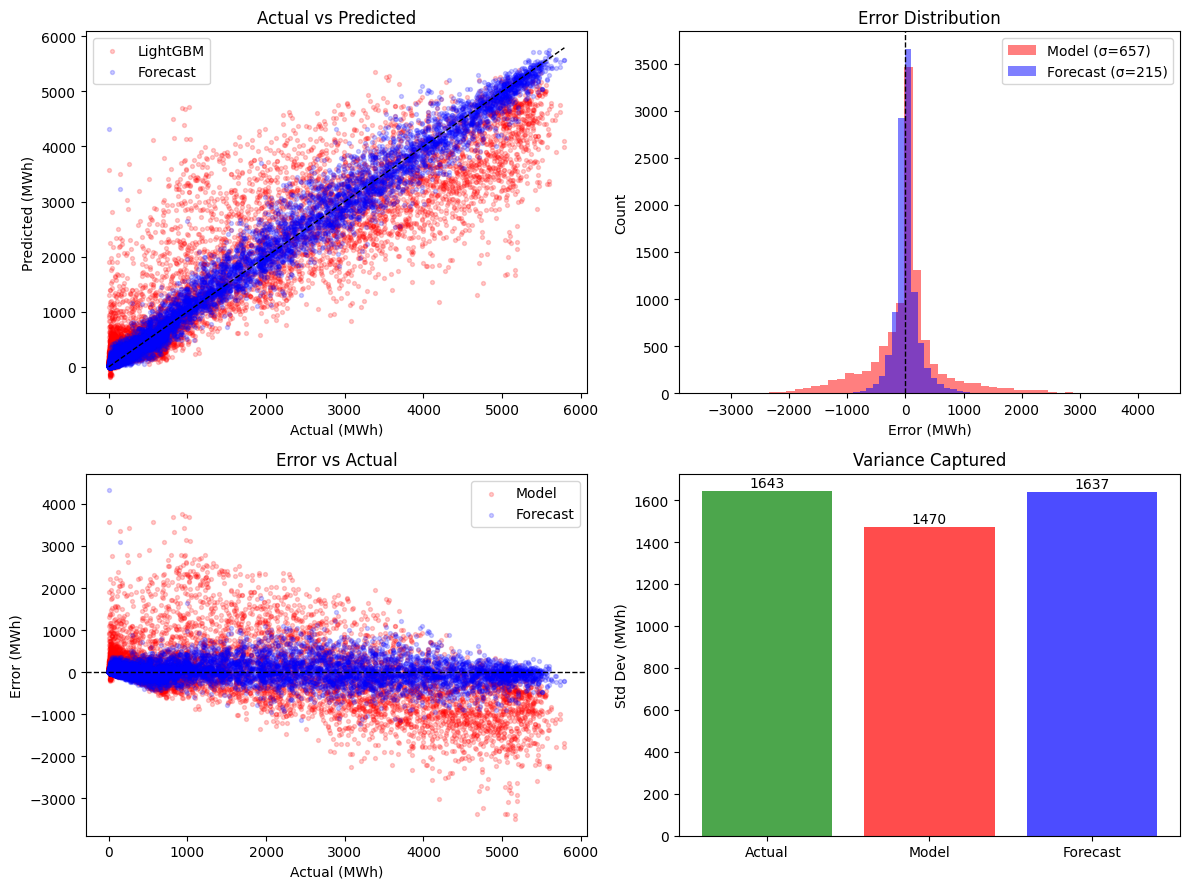

Model captures 89% of actual variance
Error std: model=657 vs forecast=215


In [97]:
# Error distribution plots
import matplotlib.pyplot as plt

y_actual_test = y_test.values if hasattr(y_test, 'values') else y_test
y_pred_test = y_pred_mean.values if hasattr(y_pred_mean, 'values') else y_pred_mean
y_forecast_test = forecast_test.values if hasattr(forecast_test, 'values') else forecast_test

error_model = y_pred_test - y_actual_test
error_forecast = y_forecast_test - y_actual_test

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Actual vs predicted
ax = axes[0, 0]
ax.scatter(y_actual_test, y_pred_test, alpha=0.2, s=8, c='red', label='LightGBM')
ax.scatter(y_actual_test, y_forecast_test, alpha=0.2, s=8, c='blue', label='Forecast')
ax.plot([0, y_actual_test.max()], [0, y_actual_test.max()], 'k--', lw=1)
ax.set(xlabel='Actual (MWh)', ylabel='Predicted (MWh)', title='Actual vs Predicted')
ax.legend()

# Error histograms
ax = axes[0, 1]
ax.hist(error_model, bins=50, alpha=0.5, color='red', label=f'Model (σ={np.std(error_model):.0f})')
ax.hist(error_forecast, bins=50, alpha=0.5, color='blue', label=f'Forecast (σ={np.std(error_forecast):.0f})')
ax.axvline(0, color='k', ls='--', lw=1)
ax.set(xlabel='Error (MWh)', ylabel='Count', title='Error Distribution')
ax.legend()

# Error vs actual value
ax = axes[1, 0]
ax.scatter(y_actual_test, error_model, alpha=0.2, s=8, c='red', label='Model')
ax.scatter(y_actual_test, error_forecast, alpha=0.2, s=8, c='blue', label='Forecast')
ax.axhline(0, color='k', ls='--', lw=1)
ax.set(xlabel='Actual (MWh)', ylabel='Error (MWh)', title='Error vs Actual')
ax.legend()

# Variance comparison
ax = axes[1, 1]
stds = [np.std(y_actual_test), np.std(y_pred_test), np.std(y_forecast_test)]
ax.bar(['Actual', 'Model', 'Forecast'], stds, color=['green', 'red', 'blue'], alpha=0.7)
for i, v in enumerate(stds):
    ax.text(i, v + 20, f'{v:.0f}', ha='center')
ax.set(ylabel='Std Dev (MWh)', title='Variance Captured')

plt.tight_layout()
plt.savefig(current_dir + '/output/results/LightGBM/plots/error_analysis_distribution.png', dpi=150)
plt.show()

# Quick summary
print(f"Model captures {np.std(y_pred_test)/np.std(y_actual_test):.0%} of actual variance")
print(f"Error std: model={np.std(error_model):.0f} vs forecast={np.std(error_forecast):.0f}")

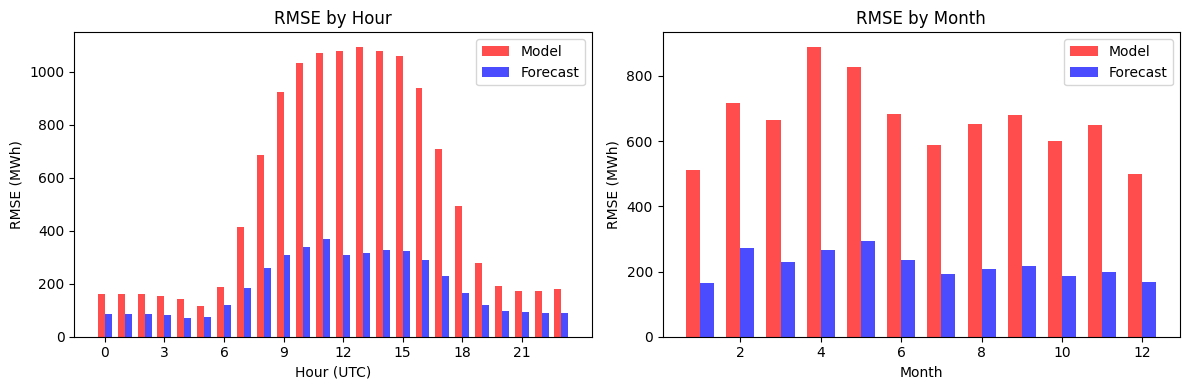

Peak hours (10-16 UTC): Model RMSE=1053, Forecast RMSE=326
Model is 3.2x worse during peak generation hours


In [98]:
# Temporal error patterns - when does the model struggle?
test_timestamps = X_test.index if hasattr(X_test, 'index') else pd.DatetimeIndex(data.loc[split_idx:, 'utc_time'])

err_df = pd.DataFrame({
    'ts': test_timestamps,
    'sq_err_model': error_model**2,
    'sq_err_forecast': error_forecast**2
})
err_df['hour'] = err_df['ts'].dt.hour
err_df['month'] = err_df['ts'].dt.month

# RMSE by hour and month
hourly = err_df.groupby('hour').apply(lambda x: pd.Series({
    'model': np.sqrt(x['sq_err_model'].mean()),
    'forecast': np.sqrt(x['sq_err_forecast'].mean())
}))
monthly = err_df.groupby('month').apply(lambda x: pd.Series({
    'model': np.sqrt(x['sq_err_model'].mean()),
    'forecast': np.sqrt(x['sq_err_forecast'].mean())
}))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Hourly
w = 0.35
ax1.bar(hourly.index - w/2, hourly['model'], w, label='Model', color='red', alpha=0.7)
ax1.bar(hourly.index + w/2, hourly['forecast'], w, label='Forecast', color='blue', alpha=0.7)
ax1.set(xlabel='Hour (UTC)', ylabel='RMSE (MWh)', title='RMSE by Hour')
ax1.legend()
ax1.set_xticks(range(0, 24, 3))

# Monthly
ax2.bar(monthly.index - w/2, monthly['model'], w, label='Model', color='red', alpha=0.7)
ax2.bar(monthly.index + w/2, monthly['forecast'], w, label='Forecast', color='blue', alpha=0.7)
ax2.set(xlabel='Month', ylabel='RMSE (MWh)', title='RMSE by Month')
ax2.legend()

plt.tight_layout()
plt.savefig(current_dir + '/output/results/LightGBM/plots/error_analysis_temporal.png', dpi=150)
plt.show()

# Peak hours analysis (10-16 UTC when solar is highest)
peak = (err_df['hour'] >= 10) & (err_df['hour'] <= 16)
peak_model = np.sqrt(err_df.loc[peak, 'sq_err_model'].mean())
peak_forecast = np.sqrt(err_df.loc[peak, 'sq_err_forecast'].mean())
print(f"Peak hours (10-16 UTC): Model RMSE={peak_model:.0f}, Forecast RMSE={peak_forecast:.0f}")
print(f"Model is {peak_model/peak_forecast:.1f}x worse during peak generation hours")

RMSE comparison:
  Train:    492 MWh
  Test:     657 MWh
  Forecast: 216 MWh

Test/Train ratio: 1.34x (mild overfitting)

Skill score vs forecast: -2.04
Model is 204% worse than day-ahead forecast


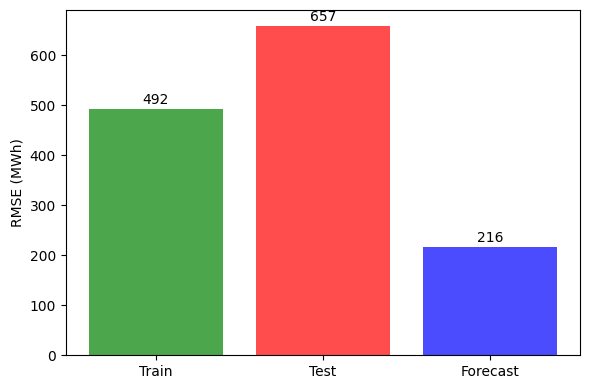

In [99]:
# Train vs test performance - check for overfitting
train_model = mean_model_final if 'mean_model_final' in dir() else (mean_model if 'mean_model' in dir() else None)
y_train_vals = y_train.values if hasattr(y_train, 'values') else y_train

if train_model is not None:
    y_train_pred = train_model.predict(X_train)
    train_rmse = np.sqrt(np.mean((y_train_pred - y_train_vals)**2))
else:
    train_rmse = np.nan

test_rmse = np.sqrt(np.mean((y_pred_test - y_actual_test)**2))
forecast_rmse = np.sqrt(np.mean((y_forecast_test - y_actual_test)**2))

print("RMSE comparison:")
if not np.isnan(train_rmse):
    print(f"  Train:    {train_rmse:.0f} MWh")
print(f"  Test:     {test_rmse:.0f} MWh")
print(f"  Forecast: {forecast_rmse:.0f} MWh")

if not np.isnan(train_rmse):
    ratio = test_rmse / train_rmse
    print(f"\nTest/Train ratio: {ratio:.2f}x", end="")
    print(" (mild overfitting)" if ratio > 1.2 else " (ok)")

skill = 1 - test_rmse/forecast_rmse
print(f"\nSkill score vs forecast: {skill:.2f}")
print(f"Model is {abs(skill)*100:.0f}% {'worse' if skill < 0 else 'better'} than day-ahead forecast")

# Simple bar chart
fig, ax = plt.subplots(figsize=(6, 4))
vals = [train_rmse, test_rmse, forecast_rmse] if not np.isnan(train_rmse) else [test_rmse, forecast_rmse]
labels = ['Train', 'Test', 'Forecast'] if not np.isnan(train_rmse) else ['Test', 'Forecast']
colors = ['green', 'red', 'blue'] if not np.isnan(train_rmse) else ['red', 'blue']
ax.bar(labels, vals, color=colors, alpha=0.7)
for i, v in enumerate(vals):
    ax.text(i, v + 10, f'{v:.0f}', ha='center')
ax.set_ylabel('RMSE (MWh)')
plt.tight_layout()
plt.savefig(current_dir + '/output/results/LightGBM/plots/error_analysis_overfitting.png', dpi=150)
plt.show()

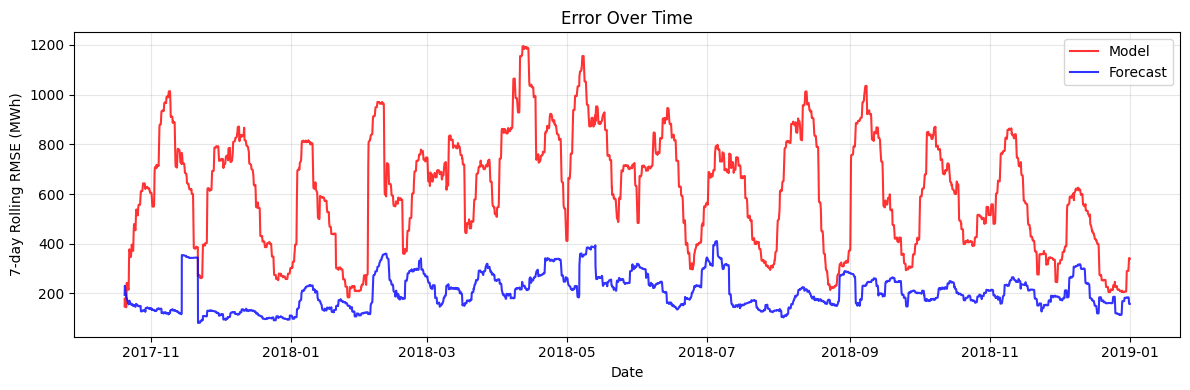

RMSE drift: -10.0% (stable)


In [101]:
# Rolling RMSE over time - check for concept drift
window = 24 * 7  # 7 days
err_df['roll_model'] = np.sqrt(err_df['sq_err_model'].rolling(window, min_periods=24).mean())
err_df['roll_forecast'] = np.sqrt(err_df['sq_err_forecast'].rolling(window, min_periods=24).mean())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(err_df['ts'], err_df['roll_model'], 'r-', alpha=0.8, label='Model')
ax.plot(err_df['ts'], err_df['roll_forecast'], 'b-', alpha=0.8, label='Forecast')
ax.set(xlabel='Date', ylabel='7-day Rolling RMSE (MWh)', title='Error Over Time')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(current_dir + '/output/results/LightGBM/plots/error_analysis_rolling.png', dpi=150)
plt.show()

# Check for drift
n = len(err_df)
first_q = err_df.iloc[:n//4]['roll_model'].mean()
last_q = err_df.iloc[-n//4:]['roll_model'].mean()
drift = (last_q - first_q) / first_q
print(f"RMSE drift: {drift:+.1%} ({'stable' if abs(drift) < 0.1 else 'drifting'})")

In [56]:
from tqdm.auto import tqdm
# --- CONFIG: choose training mode for each daily refit ---
USE_VAL_TAIL = True     # True = Mode A (adaptive early stopping); False = Mode B (fixed rounds on all data)
VAL_TAIL_DAYS = 30
EARLY_STOP_ROUNDS = 200
LOG_PERIOD = 200
STEP_HOURS = 24

# best_params: tuned params for MEAN model (objective='regression', metric='rmse', etc.)
# best_iter_mean_cv: the best_iteration you kept from CV (only needed for Mode B)

def _callbacks(early_stopping_rounds=EARLY_STOP_ROUNDS, log_period=LOG_PERIOD):
    cbs = [lgb.early_stopping(early_stopping_rounds)]
    if log_period and log_period > 0:
        cbs.append(lgb.log_evaluation(log_period))
    return cbs

# --- Build "all" matrices from your existing `data` frame ---
# Assumes you already have: target_col, forecast_col, feature_cols, cat_cols

df_all = data[['utc_time', target_col, forecast_col] + feature_cols].copy()
df_all = (df_all
          .set_index('utc_time')
          .sort_index()
          .asfreq('h'))  # ensure hourly, fills missing hours with NaN rows

# Ensure categorical dtypes for the full frame
for c in (cat_cols or []):
    if c in df_all.columns:
        df_all[c] = df_all[c].astype('category')

# Split out full spans
X_all = df_all[feature_cols].copy()
y_all = df_all[target_col].copy()
forecast_all = df_all[forecast_col].copy()
idx_all = X_all.index  # the master index we’ll use for containers

# If you still need train/test boundaries for rolling 24h:
N_total = len(df_all)
split_idx_all = int(N_total * 0.70)
test_start_time = idx_all[split_idx_all]
test_end_time   = idx_all[-1]

# (Optional) For plotting containers restricted to the test span only:
test_mask = (idx_all >= test_start_time) & (idx_all <= test_end_time)

# Containers for full-span predictions
y_pred_mean_full = pd.Series(np.nan, index=idx_all)
y_pred_p16_full  = pd.Series(np.nan, index=idx_all)
y_pred_p50_full  = pd.Series(np.nan, index=idx_all)
y_pred_p84_full  = pd.Series(np.nan, index=idx_all)

# current_start = test_start_time
step = pd.Timedelta(days=1)  # 24h step
window_starts = pd.date_range(start=test_start_time, end=test_end_time, freq=step)

# while current_start <= test_end_time:
for current_start in tqdm(window_starts, desc="Rolling 24h predictions"):
    pred_start = current_start
    pred_end = min(pred_start + step - pd.Timedelta(hours=1), test_end_time)
    # pred_start = current_start
    # pred_end   = min(pred_start + pd.Timedelta(hours=STEP_HOURS) - pd.Timedelta(hours=1), test_end_time)
    pred_index = X_all.loc[pred_start:pred_end].index
    if len(pred_index) == 0:
        break

    train_end = pred_start - pd.Timedelta(hours=1)
    tr_index = X_all.loc[:train_end].index
    if len(tr_index) == 0:
        break

    if USE_VAL_TAIL:
        # ------------------ Mode A: adaptive early stopping with val tail ------------------
        val_tail_hours = 24 * VAL_TAIL_DAYS
        tail_start = train_end - pd.Timedelta(hours=val_tail_hours) + pd.Timedelta(hours=1)
        tail_start = max(tail_start, tr_index.min())

        X_tr_core = X_all.loc[:tail_start - pd.Timedelta(hours=1)].copy()
        y_tr_core = y_all.loc[X_tr_core.index].copy()
        X_val_tail = X_all.loc[tail_start:train_end].copy()
        y_val_tail = y_all.loc[X_val_tail.index].copy()

        # fallback if core empty
        if len(X_tr_core) == 0:
            if len(X_val_tail) >= 48:
                X_tr_core = X_all.loc[:train_end].iloc[:-48].copy()
                y_tr_core = y_all.loc[X_tr_core.index].copy()
                X_val_tail = X_all.loc[:train_end].iloc[-48:].copy()
                y_val_tail = y_all.loc[X_val_tail.index].copy()
            else:
                split_pos = max(1, int(len(tr_index) * 0.8))
                X_tr_core = X_all.loc[tr_index[:split_pos]].copy()
                y_tr_core = y_all.loc[X_tr_core.index].copy()
                X_val_tail = X_all.loc[tr_index[split_pos:]].copy()
                y_val_tail = y_all.loc[X_val_tail.index].copy()

        # # reassert categoricals
        # for c in (cat_cols or []):
        #     if c in X_tr_core.columns:
        #         X_tr_core[c] = X_tr_core[c].astype('category')
        #         X_val_tail[c] = X_val_tail[c].astype('category')

        dtr = lgb.Dataset(X_tr_core, label=y_tr_core, categorical_feature=cat_cols or None, free_raw_data=True)
        dva = lgb.Dataset(X_val_tail, label=y_val_tail, categorical_feature=cat_cols or None, free_raw_data=True, reference=dtr)

        # Mean model
        booster = lgb.train(
            params=best_params,
            train_set=dtr,
            num_boost_round=5000,
            valid_sets=[dtr, dva],
            valid_names=['train','valid'],
            callbacks=_callbacks()
        )
        best_it_mean = booster.best_iteration

        # Quantile helper
        def _train_quantile(alpha):
            qp = best_params.copy()
            qp.update({'objective': 'quantile', 'alpha': alpha, 'metric': 'quantile', 'verbosity': -1})
            return lgb.train(
                params=qp,
                train_set=dtr,
                num_boost_round=int(best_it_mean),
                valid_sets=[dtr, dva],
                valid_names=['train','val'],
                callbacks=[lgb.early_stopping(max(50, best_it_mean // 10)),
                           lgb.log_evaluation(max(50, best_it_mean // 10))]
            )

        q16 = _train_quantile(0.16)
        q50 = _train_quantile(0.50)
        q84 = _train_quantile(0.84)

        # Predict next 24h
        X_pred = X_all.loc[pred_index].copy()
        # for c in (cat_cols or []):
        #     if c in X_pred.columns:
        #         X_pred[c] = X_pred[c].astype('category')

        y_hat_mean = booster.predict(X_pred, num_iteration=best_it_mean)
        y_hat_p16  = q16.predict(X_pred, num_iteration=q16.best_iteration)
        y_hat_p50  = q50.predict(X_pred, num_iteration=q50.best_iteration)
        y_hat_p84  = q84.predict(X_pred, num_iteration=q84.best_iteration)

    else:
        # ------------------ Mode B: full training (no val), fixed num_boost_round from CV ------------------
        # use all data up to train_end
        X_tr_core = X_all.loc[:train_end].copy()
        y_tr_core = y_all.loc[X_tr_core.index].copy()
        # for c in (cat_cols or []):
        #     if c in X_tr_core.columns:
        #         X_tr_core[c] = X_tr_core[c].astype('category')

        dtr = lgb.Dataset(X_tr_core, label=y_tr_core, categorical_feature=cat_cols or None, free_raw_data=True)

        # Mean
        booster = lgb.train(
            params=best_params,
            train_set=dtr,
            num_boost_round=int(best_iter_mean_cv),  # fixed from CV
            valid_sets=[dtr], valid_names=['train'], callbacks=[lgb.log_evaluation(LOG_PERIOD)]
        )

        # Quantile helper
        def _train_quantile(alpha):
            qp = best_params.copy()
            qp.update({'objective': 'quantile', 'alpha': alpha, 'metric': 'quantile', 'verbosity': -1})
            return lgb.train(
                params=qp,
                train_set=dtr,
                num_boost_round=int(best_iter_mean_cv),
                valid_sets=[dtr], valid_names=['train'], callbacks=[lgb.log_evaluation(LOG_PERIOD)]
            )

        q16 = _train_quantile(0.16)
        q50 = _train_quantile(0.50)
        q84 = _train_quantile(0.84)

        X_pred = X_all.loc[pred_index].copy()
        # for c in (cat_cols or []):
        #     if c in X_pred.columns:
        #         X_pred[c] = X_pred[c].astype('category')

        y_hat_mean = booster.predict(X_pred, num_iteration=booster.num_trees())
        y_hat_p16  = q16.predict(X_pred,     num_iteration=q16.num_trees())
        y_hat_p50  = q50.predict(X_pred,     num_iteration=q50.num_trees())
        y_hat_p84  = q84.predict(X_pred,     num_iteration=q84.num_trees())

    # Enforce monotone bands and store
    lb = np.minimum.reduce([y_hat_p16, y_hat_p50, y_hat_p84])
    ub = np.maximum.reduce([y_hat_p16, y_hat_p50, y_hat_p84])
    med = np.clip(y_hat_p50, lb, ub)

    y_pred_mean_full.loc[pred_index] = y_hat_mean
    y_pred_p16_full.loc[pred_index]  = lb
    y_pred_p50_full.loc[pred_index]  = med
    y_pred_p84_full.loc[pred_index]  = ub

    # current_start = pred_end + pd.Timedelta(hours=1)

Rolling 24h predictions:   0%|          | 0/439 [00:00<?, ?it/s]

Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 629.444	valid's rmse: 779.912
[400]	train's rmse: 530.349	valid's rmse: 735.536
[600]	train's rmse: 471.363	valid's rmse: 722.519
[800]	train's rmse: 427.234	valid's rmse: 720.44
[1000]	train's rmse: 389.53	valid's rmse: 720.154
Early stopping, best iteration is:
[844]	train's rmse: 418.493	valid's rmse: 718.628
Training until validation scores don't improve for 84 rounds
[84]	train's quantile: 161.99	val's quantile: 167.111
[168]	train's quantile: 136.407	val's quantile: 157.482
[252]	train's quantile: 125.973	val's quantile: 151.766
[336]	train's quantile: 119.108	val's quantile: 149.821
[420]	train's quantile: 113.278	val's quantile: 148.722
[504]	train's quantile: 108.612	val's quantile: 147.963
[588]	train's quantile: 105.266	val's quantile: 146.755
Early stopping, best iteration is:
[541]	train's quantile: 106.92	val's quantile: 146.491
Training until validation scores don't improve for 84 rounds
[8

In [ ]:
# print(len(forecast_all))
# print(len(X_all))
# print(len(y_pred_mean_full))

# ---------- Build plotting DataFrame with bands ----------
plot_roll_quant = pd.DataFrame({
    'utc_time': X_all.index,
    'Actual Solar': y_all.values,
    'LightGBM 24h Prediction Mean': y_pred_mean_full.values,
    'LightGBM 24h Prediction Median': y_pred_p50_full.values,
    'LightGBM Lower Band': y_pred_p16_full.values,
    'LightGBM Upper Band': y_pred_p84_full.values,
    'Forecast Solar Day Ahead': forecast_all.values
})

if 'solar_flux_Wm2' in data.columns:
    plot_roll_quant['solar_flux_Wm2'] = data['solar_flux_Wm2'].values

print(plot_roll_quant)

# Draw the single clean plot over whole test span (your function supports CI via test_pred_col/lower/upper)
p = ML_future_energy_predict(
    dataframe=plot_roll_quant,
    x_axis_column='utc_time',
    y_axis_columns=['Actual Solar', 'LightGBM 24h Prediction Mean', 'LightGBM 24h Prediction Median', 'Forecast Solar Day Ahead'],
    x_axis_label=r"$$\mathrm{UTC\ (DD\!-\!MM\!-\!YY\ \ HH:MM)}$$",
    y_axis_label=r"$$\mathrm{Solar\ Power\ (MWh)}$$",
    title='Actual vs LightGBM 24h Rolling Prediction (Mean and Median) with 1 sigma confidence bounds vs Day-Ahead Forecast',
    feature_columns=(['solar_flux_Wm2'] if 'solar_flux_Wm2' in plot_roll_quant.columns else None),
    features_ylabel=[r"$$\mathrm{Solar\ Flux\ (W\ m^{-2})}$$"] if 'solar_flux_Wm2' in plot_roll_quant.columns else None,
    p=None, normalize=False, other_colors=False,
    color_plot=['dorange', 'red', 'pink', 'blue'],
    color_features=['green'],
    labels=['Actual Solar', 'LightGBM 24h Prediction (Mean)', 'LightGBM 24h Prediction Median', 'Forecast Solar Day Ahead'],
    features_labels=(['Solar Flux'] if 'solar_flux_Wm2' in plot_roll_quant.columns else None),
    symbols=['star', 'triangle', 'inverted_triangle', 'diamond'],
    symbols_features=(['circle'] if 'solar_flux_Wm2' in plot_roll_quant.columns else None),
    test_pred_col='LightGBM 24h Prediction Mean',
    lower_conf_col='LightGBM Lower Band',
    upper_conf_col='LightGBM Upper Band'
)
show(p)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Solar_Power_LightGBM_24hr_step_ahead_CV_windows_best_params.html'

title = 'Actual vs LightGBM 24h Rolling Prediction (Mean and Median) with 1 sigma confidence bounds vs Day-Ahead Forecast'

save(p, filename_out, title=title)

In [ ]:
# ========= Overall metrics on the full TEST span (LightGBM 24h mean/median vs Forecast) =========
# Assumes you already have: plot_roll_quant, test_start_time, test_end_time,
# and your helpers: safe_metrics, rmse_skill.

# 1) Slice the test range
mask_test = (plot_roll_quant['utc_time'] >= test_start_time) & (plot_roll_quant['utc_time'] <= test_end_time)

yt = plot_roll_quant.loc[mask_test, 'Actual Solar'].values
yp_mean = plot_roll_quant.loc[mask_test, 'LightGBM 24h Prediction Mean'].values
yp_median = plot_roll_quant.loc[mask_test, 'LightGBM 24h Prediction Median'].values
yf = plot_roll_quant.loc[mask_test, 'Forecast Solar Day Ahead'].values

# 2) Build metrics dict (LightGBM Mean + Median + Forecast) incl. RMSE Skill vs Forecast
metrics_overall = {
    "All Test Data": {
        "LightGBM 24h Mean": safe_metrics(yt, yp_mean) | {
            "RMSE Skill (vs Forecast)": rmse_skill(yt, yp_mean, yf)
        },
        "LightGBM 24h Median": safe_metrics(yt, yp_median) | {
            "RMSE Skill (vs Forecast)": rmse_skill(yt, yp_median, yf)
        },
        "Forecast": safe_metrics(yt, yf) | {
            "RMSE Skill (vs Forecast)": rmse_skill(yt, yf, yf)
        },
    }
}

# 3) Pretty DataFrame (MultiIndex columns)
df_overall = pd.DataFrame({
    (section, model): metrics_overall[section][model]
    for section in metrics_overall
    for model in metrics_overall[section]
})

# Optional: column order
df_overall = df_overall[[('All Test Data','LightGBM 24h Mean'),
                         ('All Test Data','LightGBM 24h Median'),
                         ('All Test Data','Forecast')]]

print("\n=== Overall Test Metrics (LightGBM 24h Mean/Median vs Forecast) ===")
print(df_overall.round(3))

# 4) Save CSV / TXT / Markdown
direct_out = current_dir + '/output/results/LightGBM'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/lightgbm_rolling24h_vs_forecast_metrics_overall_with_median.csv'

df_overall.to_csv(filename_out)

filename_out = direct_out + '/lightgbm_rolling24h_vs_forecast_metrics_overall_with_median.txt'
with open(filename_out, 'w', encoding='utf-8') as f:
    f.write("LightGBM 24h Rolling Prediction (Mean & Median) vs Day-Ahead Forecast — Overall Test Metrics\n")
    f.write("=" * 94 + "\n\n")
    f.write(df_overall.round(3).to_string())
    f.write("\n")

filename_out = direct_out + '/lightgbm_rolling24h_vs_forecast_metrics_overall_with_median.md'
with open(filename_out, 'w', encoding='utf-8') as f:
    f.write("# LightGBM 24h Rolling Prediction (Mean & Median) vs Day-Ahead Forecast — Overall Test Metrics\n\n")
    md_df = df_overall.copy()
    md_df.columns = [f"{lvl0} – {lvl1}" for (lvl0, lvl1) in md_df.columns]
    f.write(md_df.round(3).to_markdown(index=True))
    f.write("\n")

#print(f"\nSaved overall metrics (mean & median) to:\n- {csv_path}\n- {txt_path}\n- {md_path}")

In [ ]:
# Now I'll predict wind power following the steps above.

# --- Ensure your dataframe is sorted ---
df_wind = merged_power_weather_feat_final.copy()
df_wind = df.sort_values('utc_time')

target_col = 'generation wind onshore'
forecast_col = 'forecast wind onshore day ahead'
datetime_col = 'utc_time'
city_col = 'city_name'

# Exclude categorical weather, non-numeric, and other power columns. The columns that are kept have been specified so this really
# isn't necessary, but might be useful in the future.
exclude_cols = ['local_time', 'utc_time', 'utc_timestamp', 'date', 'weather_main', 'weather_description',
                'weather_icon', 'generation solar', 'generation solar_rolling3h', 'generation wind onshore',
                'generation wind onshore_rolling3h', 'generation biomass', 'generation biomass_rolling3h',
                'generation fossil brown coal/lignite', 'generation fossil brown coal/lignite_rolling3h',
                'generation fossil gas', 'generation fossil gas_rolling3h',
                'generation fossil hard coal', 'generation fossil hard coal_rolling3h',
                'generation fossil oil', 'generation fossil oil_rolling3h',
                'generation hydro pumped storage consumption',
                'generation hydro pumped storage consumption_rolling3h',
                'generation hydro run-of-river and poundage',
                'generation hydro run-of-river and poundage_rolling3h',
                'generation hydro water reservoir',
                'generation hydro water reservoir_rolling3h', 'generation nuclear',
                'generation nuclear_rolling3h', 'generation other',
                'generation other_rolling3h', 'generation other renewable',
                'generation other renewable_rolling3h', 'generation waste',
                'generation waste_rolling3h', 'total load actual', 'total load actual_rolling3h',
                'total load actual_rolling6h', 'price actual', 'price actual_rolling3h', 'price actual_rolling6h',
                'forecast solar day ahead', 'forecast wind onshore day ahead',
                'total load forecast', 'price day ahead', 'city_name']

# Specify columns to weight based on population.
features_to_weight = ['daylight_length_hr', 'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'temp',
                      'temp_rolling3h', 'temp_min', 'temp_min_rolling3h', 'temp_max', 'temp_max_rolling3h',
                      'pressure', 'pressure_rolling3h', 'humidity', 'humidity_rolling3h', 'wind_speed',
                      'wind_speed_rolling3h', 'wind_deg', 'wind_deg_rolling3h', 'rain_1h', 'rain_1h_rolling3h',
                      'rain_3h', 'rain_3h_rolling3h', 'snow_3h', 'snow_3h_rolling3h', 'clouds_all', 'clouds_all_rolling3h',
                      'solar_flux_Wm2', 'solar_flux_Wm2_rolling3h', 'severity']

# Don't apply the city weights to these columns as they will be the same for all cities.
time_features_no_weight = ['month', 'day_of_year', 'date_fraction_of_year', 'day_of_week',
                           'is_weekend', 'season', 'is_holiday', 'utc_time_day_fraction',
                           'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos',
                           'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos']

print("Features used for LightGBM:", features_to_weight + time_features_no_weight)

# Apply the city weights (based on population) to aggregate the weather/relevant time features across the cities.
agg_df_wind = (
    df_wind.groupby('utc_time', group_keys=False)
      .agg({col: lambda x: np.sum(x * df_wind.loc[x.index, 'city_weights']) for col in features_to_weight})
)

time_feats = df_wind.groupby('utc_time', group_keys=False)[time_features_no_weight].first()
agg_df_wind = agg_df_wind.join(time_feats)

# Add the national targets & forecast values
agg_df_wind[target_col] = df_wind.groupby('utc_time')[target_col].first()
agg_df_wind[forecast_col] = df_wind.groupby('utc_time')[forecast_col].first()
agg_df_wind = agg_df_wind.reset_index()
agg_df_wind = agg_df_wind.sort_values('utc_time').reset_index(drop=True)

In [ ]:
# df is the pre-aggregated per-city dataframe (before agg_df), with columns: utc_time, city_name, city_weights, weather_main
tmp = df_wind[['utc_time', 'city_weights', 'weather_main']].copy()
onehot = pd.get_dummies(tmp['weather_main'], prefix='wx')
weighted = onehot.mul(tmp['city_weights'].values, axis=0)

wx_dist = pd.concat([tmp[['utc_time']], weighted], axis=1) \
             .groupby('utc_time', as_index=True).sum()

# Normalize to sum to 1 in case of missing cities:
wx_dist = wx_dist.div(wx_dist.sum(axis=1), axis=0).fillna(0.0)

# Merge into your aggregated feature table
agg_df_wind = agg_df_wind.join(wx_dist, on='utc_time')

In [ ]:
direct_out = current_dir + '/output'
filename_out = direct_out + '/agreggated_dataset_column_stats_wind.csv'
agg_df_wind.describe().to_csv(filename_out, index=True)

In [ ]:
# Ensure no NA rows in predictors or target

feature_cols = features_to_weight + time_features_no_weight + list(wx_dist.columns)
data_wind = agg_df_wind[[target_col, forecast_col, 'utc_time'] + feature_cols].dropna().copy()

N = len(data_wind)

# For LightGBM, we need to tell the model which columns are categorical. ChatGPT suggested to keep binary features as numeric
# instead of converting to categorical.
cat_cols = [c for c in ['month', 'day_of_week'] if c in data_wind.columns]

for c in cat_cols:
    data_wind.loc[:, c] = data_wind[c].astype('category')

#split the data into a 70/30 training and testing set.
split_idx = int(N * 0.7)

train = data_wind.iloc[:split_idx].copy()
test = data_wind.iloc[split_idx:].copy()

train = train.set_index('utc_time', drop=False).asfreq('h')
test = test.set_index('utc_time', drop=False).asfreq('h')

# Split into X/y
y_train = train[target_col]
X_train = train[feature_cols]
y_test = test[target_col]
X_test = test[feature_cols]
forecast_test = test[forecast_col]
datetime_test = test['utc_time'].to_numpy(copy=True)  # Save for plotting

In [ ]:
# --- 2) Make a time-ordered validation split from the training period (no shuffling)
val_frac = 0.2
val_cut = int(len(X_train) * (1 - val_frac))
X_tr, y_tr = X_train.iloc[:val_cut], y_train.iloc[:val_cut]
X_val, y_val = X_train.iloc[val_cut:], y_train.iloc[val_cut:]

fit_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols or None, free_raw_data=False)
val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols or None, free_raw_data=False)

# --- 3) Train LightGBM with early stopping. This is the mean model.
mean_params = dict(
    objective='regression',
    boosting_type='gbdt',
    metric='rmse',
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    min_data_in_leaf=50,
    bagging_freq=1,
    reg_alpha=0.0,
    reg_lambda=0.0,
    seed=42,
    verbosity=-1,
    n_jobs=-1
)

mean_model = lgb.train(
    params=mean_params,
    train_set=fit_set,
    num_boost_round=5000,                # generous upper bound
    valid_sets=[fit_set, val_set],
    valid_names=["train","val"],
    callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(200)]
)

best_iter_mean = mean_model.best_iteration
print(f"Mean model best_iteration = {best_iter_mean}")

In [ ]:
# --- 4) Train quantile models for lower/upper bounds

# 16th percentile (lower ~ 1-sigma)
lgbm_lower_model = train_quantile(alpha=0.16, best_rounds=best_iter_mean)

# Median prediction
lgbm_median_model = train_quantile(alpha=0.50, best_rounds=best_iter_mean)  # "median" model

# 84th percentile (upper ~ 1-sigma)
lgbm_upper_model = train_quantile(alpha=0.84, best_rounds=best_iter_mean)

# --- 5) Predict on the test set
y_pred_mean = mean_model.predict(X_test, num_iteration=mean_model.best_iteration)
y_pred_lower  = lgbm_lower_model.predict(X_test,  num_iteration=lgbm_lower_model.best_iteration)
y_pred_median  = lgbm_median_model.predict(X_test,  num_iteration=lgbm_median_model.best_iteration)
y_pred_upper  = lgbm_upper_model.predict(X_test,  num_iteration=lgbm_upper_model.best_iteration)

# Enforce monotonicity of bands post-hoc to avoid tiny inversions
lower_conf_int = np.minimum.reduce([y_pred_lower, y_pred_median, y_pred_upper])
upper_conf_int = np.maximum.reduce([y_pred_lower, y_pred_median, y_pred_upper])
y_median = np.clip(y_pred_median, lower_conf_int, upper_conf_int)

In [ ]:
# ----- Expect these to already exist -----
# y_test: Series of actual solar generation on test set
# y_pred_test: ndarray/Series of LightGBM predictions for test set (aligned with y_test)
# forecast_test: Series of Day-Ahead solar forecast (aligned with y_test)
# current_dir: your working dir (used for saving)

# --- Full Test Set Metrics ---
metrics = {}

y_true_full = y_test.values
y_lgbm_full = np.asarray(y_pred_mean)
y_forecast_full = forecast_test.values

metrics['All Test Data'] = {
    'LightGBM': safe_metrics(y_true_full, y_lgbm_full),
    'Forecast': safe_metrics(y_true_full, y_forecast_full)
}

# --- First Day Only (first 24 hours of test set) ---
cut = 24
y_true_day1 = y_test.values[:cut]
y_lgbm_day1 = y_lgbm_full[:cut]
y_forecast_day1 = y_forecast_full[:cut]

metrics['First 24 Hours'] = {
    'LightGBM': safe_metrics(y_true_day1, y_lgbm_day1),
    'Forecast': safe_metrics(y_true_day1, y_forecast_day1)
}

metrics['All Test Data']['Skill_vs_Forecast'] = {
    "RMSE Skill": rmse_skill(y_true_full, y_lgbm_full, y_forecast_full)
}
metrics['First 24 Hours']['Skill_vs_Forecast'] = {
    "RMSE Skill": rmse_skill(y_true_day1, y_lgbm_day1, y_forecast_day1)
}

# ----- Pretty table (MultiIndex columns) -----
df_metrics = pd.DataFrame({
    (section, model): metrics[section][model]
    for section in metrics.keys()
    for model in metrics[section].keys()
})

# Order columns nicely
cols_order = []
for section in ['All Test Data', 'First 24 Hours']:
    for model in ['LightGBM', 'Forecast', 'Skill_vs_Forecast']:
        if model in metrics[section]:
            cols_order.append((section, model))
df_metrics = df_metrics[cols_order]

df_disp = df_metrics.round(3)
print(df_disp)

# ----- Save to CSV / TXT / MD -----
direct_out = current_dir + '/output/results/LightGBM'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out_csv = direct_out + '/lightgbm_vs_forecast_metrics_wind_1st_try.csv'

df_metrics.to_csv(filename_out_csv)

filename_out_txt = direct_out + '/lightgbm_vs_forecast_metrics_wind_1st_try.txt'
with open(filename_out_txt, 'w', encoding='utf-8') as f:
    f.write("LightGBM vs Day-Ahead Forecast — Metrics (Wind Generation)\n")
    f.write("=" * 70 + "\n\n")
    f.write(df_disp.to_string())
    f.write("\n")

filename_out_md = direct_out + '/lightgbm_vs_forecast_metrics_wind_1st_try.md'
with open(filename_out_md, 'w', encoding='utf-8') as f:
    f.write("# LightGBM vs Day-Ahead Forecast — Metrics (Wind Generation)\n\n")
    md_df = df_disp.copy()
    md_df.columns = [f"{lvl0} – {lvl1}" for (lvl0, lvl1) in md_df.columns]
    f.write(md_df.to_markdown(index=True))
    f.write("\n")

print(f"\nSaved metrics:\n- CSV: {filename_out_csv}\n- TXT: {filename_out_txt}\n- MD:  {filename_out_md}")

In [ ]:
# --- 6) Feature importance
# Importance by gain and by split (counts)
feat_names = mean_model.feature_name()
imp_gain   = mean_model.feature_importance(importance_type='gain')
imp_split  = mean_model.feature_importance(importance_type='split')

fi_df = (pd.DataFrame({
            'feature': feat_names,
            'gain': imp_gain,
            'split': imp_split
        })
        .assign(gain_pct=lambda d: 100 * d['gain'] / d['gain'].sum() if d['gain'].sum() > 0 else 0)
        .sort_values('gain', ascending=False)
        .reset_index(drop=True))

print("\nTop 20 features by gain:\n", fi_df.head(20))

filename_out = direct_out + '/lgbm_feature_importance_gain_split_wind.csv'
fi_df.to_csv(filename_out, index=False)

In [ ]:
# --- 7) Build plot_df for your Bokeh function
N = len(train) + len(test)
full_pred = np.full(N, np.nan)
full_pred[len(train):] = y_pred_mean

full_pred_med = np.full(N, np.nan)
full_pred_med[len(train):] = y_median

test_rec = test.copy()
test_rec['LightGBM Prediction Mean'] = y_pred_mean
test_rec['LightGBM Prediction Median'] = y_median
test_rec['Forecast wind onshore day ahead'] = data_wind.loc[split_idx:, forecast_col].to_numpy(copy=True)

train_pred = np.full(N, np.nan)
train_pred[:split_idx] = mean_model.predict(X_train, num_iteration=mean_model.best_iteration)

plot_df_lgbm = pd.DataFrame({
    'utc_time': data_wind['utc_time'].to_numpy(copy=True),
    'Actual Wind': data_wind[target_col].to_numpy(copy=True),
    'LightGBM Prediction Mean': full_pred,
    'LightGBM Prediction Median': full_pred_med,
    'LightGBM Train Prediction': train_pred,
    'Forecast wind onshore day ahead': data_wind[forecast_col].to_numpy(copy=True)
})

plot_df_lgbm['LGBM Lower Bound'] = np.nan
plot_df_lgbm['LGBM Upper Bound'] = np.nan
plot_df_lgbm.loc[split_idx:, 'LGBM Lower Bound'] = lower_conf_int
plot_df_lgbm.loc[split_idx:, 'LGBM Upper Bound'] = upper_conf_int

# Add significant cols
for col in feature_cols:
    plot_df_lgbm[col] = data_wind[col].to_numpy(copy=True)

p = ML_future_energy_predict(plot_df_lgbm, 'utc_time', ['Actual Wind', 'LightGBM Prediction Mean', 'LightGBM Prediction Median',
                                                        'LightGBM Train Prediction', 'Forecast wind onshore day ahead'],
                             r"$$\mathrm{UTC\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Wind\ Power\ Generation\ (MWh)}$$",
                             'Actual Wind Power, LightGBM Wind Power Prediction'
                             + ' Forecast Wind Day Ahead vs UTC Time and Wind Speed',
                             feature_columns=['wind_speed'],
                             features_ylabel=[r"$$\mathrm{Wind\ Speed\ (m\,s^{-1})}$$"],
                             p=None, normalize=False, other_colors=False, color_plot=['dorange', 'red', 'pink', 'black', 'blue'],
                             color_features=['green'],
                             labels=['Actual Wind', 'LightGBM Predicted Mean Wind Power', 'LightGBM Predicted Median Wind Power',
                                     'LightGBM Train Prediction', 'Forecast Wind Day Ahead'],
                             features_labels=['Wind Speed'], symbols=['star', 'triangle', 'inverted_triangle', 'square', 'diamond'],
                             symbols_features=['circle'], test_pred_col='LightGBM Train Prediction',
                             lower_conf_col='LGBM Lower Bound', upper_conf_col='LGBM Upper Bound')

show(p)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Wind_Power_LightGBM_1st_try.html'

title = 'Actual Wind Power, LightGBM Wind Power Prediction, Forecast Wind Day Ahead vs UTC Time and Wind Speed'

save(p, filename_out, title=title)

In [ ]:
class FittedAdapter:
    def __init__(self, fitted_series):
        self.fittedvalues = fitted_series

y_pred_train = mean_model.predict(X_train, num_iteration=mean_model.best_iteration)
lgbm_train = FittedAdapter(pd.Series(y_pred_train, index=y_train.index))

p, p_hist = plot_train_test_residuals_bokeh(y_train, lgbm_train, y_test, test_rec['LightGBM Prediction Mean'], test_rec.index,
                                            title="Train/Test Residuals Analysis for Wind Power Generation")

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Residuals_actual_predicted_wind_train_test_1st_try.html'

title = 'Train/Test Residuals Analysis for Wind Power Generation'

save(p, filename_out, title=title)

filename_out = direct_out + '/Histogram_residuals_train_test_wind_1st_try.html'

title = 'Histogram of the Residuals for Wind Power Generation'

save(p_hist, filename_out, title=title)

In [ ]:
# ---------- run tuning with monthly WFV ----------
# Assumes you already have X_train, y_train (indexed by utc_time), and cat_cols
N_total = len(data_wind)
cv_end = int(N_total * 0.70)  # first 70% for CV, rest for testing
X_cv = data_wind.iloc[:cv_end][feature_cols].copy()
y_cv = data_wind.iloc[:cv_end][target_col].copy()

# Ensure hourly DateTimeIndex (you already do this elsewhere, just re-assert)
cv_idx = pd.DatetimeIndex(data_wind.iloc[:cv_end]['utc_time'].values, name='utc_time')

X_cv.index = cv_idx
y_cv.index = cv_idx

X_cv  = X_cv.asfreq('h')
y_cv  = y_cv.asfreq('h')

splits_30d = _build_30day_walkforward_splits(X_cv, initial_train_frac=0.4, val_span_days=30)
print(f"Generated {len(splits_30d)} WFV splits on first 70% of data.")

direct_out = current_dir + '/output/results/LightGBM/'

log_dir = os.path.join(direct_out, "tuning_logs_wind")

print('log_dir: ', log_dir)

best_params, study = tune_lgbm_with_optuna_logged(
    X_cv=X_cv, y_cv=y_cv,
    splits=splits_30d,
    cat_cols=cat_cols,
    n_trials=60,
    metric='rmse',
    random_seed=42,
    log_dir=log_dir
)
print("Best mean valid RMSE:", study.best_value)
print("Best params:", best_params)

In [ ]:
# Base plotting DataFrame over CV slice
plot_cv_df = pd.DataFrame({
    'utc_time': X_cv.index,
    'Actual Wind': y_cv.values
})

# Start the plot with the actual series
p_wfv = ML_future_energy_predict(
    dataframe=plot_cv_df.copy(),
    x_axis_column='utc_time',
    y_axis_columns=['Actual Wind'],
    x_axis_label=r"$$\mathrm{UTC\ (DD\!-\!MM\!-\!YY\ \ HH:MM)}$$",
    y_axis_label=r"$$\mathrm{Wind\ Power\ Generation\ (MWh)}$$",
    title='Walk-Forward Validation Windows — Actual vs Best-Param Predictions',
    p=None,
    other_colors=False,
    color_plot=['dorange'],
    labels=['Actual Wind'],
    symbols=['star']
)

# Colors to cycle through for windows
win_colors = ['red', 'blue', 'green', 'purple', 'black', 'cyan', 'pink', 'orange', 'navy', 'olive']

for w, (tr_idx, va_idx) in enumerate(splits_30d, start=1):
    X_tr_w, y_tr_w = X_cv.iloc[tr_idx], y_cv.iloc[tr_idx]
    X_va_w, y_va_w = X_cv.iloc[va_idx], y_cv.iloc[va_idx]

    dtr_w = lgb.Dataset(X_tr_w, label=y_tr_w, categorical_feature=cat_cols or None, free_raw_data=True)
    dva_w = lgb.Dataset(X_va_w, label=y_va_w, categorical_feature=cat_cols or None, free_raw_data=True, reference=dtr_w)

    # short training with early stopping; you can increase num_boost_round
    evals_result_w = {}
    booster_w = lgb.train(
        params=best_params,
        train_set=dtr_w,
        num_boost_round=5000,
        valid_sets=[dtr_w, dva_w],
        valid_names=['train','valid'],
        callbacks=_lgb_callbacks(early_stopping_rounds=200, log_period=0, evals_result=evals_result_w)
    )
    pred_va = booster_w.predict(X_va_w, num_iteration=booster_w.best_iteration)

    # Add a column with NaNs outside the window so only that window draws
    col_name = f'Pred Window {w:02d}'

    X_va_index = pd.DatetimeIndex(X_va_w.index).tz_localize(None) if hasattr(X_va_w.index, 'tz') and X_va_w.index.tz is not None else X_va_w.index
    pred_series = pd.Series(pred_va, index=X_va_index, name=col_name)
    
    plot_seg = plot_cv_df.copy()
    plot_seg['utc_time'] = pd.DatetimeIndex(plot_seg['utc_time']).tz_localize(None)

    plot_seg = plot_seg.merge(pred_series, how='left', left_on='utc_time', right_index=True)
    # plot_seg[col_name] = np.nan
    # plot_seg.loc[X_va_w.index, col_name] = pred_va

    # Layer onto the same Bokeh fig
    p_wfv = ML_future_energy_predict(
        dataframe=plot_seg,
        x_axis_column='utc_time',
        y_axis_columns=[col_name],
        x_axis_label=r"$$\mathrm{UTC\ (DD\!-\!MM\!-\!YY\ \ HH:MM)}$$",
        y_axis_label=r"$$\mathrm{Wind\ Power\ (MWh)}$$",
        title='Walk-Forward Validation Windows — Actual vs Best-Param Predictions',
        p=p_wfv,
        other_colors=True,
        color_plot=[win_colors[(w-1) % len(win_colors)]],
        labels=[col_name],
        symbols=['circle']
    )

show(p_wfv)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Wind_Power_LightGBM_step_ahead_CV_windows_best_params.html'

title = 'Actual Wind Power and LightGBM Wind Power Prediction Windows vs UTC Time'

save(p_wfv, filename_out, title=title)

# 1) Make sure the train/test indices are sorted & hourly (you already call .asfreq('h'))
X_tr_all = X_train.sort_index()
y_tr_all = y_train.loc[X_tr_all.index]

# 2) Build 30-day validation tail (720 hours); fallback if train shorter than 30 days
val_end = X_tr_all.index.max()
val_start = val_end - pd.Timedelta(days=30) + pd.Timedelta(hours=1)

if val_start < X_tr_all.index.min():
    # fallback by position (last 720 hours if available)
    tail_len = min(720, len(X_tr_all))
    X_val_final = X_tr_all.iloc[-tail_len:]
    y_val_final = y_tr_all.iloc[-tail_len:]
    X_tr_final  = X_tr_all.iloc[:-tail_len]
    y_tr_final  = y_tr_all.iloc[:-tail_len]
else:
    val_mask    = (X_tr_all.index >= val_start) & (X_tr_all.index <= val_end)
    X_val_final = X_tr_all.loc[val_mask]
    y_val_final = y_tr_all.loc[val_mask]
    X_tr_final  = X_tr_all.loc[~val_mask]
    y_tr_final  = y_tr_all.loc[~val_mask]

print("Train final range:", X_tr_final.index.min(), "→", X_tr_final.index.max(), f"({len(X_tr_final)} rows)")
print("Valid final range:", X_val_final.index.min(), "→", X_val_final.index.max(), f"({len(X_val_final)} rows)")

# 3) LightGBM datasets
fit_set_final = lgb.Dataset(X_tr_final, label=y_tr_final, categorical_feature=cat_cols or None, free_raw_data=False)
val_set_final = lgb.Dataset(X_val_final, label=y_val_final, categorical_feature=cat_cols or None, free_raw_data=False)

# 4) Train MEAN model with early stopping on the 30-day tail
mean_model_final = lgb.train(
    params=best_params,                # from Optuna (objective='regression', metric='rmse', etc.)
    train_set=fit_set_final,
    num_boost_round=5000,
    valid_sets=[fit_set_final, val_set_final],
    valid_names=["train","val"],
    callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(200)]
)
best_iter_mean = mean_model_final.best_iteration
print("Mean model best_iteration:", best_iter_mean)

# 5) Predictions (TRAIN fitted and TEST forecast)
y_fitted_mean = pd.Series(mean_model_final.predict(X_train, num_iteration=best_iter_mean), index=X_train.index,
                          name='lgbm_mean_fitted')
y_pred_mean = pd.Series(mean_model_final.predict(X_test, num_iteration=best_iter_mean), index=X_test.index,
                        name='lgbm_mean_pred')

# 6) Quantile models (P16 / P50 / P84) reusing tuned params & same 30-day val tail

# Train quantile models
q16_model = train_quantile_with_val(alpha=0.16, best_rounds=best_iter_mean)
q50_model = train_quantile_with_val(alpha=0.50, best_rounds=best_iter_mean)  # "median"
q84_model = train_quantile_with_val(alpha=0.84, best_rounds=best_iter_mean)

# Predict on TRAIN (fitted-style) and TEST for each quantile, if you’d like
pred_p16_train = pd.Series(q16_model.predict(X_train, num_iteration=q16_model.best_iteration), index=X_train.index)
pred_p50_train = pd.Series(q50_model.predict(X_train, num_iteration=q50_model.best_iteration), index=X_train.index)
pred_p84_train = pd.Series(q84_model.predict(X_train, num_iteration=q84_model.best_iteration), index=X_train.index)

pred_p16_test  = pd.Series(q16_model.predict(X_test,  num_iteration=q16_model.best_iteration), index=X_test.index,
                           name='lgbm_p16_pred')
pred_p50_test  = pd.Series(q50_model.predict(X_test,  num_iteration=q50_model.best_iteration), index=X_test.index,
                           name='lgbm_p50_pred')
pred_p84_test  = pd.Series(q84_model.predict(X_test,  num_iteration=q84_model.best_iteration), index=X_test.index,
                           name='lgbm_p84_pred')

# Clean up bands (avoid inversions)
lower_band_test = np.minimum.reduce([pred_p16_test.values, pred_p50_test.values, pred_p84_test.values])
upper_band_test = np.maximum.reduce([pred_p16_test.values, pred_p50_test.values, pred_p84_test.values])
pred_median_test = np.clip(pred_p50_test.values, lower_band_test, upper_band_test)

pred_p16_test = pd.Series(lower_band_test, index=X_test.index, name='lgbm_lower_16')
pred_p84_test = pd.Series(upper_band_test, index=X_test.index, name='lgbm_upper_84')
pred_median_test = pd.Series(pred_median_test, index=X_test.index, name='lgbm_median_pred')

final_refit_outputs = {
    'mean_model_final': mean_model_final,
    'best_iter_mean': best_iter_mean,
    'y_fitted_mean': y_fitted_mean,
    'y_pred_mean': y_pred_mean,
    'pred_p16_test': pred_p16_test,
    'pred_p50_test': pred_median_test,   # median
    'pred_p84_test': pred_p84_test
}

# Assemble into a convenient DataFrame for plotting or metrics
quant_pred_df = pd.DataFrame({
    'utc_time': X_test.index,
    'LGBM_P16': pred_p16_test.values,
    'LGBM_P50': pred_median_test.values,
    'LGBM_P84': pred_p84_test.values,
    'LGBM_Mean': y_pred_mean.values  # from your mean_model_final earlier
}).set_index('utc_time')

# (Optional) get feature importance from the mean model safely
# LightGBM native Booster uses feature_importance/feature_name (not feature_importances_)
fi = pd.Series(
    mean_model_final.feature_importance(importance_type='gain'),
    index=mean_model_final.feature_name()
).sort_values(ascending=False)

print("\nTop 20 features (mean model, gain):\n", fi.head(20))

direct_out = current_dir + '/output/results/LightGBM/tuning_logs/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

mean_model_final.save_model(direct_out + 'lgbm_mean_wind.txt')
q16_model.save_model(direct_out + 'lgbm_q16_wind.txt')
q50_model.save_model(direct_out + 'lgbm_q50_wind.txt')
q84_model.save_model(direct_out + 'lgbm_q84_wind.txt')

In [ ]:
# ---------- 1) Metrics using your existing helpers ----------
# Full test
y_true_full      = y_test.values
y_lgbm_full_mean = y_pred_mean.values
y_lgbm_full_med  = np.asarray(pred_median_test)
y_fc_full        = forecast_test.values

h24 = min(24, len(y_test))
y_true_24        = y_test.values[:h24]
y_lgbm_24_mean   = y_pred_mean.values[:h24]
y_lgbm_24_med    = np.asarray(pred_median_test)[:h24]
y_fc_24          = forecast_test.values[:h24]

# --- Metrics dict (adds LightGBM median) ---
metrics = {
    "All Test Data": {
        "LightGBM mean": safe_metrics(y_true_full, y_lgbm_full_mean) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_full, y_lgbm_full_mean, y_fc_full)
        },
        "LightGBM median": safe_metrics(y_true_full, y_lgbm_full_med) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_full, y_lgbm_full_med, y_fc_full)
        },
        "Forecast": safe_metrics(y_true_full, y_fc_full) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_full, y_fc_full, y_fc_full)
        },
    },
    "First 24 Hours": {
        "LightGBM mean": safe_metrics(y_true_24, y_lgbm_24_mean) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_24, y_lgbm_24_mean, y_fc_24)
        },
        "LightGBM median": safe_metrics(y_true_24, y_lgbm_24_med) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_24, y_lgbm_24_med, y_fc_24)
        },
        "Forecast": safe_metrics(y_true_24, y_fc_24) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_24, y_fc_24, y_fc_24)
        },
    }
}

# --- Build MultiIndex dataframe ---
df_metrics = pd.DataFrame({
    (section, model): metrics[section][model]
    for section in metrics
    for model in metrics[section]
})

# Desired column order (list of 2-tuples!)
order = [
    ('All Test Data','LightGBM mean'),
    ('All Test Data','LightGBM median'),
    ('All Test Data','Forecast'),
    ('First 24 Hours','LightGBM mean'),
    ('First 24 Hours','LightGBM median'),
    ('First 24 Hours','Forecast'),
]
df_metrics = df_metrics.reindex(columns=pd.MultiIndex.from_tuples(order))

print(df_metrics.round(3))

# ---------- 2) Save report (CSV + pretty TXT) ----------
direct_out = current_dir + '/output/results/LightGBM'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out_csv = direct_out + '/lightgbm_vs_forecast_metrics_wind_1st_try_step_ahead_CV.csv'

df_metrics.to_csv(filename_out_csv)

filename_out_txt = direct_out + '/lightgbm_vs_forecast_metrics_wind_1st_try_step_ahead_CV.txt'
txt_df = df_metrics.copy()
txt_df.columns = [f"{a} – {b}" for a,b in txt_df.columns]
with open(filename_out_txt, 'w', encoding='utf-8') as f:
    f.write("LightGBM vs Day-Ahead Forecast — Metrics (Wind Generation)\n")
    f.write("=" * 72 + "\n\n")
    f.write(txt_df.round(3).to_string())
    f.write("\n")

filename_out_md = direct_out + '/lightgbm_vs_forecast_metrics_wind_1st_try_step_ahead_CV.md'
md_df = df_metrics.copy()
md_df.columns = [f"{a} – {b}" for a,b in md_df.columns]
with open(filename_out_md, 'w', encoding='utf-8') as f:
    f.write("# LightGBM vs Day-Ahead Forecast — Metrics (Wind Generation)\n\n")
    f.write(md_df.round(3).to_markdown(index=True))
    f.write("\n")

# --- 3) Feature importance
# Importance by gain and by split (counts)
feat_names = mean_model_final.feature_name()
imp_gain   = mean_model_final.feature_importance(importance_type='gain')
imp_split  = mean_model_final.feature_importance(importance_type='split')

fi_df = (pd.DataFrame({
            'feature': feat_names,
            'gain': imp_gain,
            'split': imp_split
        })
        .assign(gain_pct=lambda d: 100 * d['gain'] / d['gain'].sum() if d['gain'].sum() > 0 else 0)
        .sort_values('gain', ascending=False)
        .reset_index(drop=True))

print("\nTop 20 features by gain:\n", fi_df.head(20))

filename_out = direct_out + '/lgbm_feature_importance_wind_gain_split_step_ahead_CV.csv'
fi_df.to_csv(filename_out, index=False)

# ---------- 4) Build plotting dataframe for Bokeh (Actual vs Preds + 1σ P16–P84 band) ----------
full_pred_mean = np.full(N, np.nan); full_pred_mean[split_idx:] = y_pred_mean.values
full_pred_med = np.full(N, np.nan); full_pred_med[split_idx:] = pred_median_test
full_fit  = np.full(N, np.nan); full_fit[:split_idx]  = y_fitted_mean
full_p16  = np.full(N, np.nan); full_p16[split_idx:]  = pred_p16_test
full_p84  = np.full(N, np.nan); full_p84[split_idx:]  = pred_p84_test

plot_df_lgbm_CV = pd.DataFrame({
    'utc_time': data_wind['utc_time'].to_numpy(copy=True),
    'Actual Wind': data_wind[target_col].to_numpy(copy=True),
    'LightGBM Prediction Mean': full_pred_mean,               # test preds mean
    'LightGBM Prediction Median': full_pred_med,          # test preds median
    'LightGBM Train Prediction': full_fit,              # train fitted
    'Forecast Wind Day Ahead': data_wind[forecast_col].to_numpy(copy=True),
    'LightGBM Lower Bound': full_p16,               # P16
    'LightGBM Upper Bound': full_p84                # P84
})

for col in feature_cols:
    plot_df_lgbm_CV[col] = data_wind[col].to_numpy(copy=True)

# ---------- 5) Main plot (your existing function; just pass CI columns) ----------
p = ML_future_energy_predict(plot_df_lgbm_CV, 'utc_time', ['Actual Wind', 'LightGBM Prediction Mean', 'LightGBM Prediction Median',
                                                        'LightGBM Train Prediction', 'Forecast Wind Day Ahead'],
                             r"$$\mathrm{UTC\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Wind\ Power\ Generation\ (MWh)}$$",
                             'Actual Wind Power, LightGBM Wind Power Prediction'
                             + ' Forecast Wind Day Ahead vs UTC Time and Wind Speed for Step Ahead Cross-Validation',
                             feature_columns=['wind_speed'],
                             features_ylabel=[r"$$\mathrm{Wind\ Speed\ (m\,s^{-1})}$$"],
                             p=None, normalize=False, other_colors=False, color_plot=['dorange', 'red', 'pink', 'black', 'blue'],
                             color_features=['green'],
                             labels=['Actual Wind', 'LightGBM Predicted Mean Wind Power', 'LightGBM Predicted Median Wind Power',
                                     'LightGBM Train Prediction', 'Forecast Wind Day Ahead'],
                             features_labels=['Wind Speed'], symbols=['star', 'triangle', 'inverted_triangle', 'square', 'diamond'],
                             symbols_features=['circle'], test_pred_col='LightGBM Prediction Mean',
                             lower_conf_col='LightGBM Lower Bound', upper_conf_col='LightGBM Upper Bound')

show(p)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Wind_Power_LightGBM_1st_try_step_ahead_CV.html'

title = 'Actual Wind Power, LightGBM Wind Power Prediction, Forecast Wind Day Ahead vs UTC Time and Wind Speed'

save(p, filename_out, title=title)

# ---------- 6) Residual plots (reuse your earlier residual plotting if you have it) ----------
# If you still have the function `plot_train_test_residuals_bokeh` that expects a model with `.fittedvalues`,
# instead just pass arrays using the array-based version. If you only have the model-based version,
# quickly create a lightweight shim so it has `.fittedvalues`:
y_pred_train = y_train
lgbm_train = FittedAdapter(pd.Series(y_fitted_mean, index=y_train.index))

p, p_hist = plot_train_test_residuals_bokeh(y_train, lgbm_train, y_test, y_pred_mean, X_test.index,
                                            title="Train/Test Residuals Analysis for Wind Power Generation LightGBM step ahead CV")

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Residuals_actual_predicted_train_test_wind_1st_try_step_ahead_CV.html'

title = 'Train/Test Residuals Analysis for Wind Power Generation'

save(p, filename_out, title=title)

filename_out = direct_out + '/Histogram_residuals_train_test_wind_1st_try_step_ahead_CV.html'

title = 'Histogram of the Residuals for Wind Power Generation'

save(p_hist, filename_out, title=title)

In [ ]:
# --- CONFIG: choose training mode for each daily refit ---
USE_VAL_TAIL = True     # True = Mode A (adaptive early stopping); False = Mode B (fixed rounds on all data)
VAL_TAIL_DAYS = 30
EARLY_STOP_ROUNDS = 200
LOG_PERIOD = 200
STEP_HOURS = 24

# best_params: tuned params for MEAN model (objective='regression', metric='rmse', etc.)
# best_iter_mean_cv: the best_iteration you kept from CV (only needed for Mode B)

# --- Build "all" matrices from your existing `data` frame ---
# Assumes you already have: target_col, forecast_col, feature_cols, cat_cols

df_all = data_wind[['utc_time', target_col, forecast_col] + feature_cols].copy()
df_all = (df_all
          .set_index('utc_time')
          .sort_index()
          .asfreq('h'))  # ensure hourly, fills missing hours with NaN rows

# Ensure categorical dtypes for the full frame
for c in (cat_cols or []):
    if c in df_all.columns:
        df_all[c] = df_all[c].astype('category')

# Split out full spans
X_all = df_all[feature_cols].copy()
y_all = df_all[target_col].copy()
forecast_all = df_all[forecast_col].copy()
idx_all = X_all.index  # the master index we’ll use for containers

# If you still need train/test boundaries for rolling 24h:
N_total = len(df_all)
split_idx_all = int(N_total * 0.70)
test_start_time = idx_all[split_idx_all]
test_end_time   = idx_all[-1]

# (Optional) For plotting containers restricted to the test span only:
test_mask = (idx_all >= test_start_time) & (idx_all <= test_end_time)

# Containers for full-span predictions
y_pred_mean_full = pd.Series(np.nan, index=idx_all)
y_pred_p16_full  = pd.Series(np.nan, index=idx_all)
y_pred_p50_full  = pd.Series(np.nan, index=idx_all)
y_pred_p84_full  = pd.Series(np.nan, index=idx_all)

# current_start = test_start_time
step = pd.Timedelta(days=1)  # 24h step
window_starts = pd.date_range(start=test_start_time, end=test_end_time, freq=step)

# while current_start <= test_end_time:
for current_start in tqdm(window_starts, desc="Rolling 24h predictions"):
    pred_start = current_start
    pred_end = min(pred_start + step - pd.Timedelta(hours=1), test_end_time)
    # pred_start = current_start
    # pred_end   = min(pred_start + pd.Timedelta(hours=STEP_HOURS) - pd.Timedelta(hours=1), test_end_time)
    pred_index = X_all.loc[pred_start:pred_end].index
    if len(pred_index) == 0:
        break

    train_end = pred_start - pd.Timedelta(hours=1)
    tr_index = X_all.loc[:train_end].index
    if len(tr_index) == 0:
        break

    if USE_VAL_TAIL:
        # ------------------ Mode A: adaptive early stopping with val tail ------------------
        val_tail_hours = 24 * VAL_TAIL_DAYS
        tail_start = train_end - pd.Timedelta(hours=val_tail_hours) + pd.Timedelta(hours=1)
        tail_start = max(tail_start, tr_index.min())

        X_tr_core = X_all.loc[:tail_start - pd.Timedelta(hours=1)].copy()
        y_tr_core = y_all.loc[X_tr_core.index].copy()
        X_val_tail = X_all.loc[tail_start:train_end].copy()
        y_val_tail = y_all.loc[X_val_tail.index].copy()

        # fallback if core empty
        if len(X_tr_core) == 0:
            if len(X_val_tail) >= 48:
                X_tr_core = X_all.loc[:train_end].iloc[:-48].copy()
                y_tr_core = y_all.loc[X_tr_core.index].copy()
                X_val_tail = X_all.loc[:train_end].iloc[-48:].copy()
                y_val_tail = y_all.loc[X_val_tail.index].copy()
            else:
                split_pos = max(1, int(len(tr_index) * 0.8))
                X_tr_core = X_all.loc[tr_index[:split_pos]].copy()
                y_tr_core = y_all.loc[X_tr_core.index].copy()
                X_val_tail = X_all.loc[tr_index[split_pos:]].copy()
                y_val_tail = y_all.loc[X_val_tail.index].copy()

        dtr = lgb.Dataset(X_tr_core, label=y_tr_core, categorical_feature=cat_cols or None, free_raw_data=True)
        dva = lgb.Dataset(X_val_tail, label=y_val_tail, categorical_feature=cat_cols or None, free_raw_data=True, reference=dtr)

        # Mean model
        booster = lgb.train(
            params=best_params,
            train_set=dtr,
            num_boost_round=5000,
            valid_sets=[dtr, dva],
            valid_names=['train','valid'],
            callbacks=_callbacks()
        )
        best_it_mean = booster.best_iteration

        # Quantile helper
        def _train_quantile(alpha):
            qp = best_params.copy()
            qp.update({'objective': 'quantile', 'alpha': alpha, 'metric': 'quantile', 'verbosity': -1})
            return lgb.train(
                params=qp,
                train_set=dtr,
                num_boost_round=int(best_it_mean),
                valid_sets=[dtr, dva],
                valid_names=['train','val'],
                callbacks=[lgb.early_stopping(max(50, best_it_mean // 10)),
                           lgb.log_evaluation(max(50, best_it_mean // 10))]
            )

        q16 = _train_quantile(0.16)
        q50 = _train_quantile(0.50)
        q84 = _train_quantile(0.84)

        # Predict next 24h
        X_pred = X_all.loc[pred_index].copy()
        # for c in (cat_cols or []):
        #     if c in X_pred.columns:
        #         X_pred[c] = X_pred[c].astype('category')

        y_hat_mean = booster.predict(X_pred, num_iteration=best_it_mean)
        y_hat_p16  = q16.predict(X_pred, num_iteration=q16.best_iteration)
        y_hat_p50  = q50.predict(X_pred, num_iteration=q50.best_iteration)
        y_hat_p84  = q84.predict(X_pred, num_iteration=q84.best_iteration)

    else:
        # ------------------ Mode B: full training (no val), fixed num_boost_round from CV ------------------
        # use all data up to train_end
        X_tr_core = X_all.loc[:train_end].copy()
        y_tr_core = y_all.loc[X_tr_core.index].copy()
        # for c in (cat_cols or []):
        #     if c in X_tr_core.columns:
        #         X_tr_core[c] = X_tr_core[c].astype('category')

        dtr = lgb.Dataset(X_tr_core, label=y_tr_core, categorical_feature=cat_cols or None, free_raw_data=True)

        # Mean
        booster = lgb.train(
            params=best_params,
            train_set=dtr,
            num_boost_round=int(best_iter_mean_cv),  # fixed from CV
            valid_sets=[dtr], valid_names=['train'], callbacks=[lgb.log_evaluation(LOG_PERIOD)]
        )

        # Quantile helper
        def _train_quantile(alpha):
            qp = best_params.copy()
            qp.update({'objective': 'quantile', 'alpha': alpha, 'metric': 'quantile', 'verbosity': -1})
            return lgb.train(
                params=qp,
                train_set=dtr,
                num_boost_round=int(best_iter_mean_cv),
                valid_sets=[dtr], valid_names=['train'], callbacks=[lgb.log_evaluation(LOG_PERIOD)]
            )

        q16 = _train_quantile(0.16)
        q50 = _train_quantile(0.50)
        q84 = _train_quantile(0.84)

        X_pred = X_all.loc[pred_index].copy()
        # for c in (cat_cols or []):
        #     if c in X_pred.columns:
        #         X_pred[c] = X_pred[c].astype('category')

        y_hat_mean = booster.predict(X_pred, num_iteration=booster.num_trees())
        y_hat_p16  = q16.predict(X_pred,     num_iteration=q16.num_trees())
        y_hat_p50  = q50.predict(X_pred,     num_iteration=q50.num_trees())
        y_hat_p84  = q84.predict(X_pred,     num_iteration=q84.num_trees())

    # Enforce monotone bands and store
    lb = np.minimum.reduce([y_hat_p16, y_hat_p50, y_hat_p84])
    ub = np.maximum.reduce([y_hat_p16, y_hat_p50, y_hat_p84])
    med = np.clip(y_hat_p50, lb, ub)

    y_pred_mean_full.loc[pred_index] = y_hat_mean
    y_pred_p16_full.loc[pred_index]  = lb
    y_pred_p50_full.loc[pred_index]  = med
    y_pred_p84_full.loc[pred_index]  = ub

    # current_start = pred_end + pd.Timedelta(hours=1)

In [ ]:
# ---------- Build plotting DataFrame with bands ----------
plot_roll_quant = pd.DataFrame({
    'utc_time': X_all.index,
    'Actual Wind': y_all.values,
    'LightGBM 24h Prediction Mean': y_pred_mean_full.values,
    'LightGBM 24h Prediction Median': y_pred_p50_full.values,
    'LightGBM Lower Band': y_pred_p16_full.values,
    'LightGBM Upper Band': y_pred_p84_full.values,
    'Forecast Wind Day Ahead': forecast_all.values
})

if 'wind_speed' in data_wind.columns:
    plot_roll_quant['wind_speed'] = 1000.0*data_wind['wind_speed'].values

print(plot_roll_quant)

# Draw the single clean plot over whole test span (your function supports CI via test_pred_col/lower/upper)
p = ML_future_energy_predict(
    dataframe=plot_roll_quant,
    x_axis_column='utc_time',
    y_axis_columns=['Actual Wind', 'LightGBM 24h Prediction Mean', 'LightGBM 24h Prediction Median', 'Forecast Wind Day Ahead'],
    x_axis_label=r"$$\mathrm{UTC\ (DD\!-\!MM\!-\!YY\ \ HH:MM)}$$",
    y_axis_label=r"$$\mathrm{Wind\ Power\ (MWh)}$$",
    title='Actual vs LightGBM 24h Rolling Prediction (Mean and Median) with 1 sigma confidence bounds vs Day-Ahead Forecast',
    feature_columns=(['wind_speed'] if 'wind_speed' in plot_roll_quant.columns else None),
    features_ylabel=[r"$$\mathrm{Wind\ Speed\ (mm\,s^{-1})}$$"] if 'wind_speed' in plot_roll_quant.columns else None,
    p=None, normalize=False, other_colors=False,
    color_plot=['dorange', 'red', 'pink', 'blue'],
    color_features=['green'],
    labels=['Actual Wind', 'LightGBM 24h Prediction (Mean)', 'LightGBM 24h Prediction Median', 'Forecast Wind Day Ahead'],
    features_labels=(['Wind Speed'] if 'wind_speed' in plot_roll_quant.columns else None),
    symbols=['star', 'triangle', 'inverted_triangle', 'diamond'],
    symbols_features=(['circle'] if 'wind_speed' in plot_roll_quant.columns else None),
    test_pred_col='LightGBM 24h Prediction Mean',
    lower_conf_col='LightGBM Lower Band',
    upper_conf_col='LightGBM Upper Band'
)
show(p)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Wind_Power_LightGBM_24hr_step_ahead_CV_windows_best_params.html'

title = 'Actual vs LightGBM 24h Rolling Prediction (Mean and Median) with 1 sigma confidence bounds vs Day-Ahead Forecast'

save(p, filename_out, title=title)

In [ ]:
# ========= Overall metrics on the full TEST span (LightGBM 24h mean/median vs Forecast) =========
# Assumes you already have: plot_roll_quant, test_start_time, test_end_time,
# and your helpers: safe_metrics, rmse_skill.

# 1) Slice the test range
mask_test = (plot_roll_quant['utc_time'] >= test_start_time) & (plot_roll_quant['utc_time'] <= test_end_time)

yt = plot_roll_quant.loc[mask_test, 'Actual Wind'].values
yp_mean = plot_roll_quant.loc[mask_test, 'LightGBM 24h Prediction Mean'].values
yp_median = plot_roll_quant.loc[mask_test, 'LightGBM 24h Prediction Median'].values
yf = plot_roll_quant.loc[mask_test, 'Forecast Wind Day Ahead'].values

# 2) Build metrics dict (LightGBM Mean + Median + Forecast) incl. RMSE Skill vs Forecast
metrics_overall = {
    "All Test Data": {
        "LightGBM 24h Mean": safe_metrics(yt, yp_mean) | {
            "RMSE Skill (vs Forecast)": rmse_skill(yt, yp_mean, yf)
        },
        "LightGBM 24h Median": safe_metrics(yt, yp_median) | {
            "RMSE Skill (vs Forecast)": rmse_skill(yt, yp_median, yf)
        },
        "Forecast": safe_metrics(yt, yf) | {
            "RMSE Skill (vs Forecast)": rmse_skill(yt, yf, yf)
        },
    }
}

# 3) Pretty DataFrame (MultiIndex columns)
df_overall = pd.DataFrame({
    (section, model): metrics_overall[section][model]
    for section in metrics_overall
    for model in metrics_overall[section]
})

# Optional: column order
df_overall = df_overall[[('All Test Data','LightGBM 24h Mean'),
                         ('All Test Data','LightGBM 24h Median'),
                         ('All Test Data','Forecast')]]

print("\n=== Overall Test Metrics (LightGBM 24h Mean/Median vs Forecast) ===")
print(df_overall.round(3))

# 4) Save CSV / TXT / Markdown
direct_out = current_dir + '/output/results/LightGBM'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/lightgbm_rolling24h_vs_forecast_wind_metrics_overall_with_median.csv'

df_overall.to_csv(filename_out)

filename_out = direct_out + '/lightgbm_rolling24h_vs_forecast_wind_metrics_overall_with_median.txt'
with open(filename_out, 'w', encoding='utf-8') as f:
    f.write("LightGBM 24h Rolling Prediction (Mean & Median) vs Day-Ahead Forecast — Overall Test Metrics\n")
    f.write("=" * 94 + "\n\n")
    f.write(df_overall.round(3).to_string())
    f.write("\n")

filename_out = direct_out + '/lightgbm_rolling24h_vs_forecast_wind_metrics_overall_with_median.md'
with open(filename_out, 'w', encoding='utf-8') as f:
    f.write("# LightGBM 24h Rolling Prediction (Mean & Median) vs Day-Ahead Forecast — Overall Test Metrics\n\n")
    md_df = df_overall.copy()
    md_df.columns = [f"{lvl0} – {lvl1}" for (lvl0, lvl1) in md_df.columns]
    f.write(md_df.round(3).to_markdown(index=True))
    f.write("\n")

#print(f"\nSaved overall metrics (mean & median) to:\n- {csv_path}\n- {txt_path}\n- {md_path}")

In [ ]:
import dill
import inspect

def is_picklable(obj) -> bool:
    try:
        dill.dumps(obj)
        return True
    except Exception:
        return False

def is_bokeh_object(obj) -> bool:
    # broad check: catches ColumnDataSource, figures, glyph renderers, etc.
    return obj.__class__.__module__.startswith("bokeh.")

skip_names = {"In","Out","exit","quit","get_ipython","dill"}

bad_names = []
session_vars = {}

for name, val in globals().items():
    if name in skip_names or name.startswith("_"):
        continue
    if inspect.ismodule(val) or inspect.isfunction(val):
        continue
    if is_bokeh_object(val):
        bad_names.append((name, "bokeh object"))
        continue
    if is_picklable(val):
        session_vars[name] = val
    else:
        bad_names.append((name, type(val).__name__))

# for name, val in list(globals().items()):
#     # skip internals so you don't break the shell
#     if name.startswith('_') or name in {"In","Out","exit","quit","get_ipython","dill"}:
#         continue
#     if not is_picklable(val):
#         bad_names.append(name)
#     if is_picklable(val):
#         session_vars[name] = val

print(bad_names)

In [ ]:
# Now try dumping the session
with open("notebook_session.pkl", "wb") as f:
    dill.dump(session_vars, f)

In [ ]:
import dill

# Restore the notebook session
with open("notebook_session.pkl", "rb") as f:
    session_vars = dill.load(f)

globals().update(session_vars)

In [ ]:
print(len(session_vars))

In [ ]:
# Now I'll predict power load/demand following the steps above.

# --- Ensure your dataframe is sorted ---
df_load = merged_power_weather_feat_final.copy()
df_load = df.sort_values('utc_time')

target_col = 'total load actual'
forecast_col = 'total load forecast'
datetime_col = 'utc_time'
city_col = 'city_name'

# Exclude categorical weather, non-numeric, and other power columns. The columns that are kept have been specified so this really
# isn't necessary, but might be useful in the future.
exclude_cols = ['local_time', 'utc_time', 'utc_timestamp', 'date', 'weather_main', 'weather_description',
                'weather_icon', 'generation solar', 'generation solar_rolling3h', 'generation wind onshore',
                'generation wind onshore_rolling3h', 'generation biomass', 'generation biomass_rolling3h',
                'generation fossil brown coal/lignite', 'generation fossil brown coal/lignite_rolling3h',
                'generation fossil gas', 'generation fossil gas_rolling3h',
                'generation fossil hard coal', 'generation fossil hard coal_rolling3h',
                'generation fossil oil', 'generation fossil oil_rolling3h',
                'generation hydro pumped storage consumption',
                'generation hydro pumped storage consumption_rolling3h',
                'generation hydro run-of-river and poundage',
                'generation hydro run-of-river and poundage_rolling3h',
                'generation hydro water reservoir',
                'generation hydro water reservoir_rolling3h', 'generation nuclear',
                'generation nuclear_rolling3h', 'generation other',
                'generation other_rolling3h', 'generation other renewable',
                'generation other renewable_rolling3h', 'generation waste',
                'generation waste_rolling3h', 'total load actual', 'total load actual_rolling3h',
                'total load actual_rolling6h', 'price actual', 'price actual_rolling3h', 'price actual_rolling6h',
                'forecast solar day ahead', 'forecast wind onshore day ahead',
                'total load forecast', 'price day ahead', 'city_name']

# Specify columns to weight based on population.
features_to_weight = ['daylight_length_hr', 'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'temp',
                      'temp_rolling3h', 'temp_min', 'temp_min_rolling3h', 'temp_max', 'temp_max_rolling3h',
                      'pressure', 'pressure_rolling3h', 'humidity', 'humidity_rolling3h', 'wind_speed',
                      'wind_speed_rolling3h', 'wind_deg', 'wind_deg_rolling3h', 'rain_1h', 'rain_1h_rolling3h',
                      'rain_3h', 'rain_3h_rolling3h', 'snow_3h', 'snow_3h_rolling3h', 'clouds_all', 'clouds_all_rolling3h',
                      'solar_flux_Wm2', 'solar_flux_Wm2_rolling3h', 'severity']

# Don't apply the city weights to these columns as they will be the same for all cities.
time_features_no_weight = ['month', 'day_of_year', 'date_fraction_of_year', 'day_of_week',
                           'is_weekend', 'season', 'is_holiday', 'utc_time_day_fraction',
                           'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos',
                           'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos']

print("Features used for LightGBM:", features_to_weight + time_features_no_weight)

# Apply the city weights (based on population) to aggregate the weather/relevant time features across the cities.
agg_df_load = (
    df_load.groupby('utc_time', group_keys=False)
      .agg({col: lambda x: np.sum(x * df_load.loc[x.index, 'city_weights']) for col in features_to_weight})
)

time_feats = df_load.groupby('utc_time', group_keys=False)[time_features_no_weight].first()
agg_df_load = agg_df_load.join(time_feats)

# Add the national targets & forecast values
agg_df_load[target_col] = df_load.groupby('utc_time')[target_col].first()
agg_df_load[forecast_col] = df_load.groupby('utc_time')[forecast_col].first()
agg_df_load = agg_df_load.reset_index()
agg_df_load = agg_df_load.sort_values('utc_time').reset_index(drop=True)

In [ ]:
# df is the pre-aggregated per-city dataframe (before agg_df), with columns: utc_time, city_name, city_weights, weather_main
tmp = df_load[['utc_time', 'city_weights', 'weather_main']].copy()
onehot = pd.get_dummies(tmp['weather_main'], prefix='wx')
weighted = onehot.mul(tmp['city_weights'].values, axis=0)

wx_dist = pd.concat([tmp[['utc_time']], weighted], axis=1) \
             .groupby('utc_time', as_index=True).sum()

# Normalize to sum to 1 in case of missing cities:
wx_dist = wx_dist.div(wx_dist.sum(axis=1), axis=0).fillna(0.0)

# Merge into your aggregated feature table
agg_df_load = agg_df_load.join(wx_dist, on='utc_time')

In [ ]:
direct_out = current_dir + '/output'
filename_out = direct_out + '/agreggated_dataset_column_stats_load.csv'
agg_df_load.describe().to_csv(filename_out, index=True)

In [ ]:
# Ensure no NA rows in predictors or target

feature_cols = features_to_weight + time_features_no_weight + list(wx_dist.columns)
data_load = agg_df_load[[target_col, forecast_col, 'utc_time'] + feature_cols].dropna().copy()

N = len(data_load)

# For LightGBM, we need to tell the model which columns are categorical. ChatGPT suggested to keep binary features as numeric
# instead of converting to categorical.
cat_cols = [c for c in ['month', 'day_of_week'] if c in data_load.columns]

for c in cat_cols:
    data_load.loc[:, c] = data_load[c].astype('category')

#split the data into a 70/30 training and testing set.
split_idx = int(N * 0.7)

train = data_load.iloc[:split_idx].copy()
test = data_load.iloc[split_idx:].copy()

train = train.set_index('utc_time', drop=False).asfreq('h')
test = test.set_index('utc_time', drop=False).asfreq('h')

# Split into X/y
y_train = train[target_col]
X_train = train[feature_cols]
y_test = test[target_col]
X_test = test[feature_cols]
forecast_test = test[forecast_col]
datetime_test = test['utc_time'].to_numpy(copy=True)  # Save for plotting

In [ ]:
# --- 2) Make a time-ordered validation split from the training period (no shuffling)
val_frac = 0.2
val_cut = int(len(X_train) * (1 - val_frac))
X_tr, y_tr = X_train.iloc[:val_cut], y_train.iloc[:val_cut]
X_val, y_val = X_train.iloc[val_cut:], y_train.iloc[val_cut:]

fit_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols or None, free_raw_data=False)
val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols or None, free_raw_data=False)

# --- 3) Train LightGBM with early stopping. This is the mean model.
mean_params = dict(
    objective='regression',
    boosting_type='gbdt',
    metric='rmse',
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    min_data_in_leaf=50,
    bagging_freq=1,
    reg_alpha=0.0,
    reg_lambda=0.0,
    seed=42,
    verbosity=-1,
    n_jobs=-1
)

mean_model = lgb.train(
    params=mean_params,
    train_set=fit_set,
    num_boost_round=5000,                # generous upper bound
    valid_sets=[fit_set, val_set],
    valid_names=["train","val"],
    callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(200)]
)

best_iter_mean = mean_model.best_iteration
print(f"Mean model best_iteration = {best_iter_mean}")

In [ ]:
# --- 4) Train quantile models for lower/upper bounds

def train_quantile(alpha, best_rounds):
    q_params = dict(
        objective="quantile",
        boosting_type='gbdt',
        alpha=alpha,
        metric="quantile",
        learning_rate=0.05,
        num_leaves=64,
        max_depth=-1,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        min_data_in_leaf=50,
        bagging_freq=1,
        reg_alpha=0.0,
        reg_lambda=0.0,
        seed=42,
        verbosity=-1,
        n_jobs=-1
    )
    
    # Use best_iter_mean as an upper bound; still allow early stopping to stop earlier
    model_q = lgb.train(
        params=q_params,
        train_set=fit_set,
        num_boost_round=best_rounds,
        valid_sets=[fit_set, val_set],
        valid_names=["train","val"],
        callbacks=[lgb.early_stopping(max(50, best_rounds // 10)), lgb.log_evaluation(max(50, best_rounds // 10))]
    )
    return model_q

# 16th percentile (lower ~ 1-sigma)
lgbm_lower_model = train_quantile(alpha=0.16, best_rounds=best_iter_mean)

# Median prediction
lgbm_median_model = train_quantile(alpha=0.50, best_rounds=best_iter_mean)  # "median" model

# 84th percentile (upper ~ 1-sigma)
lgbm_upper_model = train_quantile(alpha=0.84, best_rounds=best_iter_mean)

# --- 5) Predict on the test set
y_pred_mean_load1 = mean_model.predict(X_test, num_iteration=mean_model.best_iteration)
y_pred_lower_load1  = lgbm_lower_model.predict(X_test,  num_iteration=lgbm_lower_model.best_iteration)
y_pred_median_load1  = lgbm_median_model.predict(X_test,  num_iteration=lgbm_median_model.best_iteration)
y_pred_upper_load1  = lgbm_upper_model.predict(X_test,  num_iteration=lgbm_upper_model.best_iteration)

# Enforce monotonicity of bands post-hoc to avoid tiny inversions
lower_conf_int_load1 = np.minimum.reduce([y_pred_lower_load1, y_pred_median_load1, y_pred_upper_load1])
upper_conf_int_load1 = np.maximum.reduce([y_pred_lower_load1, y_pred_median_load1, y_pred_upper_load1])
y_median_load1 = np.clip(y_pred_median_load1, lower_conf_int_load1, upper_conf_int_load1)

In [ ]:
# ----- Expect these to already exist -----
# y_test: Series of actual solar generation on test set
# y_pred_test: ndarray/Series of LightGBM predictions for test set (aligned with y_test)
# forecast_test: Series of Day-Ahead solar forecast (aligned with y_test)
# current_dir: your working dir (used for saving)

# ----- Helpers -----
def rmse_skill(y_true, y_model, y_bench):
    rmse_m = np.sqrt(mean_squared_error(y_true, y_model))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_bench))
    return 1.0 - (rmse_m / rmse_b) if rmse_b > 0 else np.nan

def mean_absolute_percentage_error(y_true, y_pred):
    """MAPE (%) with zero-protection."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = (y_true != 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

def smape(y_true, y_pred):
    """sMAPE (%)"""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    mask = (denom != 0) & np.isfinite(denom) & np.isfinite(diff)
    if not np.any(mask):
        return np.nan
    return np.mean(diff[mask] / denom[mask]) * 100.0

def safe_metrics(y_true, y_pred):
    """Compute metrics after masking invalid pairs."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return dict(MSE=np.nan, RMSE=np.nan, MAE=np.nan, MAPE=np.nan, sMAPE=np.nan, R2=np.nan)
    yt, yp = y_true[mask], y_pred[mask]
    return {
        "MSE": mean_squared_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAE": mean_absolute_error(yt, yp),
        "MAPE": mean_absolute_percentage_error(yt, yp),
        "sMAPE": smape(yt, yp),
        "R2": r2_score(yt, yp)
    }

# --- Full Test Set Metrics ---
metrics = {}

y_true_full_load1 = y_test.values
y_lgbm_full_load1 = np.asarray(y_pred_mean_load1)
y_forecast_full_load1 = forecast_test.values

metrics['All Test Data'] = {
    'LightGBM': safe_metrics(y_true_full_load1, y_lgbm_full_load1),
    'Forecast': safe_metrics(y_true_full_load1, y_forecast_full_load1)
}

# --- First Day Only (first 24 hours of test set) ---
cut = 24
y_true_day1_load1 = y_test.values[:cut]
y_lgbm_day1_load1 = y_lgbm_full_load1[:cut]
y_forecast_day1_load1 = y_forecast_full_load1[:cut]

metrics['First 24 Hours'] = {
    'LightGBM': safe_metrics(y_true_day1_load1, y_lgbm_day1_load1),
    'Forecast': safe_metrics(y_true_day1, y_forecast_day1)
}

metrics['All Test Data']['Skill_vs_Forecast'] = {
    "RMSE Skill": rmse_skill(y_true_full_load1, y_lgbm_full_load1, y_forecast_full_load1)
}
metrics['First 24 Hours']['Skill_vs_Forecast'] = {
    "RMSE Skill": rmse_skill(y_true_day1_load1, y_lgbm_day1_load1, y_forecast_day1_load1)
}

# ----- Pretty table (MultiIndex columns) -----
df_metrics = pd.DataFrame({
    (section, model): metrics[section][model]
    for section in metrics.keys()
    for model in metrics[section].keys()
})

# Order columns nicely
cols_order = []
for section in ['All Test Data', 'First 24 Hours']:
    for model in ['LightGBM', 'Forecast', 'Skill_vs_Forecast']:
        if model in metrics[section]:
            cols_order.append((section, model))
df_metrics = df_metrics[cols_order]

df_disp = df_metrics.round(3)
print(df_disp)

# ----- Save to CSV / TXT / MD -----
direct_out = current_dir + '/output/results/LightGBM'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out_csv = direct_out + '/lightgbm_vs_forecast_metrics_load_1st_try.csv'

df_metrics.to_csv(filename_out_csv)

filename_out_txt = direct_out + '/lightgbm_vs_forecast_metrics_load_1st_try.txt'
with open(filename_out_txt, 'w', encoding='utf-8') as f:
    f.write("LightGBM vs Day-Ahead Forecast — Metrics (Power Load)\n")
    f.write("=" * 70 + "\n\n")
    f.write(df_disp.to_string())
    f.write("\n")

filename_out_md = direct_out + '/lightgbm_vs_forecast_metrics_load_1st_try.md'
with open(filename_out_md, 'w', encoding='utf-8') as f:
    f.write("# LightGBM vs Day-Ahead Forecast — Metrics (Power Load)\n\n")
    md_df = df_disp.copy()
    md_df.columns = [f"{lvl0} – {lvl1}" for (lvl0, lvl1) in md_df.columns]
    f.write(md_df.to_markdown(index=True))
    f.write("\n")

print(f"\nSaved metrics:\n- CSV: {filename_out_csv}\n- TXT: {filename_out_txt}\n- MD:  {filename_out_md}")

In [ ]:
# --- 6) Feature importance
# Importance by gain and by split (counts)
feat_names = mean_model.feature_name()
imp_gain   = mean_model.feature_importance(importance_type='gain')
imp_split  = mean_model.feature_importance(importance_type='split')

fi_df = (pd.DataFrame({
            'feature': feat_names,
            'gain': imp_gain,
            'split': imp_split
        })
        .assign(gain_pct=lambda d: 100 * d['gain'] / d['gain'].sum() if d['gain'].sum() > 0 else 0)
        .sort_values('gain', ascending=False)
        .reset_index(drop=True))

print("\nTop 20 features by gain:\n", fi_df.head(20))

filename_out = direct_out + '/lgbm_feature_importance_gain_split_load.csv'
fi_df.to_csv(filename_out, index=False)

In [ ]:
# --- 7) Build plot_df for your Bokeh function
N = len(train) + len(test)
full_pred_load1 = np.full(N, np.nan)
full_pred_load1[len(train):] = y_pred_mean_load1

full_pred_med_load1 = np.full(N, np.nan)
full_pred_med_load1[len(train):] = y_median_load1

test_rec_load1 = test.copy()
test_rec_load1['LightGBM Prediction Mean'] = y_pred_mean_load1
test_rec_load1['LightGBM Prediction Median'] = y_median_load1
test_rec_load1['Forecast load day ahead'] = data_load.loc[split_idx:, forecast_col].to_numpy(copy=True)

train_pred_load1 = np.full(N, np.nan)
train_pred_load1[:split_idx] = mean_model.predict(X_train, num_iteration=mean_model.best_iteration)

plot_df_lgbm_load1 = pd.DataFrame({
    'utc_time': data_load['utc_time'].to_numpy(copy=True),
    'Actual Load': data_load[target_col].to_numpy(copy=True),
    'LightGBM Prediction Mean': full_pred_load1,
    'LightGBM Prediction Median': full_pred_med_load1,
    'LightGBM Train Prediction': train_pred_load1,
    'Forecast load day ahead': data_load[forecast_col].to_numpy(copy=True)
})

plot_df_lgbm_load1['LGBM Lower Bound'] = np.nan
plot_df_lgbm_load1['LGBM Upper Bound'] = np.nan
plot_df_lgbm_load1.loc[split_idx:, 'LGBM Lower Bound'] = lower_conf_int_load1
plot_df_lgbm_load1.loc[split_idx:, 'LGBM Upper Bound'] = upper_conf_int_load1

# Add significant cols
for col in feature_cols:
    plot_df_lgbm_load1[col] = data_load[col].to_numpy(copy=True)

p = ML_future_energy_predict(plot_df_lgbm_load1, 'utc_time', ['Actual Load', 'LightGBM Prediction Mean', 'LightGBM Prediction Median',
                                                        'LightGBM Train Prediction', 'Forecast load day ahead'],
                             r"$$\mathrm{UTC\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Power\ Load\ (MWh)}$$",
                             'Actual Power Load, LightGBM Power Load Prediction'
                             + ' Forecast Load Day Ahead vs UTC Time and Power Load',
                             feature_columns=['temp'],
                             features_ylabel=[r"$$\mathrm{Temperature\ (K)}$$"],
                             p=None, normalize=True, other_colors=False, color_plot=['dorange', 'red', 'pink', 'black', 'blue'],
                             color_features=['green'],
                             labels=['Actual Load', 'LightGBM Predicted Mean Power Load', 'LightGBM Predicted Median Power',
                                     'LightGBM Train Prediction', 'Forecast Load Day Ahead'],
                             features_labels=['Temperature'], symbols=['star', 'triangle', 'inverted_triangle', 'square', 'diamond'],
                             symbols_features=['circle'], test_pred_col='LightGBM Train Prediction',
                             lower_conf_col='LGBM Lower Bound', upper_conf_col='LGBM Upper Bound')

show(p)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Power_Load_LightGBM_1st_try.html'

title = 'Actual Power Load, LightGBM Power Load Prediction, Forecast Load Day Ahead vs UTC Time and Power Load'

save(p, filename_out, title=title)

In [ ]:
class FittedAdapter:
    def __init__(self, fitted_series):
        self.fittedvalues = fitted_series

y_pred_train = mean_model.predict(X_train, num_iteration=mean_model.best_iteration)
lgbm_train = FittedAdapter(pd.Series(y_pred_train, index=y_train.index))

p, p_hist = plot_train_test_residuals_bokeh(y_train, lgbm_train, y_test, test_rec['LightGBM Prediction Mean'], test_rec.index,
                                            title="Train/Test Residuals Analysis for Power Load")

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Residuals_actual_predicted_load_train_test_1st_try.html'

title = 'Train/Test Residuals Analysis for Power Load'

save(p, filename_out, title=title)

filename_out = direct_out + '/Histogram_residuals_train_test_load_1st_try.html'

title = 'Histogram of the Residuals for Power Load'

save(p_hist, filename_out, title=title)

In [ ]:
# ---------- run tuning with monthly WFV ----------

# ---------- helpers ----------
def _lgb_callbacks(early_stopping_rounds=200, log_period=100, enable_log=True, evals_result=None):
    cbs = [lgb.early_stopping(early_stopping_rounds)]
    if evals_result is not None:
        cbs.append(lgb.record_evaluation(evals_result))
    if enable_log and log_period:
        cbs.append(lgb.log_evaluation(log_period))
    return cbs

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def _build_30day_walkforward_splits(X_train, initial_train_frac=0.4, val_span_days=30):
    """
    Build walk-forward splits with:
      - fixed-length training window (first `initial_train_frac` of data)
      - validation window of `val_span_days` days
      - step size = `val_span_days` days
    Returns: list of (train_idx, valid_idx) arrays (integer positions).
    """
    # Assumes X_train index is DatetimeIndex (UTC hourly)
    idx = X_train.index.sort_values()
    n = len(idx)
    if n == 0:
        raise ValueError("X_train is empty or has no index.")

    start = idx[0]
    end = idx[-1]

    # Initial training window length (in hours)
    init_end_time = idx[int(n * initial_train_frac)]
    train_len_hours = int((init_end_time - start).total_seconds() // 3600.0)
    if train_len_hours <= 0:
        raise ValueError("Initial training window too short. Increase initial_train_frac.")

    # Fixed validation span and step (both 30 days by default)
    val_span = pd.Timedelta(days=val_span_days)
    step = pd.Timedelta(days=val_span_days)

    # First validation window starts immediately after the initial training window
    first_val_start = init_end_time + pd.Timedelta(hours=1)  # next hour after training end
    splits = []

    val_start = first_val_start
    while val_start <= end:
        val_end = min(val_start + val_span - pd.Timedelta(hours=1), end)  # inclusive end hour

        # Slide training window so it ends just before validation starts
        tr_end_time = val_start - pd.Timedelta(hours=1)
        tr_start_time = tr_end_time - pd.Timedelta(hours=train_len_hours)

        # Clip to available range
        tr_start_time = max(tr_start_time, start)
        tr_end_time = min(tr_end_time, end)

        # Collect indices
        tr_idx = X_train.loc[tr_start_time:tr_end_time].index
        va_idx = X_train.loc[val_start:val_end].index

        if len(tr_idx) > 0 and len(va_idx) > 0:
            splits.append((
                X_train.index.get_indexer(tr_idx),
                X_train.index.get_indexer(va_idx)
            ))

        # Advance by 30 days
        val_start = val_start + step

    if len(splits) == 0:
        raise ValueError("No 30-day splits were generated. Check your index / initial_train_frac.")
        
    return splits


def backtest_score_lgbm_logged(X, y, splits, params, cat_cols=None, early_stopping_rounds=200, log_period=0,
                               trial_num=None, log_file_path=None):

    """
    Walk-forward score over 'splits' (list of (train_idx, valid_idx) tuples).
    Returns the average metric (lower is better).
    Also logs per-window train/valid RMSE to `log_file_path` if provided.
    """
    
    scores = []
    train_losses = []
    val_losses = []

    # Open log in append mode once per trial
    log_f = open(log_file_path, 'a', encoding='utf-8') if log_file_path else None
    if log_f and trial_num is not None:
        log_f.write(f"\n==== Trial {trial_num} ====\n")
        log_f.write("Params:\n")
        for k, v in params.items():
            log_f.write(f"  {k}: {v}\n")

    for k, (tr_idx, va_idx) in enumerate(splits, start=1):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        dtr = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols or None, free_raw_data=True)
        dva = lgb.Dataset(X_va, label=y_va, categorical_feature=cat_cols or None, free_raw_data=True, reference=dtr)

        evals_result = {}
        booster = lgb.train(
            params=params,
            train_set=dtr,
            num_boost_round=5000,
            valid_sets=[dtr, dva],
            valid_names=['train', 'valid'],
            callbacks=_lgb_callbacks(
                early_stopping_rounds=early_stopping_rounds,
                log_period=log_period,
                enable_log=bool(log_period),
                evals_result=evals_result
            )
        )

        best_it = booster.best_iteration
        # Get last recorded train/valid metrics at best_it
        tr_hist = evals_result.get('train', {}).get('rmse', [])
        va_hist = evals_result.get('valid', {}).get('rmse', [])
        tr_rmse = tr_hist[best_it-1] if best_it and len(tr_hist) >= best_it else (tr_hist[-1] if tr_hist else np.nan)
        va_rmse = va_hist[best_it-1] if best_it and len(va_hist) >= best_it else (va_hist[-1] if va_hist else np.nan)

        y_hat = booster.predict(X_va, num_iteration=best_it)
        fold_rmse = rmse(y_va, y_hat)

        scores.append(fold_rmse)
        train_losses.append(tr_rmse)
        val_losses.append(va_rmse)

        if log_f:
            log_f.write(f"  Window {k:02d}: best_iter={best_it}, train_RMSE={tr_rmse:.4f}, valid_RMSE={va_rmse:.4f}\n")

    avg_valid = float(np.mean(scores))
    avg_train = float(np.nanmean(train_losses)) if len(train_losses) else np.nan

    if log_f:
        log_f.write(f"--> Trial mean valid RMSE: {avg_valid:.4f}, mean train RMSE: {avg_train:.4f}\n")
        log_f.flush()
        log_f.close()

    return avg_valid

def tune_lgbm_with_optuna_logged(X_cv, y_cv, splits,
                                  cat_cols,
                                  n_trials=60,
                                  metric='rmse',
                                  random_seed=42,
                                  log_dir=None):

    os.makedirs(log_dir, exist_ok=True)
    log_file = os.path.join(log_dir, "optuna_trials_log.txt")

    def objective(trial: optuna.Trial):
        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'seed': random_seed,
            'n_jobs': -1,

            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 16, 512, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 16),
            'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 1000, log=True),

            'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
            'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'bagging_freq': trial.suggest_int('bagging_freq', 0, 10),

            'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
            'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        }

        score = backtest_score_lgbm_logged(
            X=X_cv, y=y_cv, splits=splits, params=params, cat_cols=cat_cols,
            early_stopping_rounds=200, log_period=0,
            trial_num=trial.number, log_file_path=log_file
        )
        return score

    # Create a sampler with a fixed seed
    sampler = TPESampler(seed=random_seed)

    study = optuna.create_study(direction='minimize', study_name='lgbm_mean_ts_30d_cv70_init40', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # Append final best to the log
    with open(os.path.join(log_dir, "optuna_trials_log.txt"), 'a', encoding='utf-8') as f:
        f.write("\n==== BEST TRIAL ====\n")
        f.write(f"Trial #{study.best_trial.number}\n")
        f.write(f"Value (mean valid RMSE): {study.best_value:.6f}\n")
        f.write("Best params:\n")
        for k, v in study.best_trial.params.items():
            f.write(f"  {k}: {v}\n")

    best_params = study.best_trial.params
    best_params.update({
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'seed': random_seed,
        'n_jobs': -1
    })
    return best_params, study

# Assumes you already have X_train, y_train (indexed by utc_time), and cat_cols
N_total = len(data_load)
cv_end = int(N_total * 0.70)  # first 70% for CV, rest for testing
X_cv = data_load.iloc[:cv_end][feature_cols].copy()
y_cv = data_load.iloc[:cv_end][target_col].copy()

# Ensure hourly DateTimeIndex (you already do this elsewhere, just re-assert)
cv_idx = pd.DatetimeIndex(data_load.iloc[:cv_end]['utc_time'].values, name='utc_time')

X_cv.index = cv_idx
y_cv.index = cv_idx

X_cv  = X_cv.asfreq('h')
y_cv  = y_cv.asfreq('h')

splits_30d = _build_30day_walkforward_splits(X_cv, initial_train_frac=0.4, val_span_days=30)
print(f"Generated {len(splits_30d)} WFV splits on first 70% of data.")

direct_out = current_dir + '/output/results/LightGBM/'

log_dir = os.path.join(direct_out, "tuning_logs_load")

print('log_dir: ', log_dir)

best_params, study = tune_lgbm_with_optuna_logged(
    X_cv=X_cv, y_cv=y_cv,
    splits=splits_30d,
    cat_cols=cat_cols,
    n_trials=60,
    metric='rmse',
    random_seed=42,
    log_dir=log_dir
)
print("Best mean valid RMSE:", study.best_value)
print("Best params:", best_params)

In [ ]:
# Base plotting DataFrame over CV slice
plot_cv_df = pd.DataFrame({
    'utc_time': X_cv.index,
    'Actual Load': y_cv.values
})

# Start the plot with the actual series
p_wfv = ML_future_energy_predict(
    dataframe=plot_cv_df.copy(),
    x_axis_column='utc_time',
    y_axis_columns=['Actual Load'],
    x_axis_label=r"$$\mathrm{UTC\ (DD\!-\!MM\!-\!YY\ \ HH:MM)}$$",
    y_axis_label=r"$$\mathrm{Power\ Load\ (MWh)}$$",
    title='Walk-Forward Validation Windows — Actual vs Best-Param Predictions',
    p=None,
    other_colors=False,
    color_plot=['dorange'],
    labels=['Actual Load'],
    symbols=['star']
)

# Colors to cycle through for windows
win_colors = ['red', 'blue', 'green', 'purple', 'black', 'cyan', 'pink', 'orange', 'navy', 'olive']

for w, (tr_idx, va_idx) in enumerate(splits_30d, start=1):
    X_tr_w, y_tr_w = X_cv.iloc[tr_idx], y_cv.iloc[tr_idx]
    X_va_w, y_va_w = X_cv.iloc[va_idx], y_cv.iloc[va_idx]

    dtr_w = lgb.Dataset(X_tr_w, label=y_tr_w, categorical_feature=cat_cols or None, free_raw_data=True)
    dva_w = lgb.Dataset(X_va_w, label=y_va_w, categorical_feature=cat_cols or None, free_raw_data=True, reference=dtr_w)

    # short training with early stopping; you can increase num_boost_round
    evals_result_w = {}
    booster_w = lgb.train(
        params=best_params,
        train_set=dtr_w,
        num_boost_round=5000,
        valid_sets=[dtr_w, dva_w],
        valid_names=['train','valid'],
        callbacks=_lgb_callbacks(early_stopping_rounds=200, log_period=0, evals_result=evals_result_w)
    )
    pred_va = booster_w.predict(X_va_w, num_iteration=booster_w.best_iteration)

    # Add a column with NaNs outside the window so only that window draws
    col_name = f'Pred Window {w:02d}'

    X_va_index = pd.DatetimeIndex(X_va_w.index).tz_localize(None) if hasattr(X_va_w.index, 'tz') and X_va_w.index.tz is not None else X_va_w.index
    pred_series = pd.Series(pred_va, index=X_va_index, name=col_name)
    
    plot_seg = plot_cv_df.copy()
    plot_seg['utc_time'] = pd.DatetimeIndex(plot_seg['utc_time']).tz_localize(None)

    plot_seg = plot_seg.merge(pred_series, how='left', left_on='utc_time', right_index=True)
    # plot_seg[col_name] = np.nan
    # plot_seg.loc[X_va_w.index, col_name] = pred_va

    # Layer onto the same Bokeh fig
    p_wfv = ML_future_energy_predict(
        dataframe=plot_seg,
        x_axis_column='utc_time',
        y_axis_columns=[col_name],
        x_axis_label=r"$$\mathrm{UTC\ (DD\!-\!MM\!-\!YY\ \ HH:MM)}$$",
        y_axis_label=r"$$\mathrm{Power\ Load\ (MWh)}$$",
        title='Walk-Forward Validation Windows — Actual vs Best-Param Predictions',
        p=p_wfv,
        other_colors=True,
        color_plot=[win_colors[(w-1) % len(win_colors)]],
        labels=[col_name],
        symbols=['circle']
    )

show(p_wfv)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Load_LightGBM_step_ahead_CV_windows_best_params.html'

title = 'Actual Power Load and LightGBM Power Load Prediction Windows vs UTC Time'

save(p_wfv, filename_out, title=title)

# 1) Make sure the train/test indices are sorted & hourly (you already call .asfreq('h'))
X_tr_all = X_train.sort_index()
y_tr_all = y_train.loc[X_tr_all.index]

# 2) Build 30-day validation tail (720 hours); fallback if train shorter than 30 days
val_end = X_tr_all.index.max()
val_start = val_end - pd.Timedelta(days=30) + pd.Timedelta(hours=1)

if val_start < X_tr_all.index.min():
    # fallback by position (last 720 hours if available)
    tail_len = min(720, len(X_tr_all))
    X_val_final = X_tr_all.iloc[-tail_len:]
    y_val_final = y_tr_all.iloc[-tail_len:]
    X_tr_final  = X_tr_all.iloc[:-tail_len]
    y_tr_final  = y_tr_all.iloc[:-tail_len]
else:
    val_mask    = (X_tr_all.index >= val_start) & (X_tr_all.index <= val_end)
    X_val_final = X_tr_all.loc[val_mask]
    y_val_final = y_tr_all.loc[val_mask]
    X_tr_final  = X_tr_all.loc[~val_mask]
    y_tr_final  = y_tr_all.loc[~val_mask]

print("Train final range:", X_tr_final.index.min(), "→", X_tr_final.index.max(), f"({len(X_tr_final)} rows)")
print("Valid final range:", X_val_final.index.min(), "→", X_val_final.index.max(), f"({len(X_val_final)} rows)")

# 3) LightGBM datasets
fit_set_final = lgb.Dataset(X_tr_final, label=y_tr_final, categorical_feature=cat_cols or None, free_raw_data=False)
val_set_final = lgb.Dataset(X_val_final, label=y_val_final, categorical_feature=cat_cols or None, free_raw_data=False)

# 4) Train MEAN model with early stopping on the 30-day tail
mean_model_final_load2 = lgb.train(
    params=best_params,                # from Optuna (objective='regression', metric='rmse', etc.)
    train_set=fit_set_final,
    num_boost_round=5000,
    valid_sets=[fit_set_final, val_set_final],
    valid_names=["train","val"],
    callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(200)]
)
best_iter_mean_load2 = mean_model_final_load2.best_iteration
print("Mean model best_iteration:", best_iter_mean_load2)

# 5) Predictions (TRAIN fitted and TEST forecast)
y_fitted_mean_load2 = pd.Series(mean_model_final_load2.predict(X_train, num_iteration=best_iter_mean_load2), index=X_train.index,
                          name='lgbm_mean_fitted')
y_pred_mean_load2 = pd.Series(mean_model_final_load2.predict(X_test, num_iteration=best_iter_mean_load2), index=X_test.index,
                        name='lgbm_mean_pred')

# 6) Quantile models (P16 / P50 / P84) reusing tuned params & same 30-day val tail
def train_quantile_with_val(alpha: float, best_rounds: int):
    """
    Train a quantile LGBM model with early stopping on the same 30-day validation tail.
    Uses best_rounds (from mean model) as an upper cap on boosting.
    """
    q_params = best_params.copy()
    q_params.update({
        'objective': 'quantile',
        'alpha': alpha,
        'metric': 'quantile',
        'verbosity': -1
    })
    model_q = lgb.train(
        params=q_params,
        train_set=fit_set_final,
        num_boost_round=int(best_rounds),
        valid_sets=[fit_set_final, val_set_final],
        valid_names=["train","val"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=max(50, best_rounds // 10)),
            lgb.log_evaluation(max(50, best_rounds // 10))
        ]
    )
    return model_q

# Train quantile models
q16_model_load2 = train_quantile_with_val(alpha=0.16, best_rounds=best_iter_mean_load2)
q50_model_load2 = train_quantile_with_val(alpha=0.50, best_rounds=best_iter_mean_load2)  # "median"
q84_model_load2 = train_quantile_with_val(alpha=0.84, best_rounds=best_iter_mean_load2)

# Predict on TRAIN (fitted-style) and TEST for each quantile, if you’d like
pred_p16_train_load2 = pd.Series(q16_model_load2.predict(X_train, num_iteration=q16_model_load2.best_iteration), index=X_train.index)
pred_p50_train_load2 = pd.Series(q50_model_load2.predict(X_train, num_iteration=q50_model_load2.best_iteration), index=X_train.index)
pred_p84_train_load2 = pd.Series(q84_model_load2.predict(X_train, num_iteration=q84_model_load2.best_iteration), index=X_train.index)

pred_p16_test_load2  = pd.Series(q16_model_load2.predict(X_test,  num_iteration=q16_model_load2.best_iteration), index=X_test.index,
                           name='lgbm_p16_pred')
pred_p50_test_load2  = pd.Series(q50_model_load2.predict(X_test,  num_iteration=q50_model_load2.best_iteration), index=X_test.index,
                           name='lgbm_p50_pred')
pred_p84_test_load2  = pd.Series(q84_model_load2.predict(X_test,  num_iteration=q84_model_load2.best_iteration), index=X_test.index,
                           name='lgbm_p84_pred')

# Clean up bands (avoid inversions)
lower_band_test_load2 = np.minimum.reduce([pred_p16_test_load2.values, pred_p50_test_load2.values, pred_p84_test_load2.values])
upper_band_test_load2 = np.maximum.reduce([pred_p16_test_load2.values, pred_p50_test_load2.values, pred_p84_test_load2.values])
pred_median_test_load2 = np.clip(pred_p50_test_load2.values, lower_band_test_load2, upper_band_test_load2)

pred_p16_test_load2 = pd.Series(lower_band_test_load2, index=X_test.index, name='lgbm_lower_16')
pred_p84_test_load2 = pd.Series(upper_band_test_load2, index=X_test.index, name='lgbm_upper_84')
pred_median_test_load2 = pd.Series(pred_median_test_load2, index=X_test.index, name='lgbm_median_pred')

final_refit_outputs_load2 = {
    'mean_model_final': mean_model_final_load2,
    'best_iter_mean': best_iter_mean_load2,
    'y_fitted_mean': y_fitted_mean_load2,
    'y_pred_mean': y_pred_mean_load2,
    'pred_p16_test': pred_p16_test_load2,
    'pred_p50_test': pred_median_test_load2,   # median
    'pred_p84_test': pred_p84_test_load2
}

# Assemble into a convenient DataFrame for plotting or metrics
quant_pred_df_load2 = pd.DataFrame({
    'utc_time': X_test.index,
    'LGBM_P16': pred_p16_test_load2.values,
    'LGBM_P50': pred_median_test_load2.values,
    'LGBM_P84': pred_p84_test_load2.values,
    'LGBM_Mean': y_pred_mean_load2.values  # from your mean_model_final earlier
}).set_index('utc_time')

# (Optional) get feature importance from the mean model safely
# LightGBM native Booster uses feature_importance/feature_name (not feature_importances_)
fi = pd.Series(
    mean_model_final_load2.feature_importance(importance_type='gain'),
    index=mean_model_final_load2.feature_name()
).sort_values(ascending=False)

print("\nTop 20 features (mean model, gain):\n", fi.head(20))

direct_out = current_dir + '/output/results/LightGBM/tuning_logs/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

mean_model_final_load2.save_model(direct_out + 'lgbm_mean_load.txt')
q16_model_load2.save_model(direct_out + 'lgbm_q16_load.txt')
q50_model_load2.save_model(direct_out + 'lgbm_q50_load.txt')
q84_model_load2.save_model(direct_out + 'lgbm_q84_load.txt')

In [ ]:
# ---------- 1) Metrics using your existing helpers ----------
# Full test
y_true_full_load2 = y_test.values
y_lgbm_full_mean_load2 = y_pred_mean_load2.values
y_lgbm_full_med_load2 = np.asarray(pred_median_test_load2)
y_fc_full_load2 = forecast_test.values

h24 = min(24, len(y_test))
y_true_24_load2 = y_test.values[:h24]
y_lgbm_24_mean_load2 = y_pred_mean.values[:h24]
y_lgbm_24_med_load2 = np.asarray(pred_median_test_load2)[:h24]
y_fc_24_load2 = forecast_test.values[:h24]

# --- Metrics dict (adds LightGBM median) ---
metrics_load2 = {
    "All Test Data": {
        "LightGBM mean": safe_metrics(y_true_full_load2, y_lgbm_full_mean_load2) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_full_load2, y_lgbm_full_mean_load2, y_fc_full_load2)
        },
        "LightGBM median": safe_metrics(y_true_full_load2, y_lgbm_full_med_load2) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_full_load2, y_lgbm_full_med_load2, y_fc_full_load2)
        },
        "Forecast": safe_metrics(y_true_full_load2, y_fc_full_load2) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_full_load2, y_fc_full_load2, y_fc_full_load2)
        },
    },
    "First 24 Hours": {
        "LightGBM mean": safe_metrics(y_true_24_load2, y_lgbm_24_mean_load2) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_24_load2, y_lgbm_24_mean_load2, y_fc_24_load2)
        },
        "LightGBM median": safe_metrics(y_true_24_load2, y_lgbm_24_med_load2) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_24_load2, y_lgbm_24_med_load2, y_fc_24_load2)
        },
        "Forecast": safe_metrics(y_true_24_load2, y_fc_24_load2) | {
            "RMSE Skill (vs Forecast)": rmse_skill(y_true_24_load2, y_fc_24_load2, y_fc_24_load2)
        },
    }
}

# --- Build MultiIndex dataframe ---
df_metrics_load2 = pd.DataFrame({
    (section, model): metrics_load2[section][model]
    for section in metrics_load2
    for model in metrics_load2[section]
})

# Desired column order (list of 2-tuples!)
order = [
    ('All Test Data','LightGBM mean'),
    ('All Test Data','LightGBM median'),
    ('All Test Data','Forecast'),
    ('First 24 Hours','LightGBM mean'),
    ('First 24 Hours','LightGBM median'),
    ('First 24 Hours','Forecast'),
]
df_metrics_load2 = df_metrics_load2.reindex(columns=pd.MultiIndex.from_tuples(order))

print(df_metrics_load2.round(3))

# ---------- 2) Save report (CSV + pretty TXT) ----------
direct_out = current_dir + '/output/results/LightGBM'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out_csv = direct_out + '/lightgbm_vs_forecast_metrics_load_1st_try_step_ahead_CV.csv'

df_metrics_load2.to_csv(filename_out_csv)

filename_out_txt = direct_out + '/lightgbm_vs_forecast_metrics_load_1st_try_step_ahead_CV.txt'
txt_df = df_metrics_load2.copy()
txt_df.columns = [f"{a} – {b}" for a,b in txt_df.columns]
with open(filename_out_txt, 'w', encoding='utf-8') as f:
    f.write("LightGBM vs Day-Ahead Forecast — Metrics (Power Load)\n")
    f.write("=" * 72 + "\n\n")
    f.write(txt_df.round(3).to_string())
    f.write("\n")

filename_out_md = direct_out + '/lightgbm_vs_forecast_metrics_load_1st_try_step_ahead_CV.md'
md_df = df_metrics_load2.copy()
md_df.columns = [f"{a} – {b}" for a,b in md_df.columns]
with open(filename_out_md, 'w', encoding='utf-8') as f:
    f.write("# LightGBM vs Day-Ahead Forecast — Metrics (Power Load)\n\n")
    f.write(md_df.round(3).to_markdown(index=True))
    f.write("\n")

# --- 3) Feature importance
# Importance by gain and by split (counts)
feat_names = mean_model_final_load2.feature_name()
imp_gain   = mean_model_final_load2.feature_importance(importance_type='gain')
imp_split  = mean_model_final_load2.feature_importance(importance_type='split')

fi_df = (pd.DataFrame({
            'feature': feat_names,
            'gain': imp_gain,
            'split': imp_split
        })
        .assign(gain_pct=lambda d: 100 * d['gain'] / d['gain'].sum() if d['gain'].sum() > 0 else 0)
        .sort_values('gain', ascending=False)
        .reset_index(drop=True))

print("\nTop 20 features by gain:\n", fi_df.head(20))

filename_out = direct_out + '/lgbm_feature_importance_load_gain_split_step_ahead_CV.csv'
fi_df.to_csv(filename_out, index=False)

# ---------- 4) Build plotting dataframe for Bokeh (Actual vs Preds + 1σ P16–P84 band) ----------
full_pred_mean_load2 = np.full(N, np.nan); full_pred_mean_load2[split_idx:] = y_pred_mean_load2.values
full_pred_med_load2 = np.full(N, np.nan); full_pred_med_load2[split_idx:] = pred_median_test_load2
full_fit_load2 = np.full(N, np.nan); full_fit_load2[:split_idx]  = y_fitted_mean_load2
full_p16_load2 = np.full(N, np.nan); full_p16_load2[split_idx:]  = pred_p16_test_load2
full_p84_load2 = np.full(N, np.nan); full_p84_load2[split_idx:]  = pred_p84_test_load2

plot_df_lgbm_CV_load2 = pd.DataFrame({
    'utc_time': data_load['utc_time'].to_numpy(copy=True),
    'Actual Load': data_load[target_col].to_numpy(copy=True),
    'LightGBM Prediction Mean': full_pred_mean_load2,               # test preds mean
    'LightGBM Prediction Median': full_pred_med_load2,          # test preds median
    'LightGBM Train Prediction': full_fit_load2,              # train fitted
    'Forecast Load Day Ahead': data_load[forecast_col].to_numpy(copy=True),
    'LightGBM Lower Bound': full_p16_load2,               # P16
    'LightGBM Upper Bound': full_p84_load2                # P84
})

for col in feature_cols:
    plot_df_lgbm_CV_load2[col] = data_load[col].to_numpy(copy=True)

# ---------- 5) Main plot (your existing function; just pass CI columns) ----------
p = ML_future_energy_predict(plot_df_lgbm_CV_load2, 'utc_time', ['Actual Load', 'LightGBM Prediction Mean', 'LightGBM Prediction Median',
                                                        'LightGBM Train Prediction', 'Forecast Load Day Ahead'],
                             r"$$\mathrm{UTC\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Power\ Load\ (MWh)}$$",
                             'Actual Power Load, LightGBM Power Load Prediction'
                             + ' Forecast Power Load Day Ahead vs UTC Time and Temperature for Step Ahead Cross-Validation',
                             feature_columns=['temp'],
                             features_ylabel=[r"$$\mathrm{Temperature\ (K)}$$"],
                             p=None, normalize=False, other_colors=False, color_plot=['dorange', 'red', 'pink', 'black', 'blue'],
                             color_features=['green'],
                             labels=['Actual Load', 'LightGBM Predicted Mean Power Load', 'LightGBM Predicted Median Power Load',
                                     'LightGBM Train Prediction', 'Forecast Power Load Day Ahead'],
                             features_labels=['Temperature'], symbols=['star', 'triangle', 'inverted_triangle', 'square', 'diamond'],
                             symbols_features=['circle'], test_pred_col='LightGBM Prediction Mean',
                             lower_conf_col='LightGBM Lower Bound', upper_conf_col='LightGBM Upper Bound')

show(p)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Power_Load_LightGBM_1st_try_step_ahead_CV.html'

title = 'Actual Power Load, LightGBM Power Load Prediction, Forecast Power Load Day Ahead vs UTC Time and Temperature'

save(p, filename_out, title=title)

# ---------- 6) Residual plots (reuse your earlier residual plotting if you have it) ----------
# If you still have the function `plot_train_test_residuals_bokeh` that expects a model with `.fittedvalues`,
# instead just pass arrays using the array-based version. If you only have the model-based version,
# quickly create a lightweight shim so it has `.fittedvalues`:
y_pred_train_load2 = y_train
lgbm_train_load2 = FittedAdapter(pd.Series(y_fitted_mean_load2, index=y_train.index))

p, p_hist = plot_train_test_residuals_bokeh(y_train, lgbm_train_load2, y_test, y_pred_mean_load2, X_test.index,
                                            title="Train/Test Residuals Analysis for Power Load LightGBM step ahead CV")

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Residuals_actual_predicted_train_test_load_1st_try_step_ahead_CV.html'

title = 'Train/Test Residuals Analysis for Power Load'

save(p, filename_out, title=title)

filename_out = direct_out + '/Histogram_residuals_train_test_load_1st_try_step_ahead_CV.html'

title = 'Histogram of the Residuals for Power Load'

save(p_hist, filename_out, title=title)

In [ ]:
# Rolling 24-hour prediction with a 30 day cross-validation tail

# --- CONFIG: choose training mode for each daily refit ---
USE_VAL_TAIL = True     # True = Mode A (adaptive early stopping); False = Mode B (fixed rounds on all data)
VAL_TAIL_DAYS = 30
EARLY_STOP_ROUNDS = 200
LOG_PERIOD = 200
STEP_HOURS = 24

# best_params: tuned params for MEAN model (objective='regression', metric='rmse', etc.)
# best_iter_mean_cv: the best_iteration you kept from CV (only needed for Mode B)

def _callbacks(early_stopping_rounds=EARLY_STOP_ROUNDS, log_period=LOG_PERIOD):
    cbs = [lgb.early_stopping(early_stopping_rounds)]
    if log_period and log_period > 0:
        cbs.append(lgb.log_evaluation(log_period))
    return cbs

# --- Build "all" matrices from your existing `data` frame ---
# Assumes you already have: target_col, forecast_col, feature_cols, cat_cols

df_all = data_load[['utc_time', target_col, forecast_col] + feature_cols].copy()
df_all = (df_all
          .set_index('utc_time')
          .sort_index()
          .asfreq('h'))  # ensure hourly, fills missing hours with NaN rows

# Ensure categorical dtypes for the full frame
for c in (cat_cols or []):
    if c in df_all.columns:
        df_all[c] = df_all[c].astype('category')

# Split out full spans
X_all = df_all[feature_cols].copy()
y_all = df_all[target_col].copy()
forecast_all = df_all[forecast_col].copy()
idx_all = X_all.index  # the master index we’ll use for containers

# If you still need train/test boundaries for rolling 24h:
N_total = len(df_all)
split_idx_all = int(N_total * 0.70)
test_start_time = idx_all[split_idx_all]
test_end_time   = idx_all[-1]

# (Optional) For plotting containers restricted to the test span only:
test_mask = (idx_all >= test_start_time) & (idx_all <= test_end_time)

# Containers for full-span predictions
y_pred_mean_full_load3 = pd.Series(np.nan, index=idx_all)
y_pred_p16_full_load3  = pd.Series(np.nan, index=idx_all)
y_pred_p50_full_load3  = pd.Series(np.nan, index=idx_all)
y_pred_p84_full_load3  = pd.Series(np.nan, index=idx_all)

# current_start = test_start_time
step = pd.Timedelta(days=1)  # 24h step
window_starts = pd.date_range(start=test_start_time, end=test_end_time, freq=step)

# while current_start <= test_end_time:
for current_start in tqdm(window_starts, desc="Rolling 24h predictions"):
    pred_start = current_start
    pred_end = min(pred_start + step - pd.Timedelta(hours=1), test_end_time)
    # pred_start = current_start
    # pred_end   = min(pred_start + pd.Timedelta(hours=STEP_HOURS) - pd.Timedelta(hours=1), test_end_time)
    pred_index = X_all.loc[pred_start:pred_end].index
    if len(pred_index) == 0:
        break

    train_end = pred_start - pd.Timedelta(hours=1)
    tr_index = X_all.loc[:train_end].index
    if len(tr_index) == 0:
        break

    if USE_VAL_TAIL:
        # ------------------ Mode A: adaptive early stopping with val tail ------------------
        val_tail_hours = 24 * VAL_TAIL_DAYS
        tail_start = train_end - pd.Timedelta(hours=val_tail_hours) + pd.Timedelta(hours=1)
        tail_start = max(tail_start, tr_index.min())

        X_tr_core = X_all.loc[:tail_start - pd.Timedelta(hours=1)].copy()
        y_tr_core = y_all.loc[X_tr_core.index].copy()
        X_val_tail = X_all.loc[tail_start:train_end].copy()
        y_val_tail = y_all.loc[X_val_tail.index].copy()

        # fallback if core empty
        if len(X_tr_core) == 0:
            if len(X_val_tail) >= 48:
                X_tr_core = X_all.loc[:train_end].iloc[:-48].copy()
                y_tr_core = y_all.loc[X_tr_core.index].copy()
                X_val_tail = X_all.loc[:train_end].iloc[-48:].copy()
                y_val_tail = y_all.loc[X_val_tail.index].copy()
            else:
                split_pos = max(1, int(len(tr_index) * 0.8))
                X_tr_core = X_all.loc[tr_index[:split_pos]].copy()
                y_tr_core = y_all.loc[X_tr_core.index].copy()
                X_val_tail = X_all.loc[tr_index[split_pos:]].copy()
                y_val_tail = y_all.loc[X_val_tail.index].copy()

        dtr = lgb.Dataset(X_tr_core, label=y_tr_core, categorical_feature=cat_cols or None, free_raw_data=True)
        dva = lgb.Dataset(X_val_tail, label=y_val_tail, categorical_feature=cat_cols or None, free_raw_data=True, reference=dtr)

        # Mean model
        booster = lgb.train(
            params=best_params,
            train_set=dtr,
            num_boost_round=5000,
            valid_sets=[dtr, dva],
            valid_names=['train','valid'],
            callbacks=_callbacks()
        )
        best_it_mean_load3 = booster.best_iteration

        # Quantile helper
        def _train_quantile(alpha):
            qp = best_params.copy()
            qp.update({'objective': 'quantile', 'alpha': alpha, 'metric': 'quantile', 'verbosity': -1})
            return lgb.train(
                params=qp,
                train_set=dtr,
                num_boost_round=int(best_it_mean_load3),
                valid_sets=[dtr, dva],
                valid_names=['train','val'],
                callbacks=[lgb.early_stopping(max(50, best_it_mean_load3 // 10)),
                           lgb.log_evaluation(max(50, best_it_mean_load3 // 10))]
            )

        q16_load3 = _train_quantile(0.16)
        q50_load3 = _train_quantile(0.50)
        q84_load3 = _train_quantile(0.84)

        # Predict next 24h
        X_pred = X_all.loc[pred_index].copy()
        # for c in (cat_cols or []):
        #     if c in X_pred.columns:
        #         X_pred[c] = X_pred[c].astype('category')

        y_hat_mean_load3 = booster.predict(X_pred, num_iteration=best_it_mean_load3)
        y_hat_p16_load3  = q16_load3.predict(X_pred, num_iteration=q16_load3.best_iteration)
        y_hat_p50_load3  = q50_load3.predict(X_pred, num_iteration=q50_load3.best_iteration)
        y_hat_p84_load3  = q84_load3.predict(X_pred, num_iteration=q84_load3.best_iteration)

    else:
        # ------------------ Mode B: full training (no val), fixed num_boost_round from CV ------------------
        # use all data up to train_end
        X_tr_core = X_all.loc[:train_end].copy()
        y_tr_core = y_all.loc[X_tr_core.index].copy()
        # for c in (cat_cols or []):
        #     if c in X_tr_core.columns:
        #         X_tr_core[c] = X_tr_core[c].astype('category')

        dtr = lgb.Dataset(X_tr_core, label=y_tr_core, categorical_feature=cat_cols or None, free_raw_data=True)

        # Mean
        booster = lgb.train(
            params=best_params,
            train_set=dtr,
            num_boost_round=int(best_iter_mean_cv),  # fixed from CV
            valid_sets=[dtr], valid_names=['train'], callbacks=[lgb.log_evaluation(LOG_PERIOD)]
        )

        # Quantile helper
        def _train_quantile(alpha):
            qp = best_params.copy()
            qp.update({'objective': 'quantile', 'alpha': alpha, 'metric': 'quantile', 'verbosity': -1})
            return lgb.train(
                params=qp,
                train_set=dtr,
                num_boost_round=int(best_iter_mean_cv),
                valid_sets=[dtr], valid_names=['train'], callbacks=[lgb.log_evaluation(LOG_PERIOD)]
            )

        q16_load3 = _train_quantile(0.16)
        q50_load3 = _train_quantile(0.50)
        q84_load3 = _train_quantile(0.84)

        X_pred = X_all.loc[pred_index].copy()
        # for c in (cat_cols or []):
        #     if c in X_pred.columns:
        #         X_pred[c] = X_pred[c].astype('category')

        y_hat_mean_load3 = booster.predict(X_pred, num_iteration=booster.num_trees())
        y_hat_p16_load3 = q16_load3.predict(X_pred, num_iteration=q16_load3.num_trees())
        y_hat_p50_load3 = q50_load3.predict(X_pred, num_iteration=q50_load3.num_trees())
        y_hat_p84_load3 = q84_load3.predict(X_pred, num_iteration=q84_load3.num_trees())

    # Enforce monotone upper and lower bands and store
    lb_load3 = np.minimum.reduce([y_hat_p16_load3, y_hat_p50_load3, y_hat_p84_load3])
    ub_load3 = np.maximum.reduce([y_hat_p16_load3, y_hat_p50_load3, y_hat_p84_load3])
    med_load3 = np.clip(y_hat_p50_load3, lb_load3, ub_load3)

    y_pred_mean_full_load3.loc[pred_index] = y_hat_mean_load3
    y_pred_p16_full_load3.loc[pred_index]  = lb_load3
    y_pred_p50_full_load3.loc[pred_index]  = med_load3
    y_pred_p84_full_load3.loc[pred_index]  = ub_load3

    # current_start = pred_end + pd.Timedelta(hours=1)

In [ ]:
# ---------- Build plotting DataFrame with bands ----------
plot_roll_quant_load3 = pd.DataFrame({
    'utc_time': X_all.index,
    'Actual Load': y_all.values,
    'LightGBM 24h Prediction Mean': y_pred_mean_full_load3.values,
    'LightGBM 24h Prediction Median': y_pred_p50_full_load3.values,
    'LightGBM Lower Band': y_pred_p16_full_load3.values,
    'LightGBM Upper Band': y_pred_p84_full_load3.values,
    'Forecast Load Day Ahead': forecast_all.values
})

if 'temp' in data_load.columns:
    plot_roll_quant_load3['temp'] = 100.0*data_load['temp'].values

#print(plot_roll_quant)

# Draw the single clean plot over whole test span (your function supports CI via test_pred_col/lower/upper)
p = ML_future_energy_predict(
    dataframe=plot_roll_quant_load3,
    x_axis_column='utc_time',
    y_axis_columns=['Actual Load', 'LightGBM 24h Prediction Mean', 'LightGBM 24h Prediction Median', 'Forecast Load Day Ahead'],
    x_axis_label=r"$$\mathrm{UTC\ (DD\!-\!MM\!-\!YY\ \ HH:MM)}$$",
    y_axis_label=r"$$\mathrm{Power\ Load\ (MWh)}$$",
    title='Actual vs LightGBM 24h Rolling Prediction (Mean and Median) with 1 sigma confidence bounds vs Day-Ahead Forecast',
    feature_columns=(['temp'] if 'temp' in plot_roll_quant_load3.columns else None),
    features_ylabel=[r"$$\mathrm{Temperature\ (K\,\times 100)}$$"] if 'temp' in plot_roll_quant_load3.columns else None,
    p=None, normalize=False, other_colors=False,
    color_plot=['dorange', 'red', 'pink', 'blue'],
    color_features=['green'],
    labels=['Actual Load', 'LightGBM 24h Prediction (Mean)', 'LightGBM 24h Prediction Median', 'Forecast Load Day Ahead'],
    features_labels=(['Temperature'] if 'temp' in plot_roll_quant_load3.columns else None),
    symbols=['star', 'triangle', 'inverted_triangle', 'diamond'],
    symbols_features=(['circle'] if 'temp' in plot_roll_quant_load3.columns else None),
    test_pred_col='LightGBM 24h Prediction Mean',
    lower_conf_col='LightGBM Lower Band',
    upper_conf_col='LightGBM Upper Band'
)
show(p)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Power_Load_LightGBM_24hr_step_ahead_CV_windows_best_params.html'

title = 'Actual vs LightGBM 24h Rolling Prediction (Mean and Median) with 1 sigma confidence bounds vs Day-Ahead Forecast'

save(p, filename_out, title=title)

In [ ]:
# ========= Overall metrics on the full TEST span (LightGBM 24h mean/median vs Forecast) =========
# Assumes you already have: plot_roll_quant, test_start_time, test_end_time,
# and your helpers: safe_metrics, rmse_skill.

# 1) Slice the test range
mask_test = (plot_roll_quant_load3['utc_time'] >= test_start_time) & (plot_roll_quant_load3['utc_time'] <= test_end_time)

yt_load3 = plot_roll_quant_load3.loc[mask_test, 'Actual Load'].values
yp_mean_load3 = plot_roll_quant_load3.loc[mask_test, 'LightGBM 24h Prediction Mean'].values
yp_median_load3 = plot_roll_quant_load3.loc[mask_test, 'LightGBM 24h Prediction Median'].values
yf_load3 = plot_roll_quant_load3.loc[mask_test, 'Forecast Load Day Ahead'].values

# 2) Build metrics dict (LightGBM Mean + Median + Forecast) incl. RMSE Skill vs Forecast
metrics_overall_load3 = {
    "All Test Data": {
        "LightGBM 24h Mean": safe_metrics(yt_load3, yp_mean_load3) | {
            "RMSE Skill (vs Forecast)": rmse_skill(yt_load3, yp_mean_load3, yf_load3)
        },
        "LightGBM 24h Median": safe_metrics(yt_load3, yp_median_load3) | {
            "RMSE Skill (vs Forecast)": rmse_skill(yt_load3, yp_median_load3, yf_load3)
        },
        "Forecast": safe_metrics(yt_load3, yf_load3) | {
            "RMSE Skill (vs Forecast)": rmse_skill(yt_load3, yf_load3, yf_load3)
        },
    }
}

# 3) Pretty DataFrame (MultiIndex columns)
df_overall_load3 = pd.DataFrame({
    (section, model): metrics_overall_load3[section][model]
    for section in metrics_overall_load3
    for model in metrics_overall_load3[section]
})

# Optional: column order
df_overall_load3 = df_overall_load3[[('All Test Data','LightGBM 24h Mean'),
                         ('All Test Data','LightGBM 24h Median'),
                         ('All Test Data','Forecast')]]

print("\n=== Overall Test Metrics (LightGBM 24h Mean/Median vs Forecast) ===")
print(df_overall_load3.round(3))

# 4) Save CSV / TXT / Markdown
direct_out = current_dir + '/output/results/LightGBM'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/lightgbm_rolling24h_vs_forecast_load_metrics_overall_with_median.csv'

df_overall_load3.to_csv(filename_out)

filename_out = direct_out + '/lightgbm_rolling24h_vs_forecast_load_metrics_overall_with_median.txt'
with open(filename_out, 'w', encoding='utf-8') as f:
    f.write("LightGBM 24h Rolling Prediction (Mean & Median) vs Day-Ahead Forecast — Overall Test Metrics\n")
    f.write("=" * 94 + "\n\n")
    f.write(df_overall_load3.round(3).to_string())
    f.write("\n")

filename_out = direct_out + '/lightgbm_rolling24h_vs_forecast_load_metrics_overall_with_median.md'
with open(filename_out, 'w', encoding='utf-8') as f:
    f.write("# LightGBM 24h Rolling Prediction (Mean & Median) vs Day-Ahead Forecast — Overall Test Metrics\n\n")
    md_df = df_overall_load3.copy()
    md_df.columns = [f"{lvl0} – {lvl1}" for (lvl0, lvl1) in md_df.columns]
    f.write(md_df.round(3).to_markdown(index=True))
    f.write("\n")

#print(f"\nSaved overall metrics (mean & median) to:\n- {csv_path}\n- {txt_path}\n- {md_path}")

In [ ]:
import dill
import inspect

def is_picklable(obj) -> bool:
    try:
        dill.dumps(obj)
        return True
    except Exception:
        return False

def is_bokeh_object(obj) -> bool:
    # broad check: catches ColumnDataSource, figures, glyph renderers, etc.
    return obj.__class__.__module__.startswith("bokeh.")

skip_names = {"In","Out","exit","quit","get_ipython","dill"}

bad_names = []
session_vars = {}

for name, val in globals().items():
    if name in skip_names or name.startswith("_"):
        continue
    if inspect.ismodule(val) or inspect.isfunction(val):
        continue
    if is_bokeh_object(val):
        bad_names.append((name, "bokeh object"))
        continue
    if is_picklable(val):
        session_vars[name] = val
    else:
        bad_names.append((name, type(val).__name__))

# for name, val in list(globals().items()):
#     # skip internals so you don't break the shell
#     if name.startswith('_') or name in {"In","Out","exit","quit","get_ipython","dill"}:
#         continue
#     if not is_picklable(val):
#         bad_names.append(name)
#     if is_picklable(val):
#         session_vars[name] = val

print(bad_names)

In [ ]:
# Now try dumping the session
with open("notebook_session2.pkl", "wb") as f:
    dill.dump(session_vars, f)

In [ ]:
import dill

# Restore the notebook session
with open("notebook_session2.pkl", "rb") as f:
    session_vars = dill.load(f)

globals().update(session_vars)

print(len(session_vars))

In [ ]:
# Now I'll predict price using the predicted power load/demand as a feature in following the steps below.
# The actual power load will be used in the training set.

# --- Ensure your dataframe is sorted ---
df_price = merged_power_weather_feat_final.copy()
df_price = df.sort_values('utc_time')

target_col = 'price actual'
forecast_col = 'price day ahead'
datetime_col = 'utc_time'
city_col = 'city_name'

# Exclude categorical weather, non-numeric, and other power columns. The columns that are kept have been specified so this really
# isn't necessary, but might be useful in the future.
exclude_cols = ['local_time', 'utc_time', 'utc_timestamp', 'date', 'weather_main', 'weather_description',
                'weather_icon', 'generation solar', 'generation solar_rolling3h', 'generation wind onshore',
                'generation wind onshore_rolling3h', 'generation biomass', 'generation biomass_rolling3h',
                'generation fossil brown coal/lignite', 'generation fossil brown coal/lignite_rolling3h',
                'generation fossil gas', 'generation fossil gas_rolling3h',
                'generation fossil hard coal', 'generation fossil hard coal_rolling3h',
                'generation fossil oil', 'generation fossil oil_rolling3h',
                'generation hydro pumped storage consumption',
                'generation hydro pumped storage consumption_rolling3h',
                'generation hydro run-of-river and poundage',
                'generation hydro run-of-river and poundage_rolling3h',
                'generation hydro water reservoir',
                'generation hydro water reservoir_rolling3h', 'generation nuclear',
                'generation nuclear_rolling3h', 'generation other',
                'generation other_rolling3h', 'generation other renewable',
                'generation other renewable_rolling3h', 'generation waste',
                'generation waste_rolling3h', 'total load actual_rolling3h',
                'total load actual_rolling6h', 'price actual', 'price actual_rolling3h', 'price actual_rolling6h',
                'forecast solar day ahead', 'forecast wind onshore day ahead',
                'total load forecast', 'price day ahead', 'city_name']

# Specify columns to weight based on population.
features_to_weight = ['daylight_length_hr', 'sunrise_day_fraction_utc', 'sunset_day_fraction_utc', 'temp',
                      'temp_rolling3h', 'temp_min', 'temp_min_rolling3h', 'temp_max', 'temp_max_rolling3h',
                      'pressure', 'pressure_rolling3h', 'humidity', 'humidity_rolling3h', 'wind_speed',
                      'wind_speed_rolling3h', 'wind_deg', 'wind_deg_rolling3h', 'rain_1h', 'rain_1h_rolling3h',
                      'rain_3h', 'rain_3h_rolling3h', 'snow_3h', 'snow_3h_rolling3h', 'clouds_all', 'clouds_all_rolling3h',
                      'solar_flux_Wm2', 'solar_flux_Wm2_rolling3h', 'severity']

# Don't apply the city weights to these columns as they will be the same for all cities.
time_features_no_weight = ['month', 'day_of_year', 'date_fraction_of_year', 'day_of_week',
                           'is_weekend', 'season', 'is_holiday', 'utc_time_day_fraction',
                           'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos',
                           'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos',
                           'total load actual']

print("Features used for LightGBM:", features_to_weight + time_features_no_weight)

# Apply the city weights (based on population) to aggregate the weather/relevant time features across the cities.
agg_df_price = (
    df_price.groupby('utc_time', group_keys=False)
      .agg({col: lambda x: np.sum(x * df_price.loc[x.index, 'city_weights']) for col in features_to_weight})
)

time_feats = df_price.groupby('utc_time', group_keys=False)[time_features_no_weight].first()
agg_df_price = agg_df_price.join(time_feats)

# Add the national targets & forecast values
agg_df_price[target_col] = df_price.groupby('utc_time')[target_col].first()
agg_df_price[forecast_col] = df_price.groupby('utc_time')[forecast_col].first()
agg_df_price = agg_df_price.reset_index()
agg_df_price = agg_df_price.sort_values('utc_time').reset_index(drop=True)

In [ ]:
# df is the pre-aggregated per-city dataframe (before agg_df), with columns: utc_time, city_name, city_weights, weather_main
tmp = df_price[['utc_time', 'city_weights', 'weather_main']].copy()
onehot = pd.get_dummies(tmp['weather_main'], prefix='wx')
weighted = onehot.mul(tmp['city_weights'].values, axis=0)

wx_dist = pd.concat([tmp[['utc_time']], weighted], axis=1) \
             .groupby('utc_time', as_index=True).sum()

# Normalize to sum to 1 in case of missing cities:
wx_dist = wx_dist.div(wx_dist.sum(axis=1), axis=0).fillna(0.0)

# Merge into your aggregated feature table
agg_df_price = agg_df_price.join(wx_dist, on='utc_time')

In [ ]:
direct_out = current_dir + '/output'
filename_out = direct_out + '/agreggated_dataset_column_stats_price.csv'
agg_df_price.describe().to_csv(filename_out, index=True)

In [ ]:
# Ensure no NA rows in predictors or target

feature_cols = features_to_weight + time_features_no_weight + list(wx_dist.columns)
data_price = agg_df_price[[target_col, forecast_col, 'utc_time'] + feature_cols].dropna().copy()

N = len(data_price)

# For LightGBM, we need to tell the model which columns are categorical. ChatGPT suggested to keep binary features as numeric
# instead of converting to categorical.
cat_cols = [c for c in ['month', 'day_of_week'] if c in data_price.columns]

for c in cat_cols:
    data_price.loc[:, c] = data_price[c].astype('category')

#split the data into a 70/30 training and testing set.
split_idx = int(N * 0.7)

train = data_price.iloc[:split_idx].copy()
test = data_price.iloc[split_idx:].copy()

# Need to replace the 'total load actual' in the test data with the predicted mean total load
# since we will be predicting the price from the predicted load in addition to the other
# model features.
test.loc[split_idx:, 'total load actual'] = full_pred_load1[split_idx:]

train = train.set_index('utc_time', drop=False).asfreq('h')
test = test.set_index('utc_time', drop=False).asfreq('h')

# Split into X/y
y_train = train[target_col]
X_train = train[feature_cols]
y_test = test[target_col]
X_test = test[feature_cols]
forecast_test = test[forecast_col]
datetime_test = test['utc_time'].to_numpy(copy=True)  # Save for plotting

In [33]:
# --- 2) Make a time-ordered validation split from the training period (no shuffling)
val_frac = 0.2
val_cut = int(len(X_train) * (1 - val_frac))
X_tr, y_tr = X_train.iloc[:val_cut], y_train.iloc[:val_cut]
X_val, y_val = X_train.iloc[val_cut:], y_train.iloc[val_cut:]

fit_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols or None, free_raw_data=False)
val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols or None, free_raw_data=False)

# --- 3) Train LightGBM with early stopping. This is the mean model.
mean_params = dict(
    objective='regression',
    boosting_type='gbdt',
    metric='rmse',
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    min_data_in_leaf=50,
    bagging_freq=1,
    reg_alpha=0.0,
    reg_lambda=0.0,
    seed=42,
    verbosity=-1,
    n_jobs=-1
)

mean_model = lgb.train(
    params=mean_params,
    train_set=fit_set,
    num_boost_round=5000,                # generous upper bound
    valid_sets=[fit_set, val_set],
    valid_names=["train","val"],
    callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(200)]
)

best_iter_mean = mean_model.best_iteration
print(f"Mean model best_iteration = {best_iter_mean}")

Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 3.99897	val's rmse: 9.18894
Early stopping, best iteration is:
[7]	train's rmse: 12.9088	val's rmse: 6.10725
Mean model best_iteration = 7


In [34]:
# --- 4) Train quantile models for lower/upper bounds

def train_quantile(alpha, best_rounds):
    q_params = dict(
        objective="quantile",
        boosting_type='gbdt',
        alpha=alpha,
        metric="quantile",
        learning_rate=0.05,
        num_leaves=64,
        max_depth=-1,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        min_data_in_leaf=50,
        bagging_freq=1,
        reg_alpha=0.0,
        reg_lambda=0.0,
        seed=42,
        verbosity=-1,
        n_jobs=-1
    )
    
    # Use best_iter_mean as an upper bound; still allow early stopping to stop earlier
    model_q = lgb.train(
        params=q_params,
        train_set=fit_set,
        num_boost_round=best_rounds,
        valid_sets=[fit_set, val_set],
        valid_names=["train","val"],
        callbacks=[lgb.early_stopping(max(50, best_rounds // 10)), lgb.log_evaluation(max(50, best_rounds // 10))]
    )
    return model_q

# 16th percentile (lower ~ 1-sigma)
lgbm_lower_model = train_quantile(alpha=0.16, best_rounds=best_iter_mean)

# Median prediction
lgbm_median_model = train_quantile(alpha=0.50, best_rounds=best_iter_mean)  # "median" model

# 84th percentile (upper ~ 1-sigma)
lgbm_upper_model = train_quantile(alpha=0.84, best_rounds=best_iter_mean)

# --- 5) Predict on the test set
y_pred_mean_price1 = mean_model.predict(X_test, num_iteration=mean_model.best_iteration)
y_pred_lower_price1  = lgbm_lower_model.predict(X_test,  num_iteration=lgbm_lower_model.best_iteration)
y_pred_median_price1  = lgbm_median_model.predict(X_test,  num_iteration=lgbm_median_model.best_iteration)
y_pred_upper_price1  = lgbm_upper_model.predict(X_test,  num_iteration=lgbm_upper_model.best_iteration)

# Enforce monotonicity of bands post-hoc to avoid tiny inversions
lower_conf_int_price1 = np.minimum.reduce([y_pred_lower_price1, y_pred_median_price1, y_pred_upper_price1])
upper_conf_int_price1 = np.maximum.reduce([y_pred_lower_price1, y_pred_median_price1, y_pred_upper_price1])
y_median_price1 = np.clip(y_pred_median_price1, lower_conf_int_price1, upper_conf_int_price1)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[7]	train's quantile: 3.20088	val's quantile: 2.24573
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[7]	train's quantile: 5.113	val's quantile: 2.45152
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[7]	train's quantile: 3.14641	val's quantile: 2.35959


In [35]:
# ----- Expect these to already exist -----
# y_test: Series of actual solar generation on test set
# y_pred_test: ndarray/Series of LightGBM predictions for test set (aligned with y_test)
# forecast_test: Series of Day-Ahead solar forecast (aligned with y_test)
# current_dir: your working dir (used for saving)

# ----- Helpers -----
def rmse_skill(y_true, y_model, y_bench):
    rmse_m = np.sqrt(mean_squared_error(y_true, y_model))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_bench))
    return 1.0 - (rmse_m / rmse_b) if rmse_b > 0 else np.nan

def mean_absolute_percentage_error(y_true, y_pred):
    """MAPE (%) with zero-protection."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = (y_true != 0) & np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

def smape(y_true, y_pred):
    """sMAPE (%)"""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    mask = (denom != 0) & np.isfinite(denom) & np.isfinite(diff)
    if not np.any(mask):
        return np.nan
    return np.mean(diff[mask] / denom[mask]) * 100.0

def safe_metrics(y_true, y_pred):
    """Compute metrics after masking invalid pairs."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return dict(MSE=np.nan, RMSE=np.nan, MAE=np.nan, MAPE=np.nan, sMAPE=np.nan, R2=np.nan)
    yt, yp = y_true[mask], y_pred[mask]
    return {
        "MSE": mean_squared_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAE": mean_absolute_error(yt, yp),
        "MAPE": mean_absolute_percentage_error(yt, yp),
        "sMAPE": smape(yt, yp),
        "R2": r2_score(yt, yp)
    }

# --- Full Test Set Metrics ---
metrics = {}

y_true_full_price1 = y_test.values
y_lgbm_full_price1 = np.asarray(y_pred_mean_price1)
y_forecast_full_price1 = forecast_test.values

metrics['All Test Data'] = {
    'LightGBM': safe_metrics(y_true_full_price1, y_lgbm_full_price1),
    'Forecast': safe_metrics(y_true_full_price1, y_forecast_full_price1)
}

# --- First Day Only (first 24 hours of test set) ---
cut = 24
y_true_day1_price1 = y_test.values[:cut]
y_lgbm_day1_price1 = y_lgbm_full_price1[:cut]
y_forecast_day1_price1 = y_forecast_full_price1[:cut]

metrics['First 24 Hours'] = {
    'LightGBM': safe_metrics(y_true_day1_price1, y_lgbm_day1_price1),
    'Forecast': safe_metrics(y_true_day1, y_forecast_day1)
}

metrics['All Test Data']['Skill_vs_Forecast'] = {
    "RMSE Skill": rmse_skill(y_true_full_price1, y_lgbm_full_price1, y_forecast_full_price1)
}
metrics['First 24 Hours']['Skill_vs_Forecast'] = {
    "RMSE Skill": rmse_skill(y_true_day1_price1, y_lgbm_day1_price1, y_forecast_day1_price1)
}

# ----- Pretty table (MultiIndex columns) -----
df_metrics = pd.DataFrame({
    (section, model): metrics[section][model]
    for section in metrics.keys()
    for model in metrics[section].keys()
})

# Order columns nicely
cols_order = []
for section in ['All Test Data', 'First 24 Hours']:
    for model in ['LightGBM', 'Forecast', 'Skill_vs_Forecast']:
        if model in metrics[section]:
            cols_order.append((section, model))
df_metrics = df_metrics[cols_order]

df_disp = df_metrics.round(3)
print(df_disp)

# ----- Save to CSV / TXT / MD -----
direct_out = current_dir + '/output/results/LightGBM'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out_csv = direct_out + '/lightgbm_vs_forecast_metrics_price_1st_try.csv'

df_metrics.to_csv(filename_out_csv)

filename_out_txt = direct_out + '/lightgbm_vs_forecast_metrics_price_1st_try.txt'
with open(filename_out_txt, 'w', encoding='utf-8') as f:
    f.write("LightGBM vs Day-Ahead Forecast — Metrics (Power Load)\n")
    f.write("=" * 70 + "\n\n")
    f.write(df_disp.to_string())
    f.write("\n")

filename_out_md = direct_out + '/lightgbm_vs_forecast_metrics_price_1st_try.md'
with open(filename_out_md, 'w', encoding='utf-8') as f:
    f.write("# LightGBM vs Day-Ahead Forecast — Metrics (Power Load)\n\n")
    md_df = df_disp.copy()
    md_df.columns = [f"{lvl0} – {lvl1}" for (lvl0, lvl1) in md_df.columns]
    f.write(md_df.to_markdown(index=True))
    f.write("\n")

print(f"\nSaved metrics:\n- CSV: {filename_out_csv}\n- TXT: {filename_out_txt}\n- MD:  {filename_out_md}")

           All Test Data                            First 24 Hours             \
                LightGBM Forecast Skill_vs_Forecast       LightGBM   Forecast   
MSE              183.052  152.639               NaN         57.700  53147.833   
RMSE              13.530   12.355               NaN          7.596    230.538   
MAE               11.295    9.194               NaN          6.386    195.583   
MAPE              19.219   16.094               NaN          9.645      0.696   
sMAPE             18.956   17.310               NaN         10.253      0.698   
R2                -0.197    0.002               NaN         -0.069      0.995   
RMSE Skill           NaN      NaN            -0.095            NaN        NaN   

                              
           Skill_vs_Forecast  
MSE                      NaN  
RMSE                     NaN  
MAE                      NaN  
MAPE                     NaN  
sMAPE                    NaN  
R2                       NaN  
RMSE Skill            

In [36]:
# --- 6) Feature importance
# Importance by gain and by split (counts)
feat_names = mean_model.feature_name()
imp_gain   = mean_model.feature_importance(importance_type='gain')
imp_split  = mean_model.feature_importance(importance_type='split')

fi_df = (pd.DataFrame({
            'feature': feat_names,
            'gain': imp_gain,
            'split': imp_split
        })
        .assign(gain_pct=lambda d: 100 * d['gain'] / d['gain'].sum() if d['gain'].sum() > 0 else 0)
        .sort_values('gain', ascending=False)
        .reset_index(drop=True))

print("\nTop 20 features by gain:\n", fi_df.head(20))

filename_out = direct_out + '/lgbm_feature_importance_gain_split_price.csv'
fi_df.to_csv(filename_out, index=False)


Top 20 features by gain:
                      feature          gain  split   gain_pct
0          total_load_actual  3.367542e+06     44  28.049734
1                      month  1.873336e+06      6  15.603834
2            day_of_year_sin  9.939193e+05     14   8.278790
3         pressure_rolling3h  8.517691e+05     18   7.094758
4         daylight_length_hr  6.280421e+05     35   5.231238
5       wind_speed_rolling3h  5.546936e+05     37   4.620286
6                   pressure  4.881518e+05     23   4.066031
7   sunrise_day_fraction_utc  4.644619e+05     34   3.868707
8                 wind_speed  4.238982e+05     24   3.530834
9      utc_time_day_fraction  3.743683e+05     19   3.118278
10           day_of_week_sin  2.119888e+05     18   1.765748
11                is_weekend  1.891815e+05     17   1.575776
12   sunset_day_fraction_utc  1.438306e+05      8   1.198029
13        wind_deg_rolling3h  1.357432e+05     10   1.130665
14              day_hour_sin  1.269160e+05     18   1.0571

In [43]:
# --- 7) Build plot_df for your Bokeh function
N = len(train) + len(test)
full_pred_price1 = np.full(N, np.nan)
full_pred_price1[len(train):] = y_pred_mean_price1

full_pred_med_price1 = np.full(N, np.nan)
full_pred_med_price1[len(train):] = y_median_price1

test_rec_price1 = test.copy()
test_rec_price1['LightGBM Prediction Mean'] = y_pred_mean_price1
test_rec_price1['LightGBM Prediction Median'] = y_median_price1
test_rec_price1['Forecast price day ahead'] = data_price.loc[split_idx:, forecast_col].to_numpy(copy=True)

train_pred_price1 = np.full(N, np.nan)
train_pred_price1[:split_idx] = mean_model.predict(X_train, num_iteration=mean_model.best_iteration)

# The power load predicted previously used to predict price on.
load_predicted = np.full(N, np.nan)
load_predicted[split_idx:] = full_pred_load1[split_idx:]

plot_df_lgbm_price1 = pd.DataFrame({
    'utc_time': data_price['utc_time'].to_numpy(copy=True),
    'Actual Price': data_price[target_col].to_numpy(copy=True),
    'LightGBM Prediction Mean Price': full_pred_price1,
    'LightGBM Prediction Median Price': full_pred_med_price1,
    'LightGBM Train Prediction Price': train_pred_price1,
    'Forecast price day ahead': data_price[forecast_col].to_numpy(copy=True),
    'Actual Power Load': data_price['total load actual'],
    'Previous Predicted Power Load': load_predicted
})

plot_df_lgbm_price1['LGBM Lower Bound'] = np.nan
plot_df_lgbm_price1['LGBM Upper Bound'] = np.nan
plot_df_lgbm_price1.loc[split_idx:, 'LGBM Lower Bound'] = lower_conf_int_price1
plot_df_lgbm_price1.loc[split_idx:, 'LGBM Upper Bound'] = upper_conf_int_price1

# Add significant cols
for col in feature_cols:
    plot_df_lgbm_price1[col] = data_price[col].to_numpy(copy=True)

# if 'temp' in data_price.columns:
#     plot_df_lgbm_price1['temp'] = 100.0*data_price['temp'].values

p = ML_future_energy_predict(plot_df_lgbm_price1, 'utc_time', ['Actual Price', 'LightGBM Prediction Mean Price',
                                                               'LightGBM Prediction Median Price', 'LightGBM Train Prediction Price',
                                                               'Forecast price day ahead', 'Actual Power Load', 
                                                               'Previous Predicted Power Load'],
                    r"$$\mathrm{UTC\ Date\ \&\ Time\ (DD-MM-YY\ \ HH:MM)}$$", r"$$\mathrm{Price\ (EUR/MWh)\ and\ Power\ Load\ (MWh)}$$",
                    'Energy Price, LightGBM Prediction Price, Train Prediction Price,'
                    + ' Forecast Price, Power Load, and Predicted Power Load vs UTC Time and Temperature',
                    feature_columns=(['temp'] if 'temp' in plot_df_lgbm_price1.columns else None),
                    features_ylabel=[r"$$\mathrm{Temperature\ (K)}$$"] if 'temp' in plot_df_lgbm_price1.columns else None,
                    p=None, normalize=True, other_colors=False, color_plot=['dorange', 'red', 'black', 'blue', 'violet', 'cyan', 'grey'],
                    color_features=['green'],
                    labels=['Actual Price', 'LightGBM Predicted Mean Power Price', 'LightGBM Predicted Median Price',
                            'LightGBM Train Prediction Price', 'Forecast Price', 'Actual Power Load', 'Previous Predicted Power Load'],
                    features_labels=(['Temperature'] if 'temp' in plot_df_lgbm_price1.columns else None),
                    symbols=['star', 'triangle', 'square', 'inverted_triangle', 'diamond', 'hex', 'plus'],
                    symbols_features=(['circle'] if 'temp' in plot_df_lgbm_price1.columns else None),
                    test_pred_col='LightGBM Train Prediction Price',
                    lower_conf_col='LGBM Lower Bound', upper_conf_col='LGBM Upper Bound')

show(p)

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Predicted_Energy_Price_LightGBM_1st_try.html'

title = 'Energy Price, LightGBM Predicted Price, Forecast Price, Actual Power Load, and Previous Predicted Power Load vs UTC Time' \
        ' and Temperature'

save(p, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_14238/3488505727.py:77: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/LightGBM/plots/Predicted_Energy_Price_LightGBM_1st_try.html'

In [44]:
class FittedAdapter:
    def __init__(self, fitted_series):
        self.fittedvalues = fitted_series

y_pred_train = mean_model.predict(X_train, num_iteration=mean_model.best_iteration)
lgbm_train = FittedAdapter(pd.Series(y_pred_train, index=y_train.index))

p, p_hist = plot_train_test_residuals_bokeh(y_train, lgbm_train, y_test, test_rec_price1['LightGBM Prediction Mean'],
                                            test_rec_price1.index, title="Train/Test Residuals Analysis for Energy Price")

# Save plots.
direct_out = current_dir + '/output/results/LightGBM/plots/'

# Create output directory if it doesn't already exist
if not os.path.exists(direct_out):
    os.makedirs(direct_out)

filename_out = direct_out + '/Residuals_actual_predicted_price_train_test_1st_try.html'

title = 'Train/Test Residuals Analysis for Energy Price'

save(p, filename_out, title=title)

filename_out = direct_out + '/Histogram_residuals_train_test_price_1st_try.html'

title = 'Histogram of the Residuals for Energy Price'

save(p_hist, filename_out, title=title)

/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_14238/2500987895.py:22: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p, filename_out, title=title)
/var/folders/wv/ww_f6bg15tv52kq7ghvh0w880000gp/T/ipykernel_14238/2500987895.py:28: UserWarning: save() called but no resources were supplied and output_file(...) was never called, defaulting to resources.CDN
  save(p_hist, filename_out, title=title)


'/Users/u8010412/Library/CloudStorage/Dropbox/Data_Science/Projects/Kaggle_energy_data/archive/output/results/LightGBM/plots/Histogram_residuals_train_test_price_1st_try.html'